# Stabilizer Renyi entropy: measuring the magic of a quantum state

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Introduction and motivation

A quantum computer is supposed to be hard to simulate on a classical one. The first explanation a student meets is
**entanglement**: a general state of $N$ qubits needs $2^N$ complex amplitudes, an entangled state cannot be written as a
product of $N$ two-component vectors, and so a classical machine must carry an exponentially large object. That explanation
is incomplete, and the counterexample is not exotic.

Consider the $N$-qubit GHZ state $(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$, or the cluster state used as a
resource for measurement-based quantum computation, or the output of a random circuit built only from Hadamard, phase and
CNOT gates. All of them can be maximally entangled across any cut. All of them are also **classically simulable in
polynomial time**: the Gottesman-Knill theorem says that a circuit made of those gates, applied to $\vert0\cdots0\rangle$
and followed by measurements in the computational basis, can be tracked on a laptop for thousands of qubits. Entanglement
is necessary for quantum advantage, but it is very far from sufficient.

What is missing has a name that stuck: **magic**, or more soberly **non-stabilizerness**. The states that Gottesman-Knill
handles are the *stabilizer states*; the gates that map stabilizer states to stabilizer states form the *Clifford group*.
A Clifford circuit is a classical computation in disguise. To do anything more one needs at least one gate outside the
Clifford group, the standard choice being the $T=\mathrm{diag}(1,e^{i\pi/4})$ gate. Magic measures how far a state is from
the stabilizer set, and therefore how much genuinely quantum resource a circuit has injected.

The distinction has a direct cost in fault-tolerant quantum computing. In the standard error-correcting codes the
Clifford gates can be implemented fault-tolerantly at modest cost (transversally in many codes, by code deformation or
lattice surgery in the surface code), while the $T$ gate is expensive: it is implemented with the help of
**magic-state distillation** (Bravyi and Kitaev 2005), a protocol that consumes many noisy copies of a magic state such
as $T\vert+\rangle$ to produce fewer, cleaner ones. Resource estimates for useful algorithms therefore count
non-Clifford gates first: factoring a 2048-bit RSA integer with the construction of Gidney and Ekerå (2021) takes
$0.3n^3+0.0005n^3\log_2n\approx2.6\times10^{9}$ Toffoli gates at $n=2048$, each of which costs several $T$ gates or
one distilled three-qubit magic state. A quantity that measures the magic of a state therefore measures something with
a price tag attached.

The quantity this notebook is about is the **stabilizer Renyi entropy** $M_\alpha$ of Leone, Oliviero and Hamma (2022).
Its construction takes three lines. For a pure state, the squared Pauli expectation values
$\langle P\rangle^2$, divided by $2^N$, form a probability distribution over the $4^N$ Pauli strings. Stabilizer states are
exactly the states for which that distribution is *flat on $2^N$ strings and zero elsewhere*. Measure how far the
distribution is from that shape with a Renyi entropy, subtract the stabilizer value, and you have $M_\alpha$: zero on
stabilizer states, positive otherwise, invariant under Clifford gates, additive on product states, and — for
$\alpha\ge2$, and on pure states — a genuine monotone of the magic-state resource theory.

Evaluating it directly is expensive: $4^N$ Pauli strings, each expectation value costing $O(N2^N)$ when the string is
applied qubit by qubit, i.e. $O(N8^N)$ work in total.
Section 9 derives an algorithm that does the whole sum in $O(N4^N)$ time and $O(2^N)$ memory, by recognising the inner
structure of the Pauli expectation values as a **Walsh-Hadamard transform** — which in tensor language is nothing but the
matrix $\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ applied to every axis of the state tensor, the same `apply_gate` einsum
used everywhere else in these notes. The arithmetic speed-up is a factor $2^N$, and it moves the practical limit from
$N\approx7$ to $N\approx13$ inside a lecture notebook.

**Road map.** Section 3 builds the Pauli group, encodes a Pauli string by two bit strings $a,b$ and derives the
commutation rule from the symplectic product. Section 4 defines stabilizer states, the Clifford group and states the
Gottesman-Knill theorem precisely. Section 5 proves that $\Xi_P=\langle P\rangle^2/2^N$ is a probability distribution and
that it is flat for stabilizer states. Section 6 defines $M_\alpha$ and proves its properties. Section 7 works out the
analytic examples — one qubit on the Bloch sphere, $T\vert+\rangle$, and the Haar average, which we derive in closed form
— and checks each of them numerically. Sections 8 and 9 are the two algorithms, the second one derived in full and
validated against the first. Section 10 is the physics: magic against the number of $T$ gates in a doped Clifford circuit,
magic against entanglement, magic of the transverse-field Ising ground state across its quantum phase transition, and
magic generated by a quench. Section 11 explains why the same formula must not be applied to a mixed state.

### What you will learn

*Physics*

* the Pauli group, its commutation rule via the symplectic product, stabilizer states and the Clifford group;
* the Gottesman-Knill theorem: what exactly is classically simulable, and why entanglement alone is not the obstacle;
* magic as a resource: why Clifford gates are cheap and $T$ gates expensive in fault-tolerant architectures;
* the stabilizer Renyi entropies $M_\alpha$, their properties, and which $\alpha$ give true magic monotones;
* which single-qubit state is the most magical one, and how much magic a Haar-random state has;
* how magic behaves in $T$-doped Clifford circuits, in the Ising ground state near criticality, and after a quench —
  and why it is a quantity independent of entanglement.

*Numerical methods*

* the brute-force $O(N8^N)$ evaluation and why it stops at $N\approx7$;
* the $O(N4^N)$ Walsh-Hadamard algorithm, derived from $P=i^{a\cdot b}X^aZ^b$ and an XOR-shifted product;
* the Walsh-Hadamard transform as an unnormalised Hadamard applied to every tensor axis (one `apply_gate` per qubit);
* the time/memory trade-off of batching, measured, and the largest $N$ reachable in a notebook;
* ground states from Lanczos in a fixed symmetry sector, and TEBD dynamics, reused from Chapter 5.

*Implementation practice*

* `jax.vmap` over a batch of Pauli $X$-patterns, `jax.jit` with static shapes so that compilation happens once;
* validating a fast algorithm against a literal transcription of the definition, on every kind of state;
* a pitfall that costs correctness: $(\langle P\rangle^2)^\alpha$ is not $\langle P\rangle^{2\alpha}$ when
  $2\alpha$ is odd, and the difference is invisible on the states one usually tests with;
* reporting what was measured, including where the measurement disagrees with the textbook expectation.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) and
  [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): `apply_gate`, the one einsum
  that applies a small matrix to one tensor axis — the Walsh-Hadamard transform of Section 9 is exactly this;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices and entanglement entropy, used in Section 10.2;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): the gate set,
  Clifford$+T$ universality, and the first statement of the Gottesman-Knill theorem;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  the 24-element single-qubit Clifford group, frame potentials, and the observation — made there, explained here — that
  the output distribution of a Clifford circuit is not Porter-Thomas;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)
  and [12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) for Section 10.3 and 10.4.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Flat
indices are C-ordered, so qubit $0$ is the most significant bit of $s=\sum_q s_q2^{N-1-q}$. All logarithms in $M_\alpha$
are base $2$, so magic is measured in bits, like the entropies of Chapter 3. Bit strings $a,b\in\{0,1\}^N$ are identified
with integers in $[0,2^N)$ by the same rule, and $a\oplus b$ is the bitwise XOR.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From the engine we take the einsum primitives, the state zoo, the entanglement entropy, the single-qubit Clifford group,
and the Lanczos and TEBD machinery of Chapter 5. The two engine functions that *are* the subject of Sections 8 and 9 —
`stabilizer_renyi_entropy` and its brute-force reference — are deliberately **not** imported here: we derive them from
scratch and only display the final engine version at the end of Section 9.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

LOG2_4_3 = float(np.log2(4.0 / 3.0))        # magic of one T|+> state, derived in Section 7.2
LOG2_3_2 = float(np.log2(3.0 / 2.0))        # magic of the most magical single-qubit state, Section 7.1


def t_plus_state(N):
    """The product magic state  (T|+>)^{(x)N}  --  our standard non-stabilizer test state.

    MATH   T|+> = (|0> + e^{i pi/4}|1>)/sqrt(2);  the product of N copies has M_alpha = N * M_alpha(T|+>)
           by additivity (Section 6.4).
    """
    psi = product_state("+" * N)
    for q in range(N):
        psi = apply_gate(psi, T, [q])
    return psi


def state_from_bloch(r):
    """Pure single-qubit state with Bloch vector r = (<X>, <Y>, <Z>), |r| = 1.

    MATH   |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>,  theta = arccos(r_z),  phi = atan2(r_y, r_x).
    """
    r = np.asarray(r, dtype=float)
    theta, phi = np.arccos(np.clip(r[2], -1.0, 1.0)), np.arctan2(r[1], r[0])
    return jnp.asarray([np.cos(theta / 2), np.sin(theta / 2) * np.exp(1j * phi)], dtype=CDTYPE)


print(f"log2(4/3) = {LOG2_4_3:.10f}   log2(3/2) = {LOG2_3_2:.10f}")
print("T|+> amplitudes:", np.asarray(apply_gate(product_state('+'), T, [0])).round(6))

log2(4/3) = 0.4150374993   log2(3/2) = 0.5849625007
T|+> amplitudes: [0.707107+0.j  0.5     +0.5j]


## 3. The Pauli group

### 3.1 Strings and the $(a,b)$ encoding

The single-qubit Pauli matrices are

$$ \mathbb 1=\begin{pmatrix}1&0\\0&1\end{pmatrix},\quad X=\begin{pmatrix}0&1\\1&0\end{pmatrix},\quad Y=\begin{pmatrix}0&-i\\i&0\end{pmatrix},\quad Z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}. $$

A **Pauli string** on $N$ qubits is a tensor product $P=P_0\otimes P_1\otimes\cdots\otimes P_{N-1}$ with each
$P_q\in\{\mathbb 1,X,Y,Z\}$. There are $4^N$ of them. Together with the phases $\pm1,\pm i$ they form the **Pauli
group** $\mathcal P_N$ of order $4\cdot4^N$; the phases are needed because the product of two strings is a string only
up to a phase, for instance $XZ=-iY$.

Every string can be written with two bit strings $a,b\in\{0,1\}^N$. Put

$$ X^a \;=\; X^{a_0}\otimes\cdots\otimes X^{a_{N-1}},\qquad Z^b \;=\; Z^{b_0}\otimes\cdots\otimes Z^{b_{N-1}}, $$

and define

$$ P_{a,b} \;=\; i^{\,a\cdot b}\,X^aZ^b ,\qquad a\cdot b=\sum_{q}a_qb_q \ \ (\text{an ordinary integer sum}). \tag{1} $$

One qubit at a time: $(a_q,b_q)=(0,0)$ gives $\mathbb 1$, $(1,0)$ gives $X$, $(0,1)$ gives $Z$, and $(1,1)$ gives
$i\,XZ$. Since

$$ XZ=\begin{pmatrix}0&1\\1&0\end{pmatrix}\begin{pmatrix}1&0\\0&-1\end{pmatrix}=\begin{pmatrix}0&-1\\1&0\end{pmatrix},\qquad i\,XZ=\begin{pmatrix}0&-i\\i&0\end{pmatrix}=Y, $$

the encoding covers all four matrices, and the map $(a,b)\mapsto P_{a,b}$ is a bijection onto the $4^N$ strings.

### 3.2 Three properties that follow immediately

The building blocks are $Z^bX^a=(-1)^{a\cdot b}X^aZ^b$ — per qubit $ZX=-XZ$, and the sign appears once for every position
where $a_q=b_q=1$ — together with $X^aX^a=Z^bZ^b=\mathbb 1$.

**Hermiticity.** $P_{a,b}^\dagger=(-i)^{a\cdot b}(X^aZ^b)^\dagger=(-i)^{a\cdot b}Z^bX^a=(-i)^{a\cdot b}(-1)^{a\cdot b}X^aZ^b$,
and $(-i)^m(-1)^m=\big((-i)(-1)\big)^m=i^m$, so $P_{a,b}^\dagger=P_{a,b}$. The phase $i^{a\cdot b}$ in Eq. (1) is exactly
what makes the string Hermitian, which is why $Y$ and not $XZ$ is the third Pauli matrix.

**Involution.** $P_{a,b}^2=i^{2a\cdot b}X^aZ^bX^aZ^b=i^{2a\cdot b}(-1)^{a\cdot b}\mathbb 1=\big(i^2(-1)\big)^{a\cdot b}\mathbb 1=\mathbb 1$.
Hence every Pauli string has eigenvalues $\pm1$ and $\langle P\rangle\in[-1,1]$ for any state.

**Trace orthogonality.** $\mathrm{Tr}\,\mathbb 1=2$ and $\mathrm{Tr}\,X=\mathrm{Tr}\,Y=\mathrm{Tr}\,Z=0$ give, for a
tensor product, $\mathrm{Tr}\,P=2^N$ if $P=\mathbb 1^{\otimes N}$ and $0$ otherwise. Because the product of two distinct
strings is a phase times a third, non-identity string,

$$ \mathrm{Tr}\big(P_{a,b}P_{a',b'}\big)=2^N\,\delta_{aa'}\delta_{bb'}. \tag{2} $$

The $4^N$ strings are therefore an orthogonal basis of the $4^N$-dimensional space of operators on $N$ qubits.

### 3.3 Commutation and the symplectic product

Two Pauli strings either commute or anticommute — never anything in between. Push one past the other:

$$ \begin{aligned} (X^aZ^b)(X^{a'}Z^{b'}) &= (-1)^{b\cdot a'}\,X^{a+a'}Z^{b+b'},\\ (X^{a'}Z^{b'})(X^aZ^b) &= (-1)^{b'\cdot a}\,X^{a+a'}Z^{b+b'}, \end{aligned} $$

where the exponents $a+a'$ are taken modulo $2$. Dividing one line by the other, and noting that the phases
$i^{a\cdot b}$ of Eq. (1) cancel because they are numbers,

$$ P_{a,b}\,P_{a',b'} \;=\; (-1)^{\langle (a,b),(a',b')\rangle_{\rm s}}\;P_{a',b'}\,P_{a,b},\qquad \langle (a,b),(a',b')\rangle_{\rm s} \;=\; a\cdot b' + b\cdot a' \ \ (\mathrm{mod}\ 2). \tag{3} $$

The exponent is the **symplectic product** of the two $2N$-bit vectors $(a,b)$ and $(a',b')$. It is the entire content of
the commutation structure of the Pauli group: two strings commute exactly when their symplectic product vanishes. This is
what makes stabilizer theory a piece of linear algebra over the field $\mathbb F_2$ rather than a matrix computation,
and it is the reason Clifford circuits can be simulated in polynomial time.

The cell below checks Eqs. (1)-(3) on two qubits by brute force.

In [4]:
# ==============================================================================
# STEP 1: build P_{a,b} explicitly and verify Hermiticity, P^2 = 1,
#         trace orthogonality (Eq. 2) and the symplectic commutation rule (Eq. 3)
# ==============================================================================
PAULI_LETTER = {(0, 0): "I", (1, 0): "X", (1, 1): "Y", (0, 1): "Z"}       # (a_q, b_q) -> letter, from Eq. (1)


def pauli_matrix(a, b, N):
    """Dense 2^N x 2^N matrix of P_{a,b} = i^{a.b} X^a Z^b  (VALIDATION ONLY, small N).

    MATH   one qubit at a time:  (a_q,b_q) = (0,0)->I, (1,0)->X, (0,1)->Z, (1,1)->Y.
    COST   O(4^N) memory -- never used outside this section.
    """
    bits_a = [(a >> (N - 1 - q)) & 1 for q in range(N)]
    bits_b = [(b >> (N - 1 - q)) & 1 for q in range(N)]
    M = np.array([[1.0 + 0j]])
    for q in range(N):
        M = np.kron(M, np.asarray({"I": I2, "X": X, "Y": Y, "Z": Z}[PAULI_LETTER[(bits_a[q], bits_b[q])]]))
    return M


def pauli_letters(a, b, N):
    """The string 'IXYZ...' of P_{a,b}."""
    return "".join(PAULI_LETTER[((a >> (N - 1 - q)) & 1, (b >> (N - 1 - q)) & 1)] for q in range(N))


def symplectic(a, b, ap, bp, N):
    """<(a,b),(a',b')>_s = a.b' + b.a'  mod 2  -- Eq. (3)."""
    return (bin(a & bp).count("1") + bin(b & ap).count("1")) % 2


def pauli_from_eq1(a, b, N):
    """P_{a,b} built LITERALLY as i^{a.b} X^a Z^b -- the right-hand side of Eq. (1), for the checkpoint."""
    Xa = np.array([[1.0 + 0j]])
    Zb = np.array([[1.0 + 0j]])
    for q in range(N):
        Xa = np.kron(Xa, np.asarray(X) if (a >> (N - 1 - q)) & 1 else np.asarray(I2))
        Zb = np.kron(Zb, np.asarray(Z) if (b >> (N - 1 - q)) & 1 else np.asarray(I2))
    return (1j) ** bin(a & b).count("1") * (Xa @ Zb)


N_chk = 2
mats = {(a, b): pauli_matrix(a, b, N_chk) for a in range(2 ** N_chk) for b in range(2 ** N_chk)}
# Eq. (1) itself: the letter dictionary must agree with i^{a.b} X^a Z^b, string by string
err_eq1 = max(np.abs(mats[(a, b)] - pauli_from_eq1(a, b, N_chk)).max()
              for a in range(2 ** N_chk) for b in range(2 ** N_chk))
err_h = max(np.abs(M - M.conj().T).max() for M in mats.values())
err_2 = max(np.abs(M @ M - np.eye(2 ** N_chk)).max() for M in mats.values())
err_tr = max(abs(np.trace(mats[k] @ mats[l]) - (2 ** N_chk if k == l else 0.0))
             for k in mats for l in mats)
err_comm = 0.0
for k in mats:
    for l in mats:
        sgn = (-1.0) ** symplectic(k[0], k[1], l[0], l[1], N_chk)
        err_comm = max(err_comm, np.abs(mats[k] @ mats[l] - sgn * mats[l] @ mats[k]).max())

print(f"all {len(mats)} strings P_(a,b) on N={N_chk} qubits")
print(f"  max |P - i^(a.b) X^a Z^b|    = {err_eq1:.2e}   (Eq. 1)")
print(f"  max |P - P^dag|              = {err_h:.2e}")
print(f"  max |P^2 - 1|                = {err_2:.2e}")
print(f"  max |Tr(P P') - 2^N delta|   = {err_tr:.2e}   (Eq. 2)")
print(f"  max |PP' - (-1)^symp P'P|    = {err_comm:.2e}   (Eq. 3)")
assert max(err_eq1, err_h, err_2, err_tr, err_comm) < 1e3 * TOL
print("\n(a,b) -> string, all 16 on two qubits:")
print("  " + "  ".join(f"({a},{b}):{pauli_letters(a, b, 2)}" for a in range(4) for b in range(4)))

all 16 strings P_(a,b) on N=2 qubits
  max |P - i^(a.b) X^a Z^b|    = 0.00e+00   (Eq. 1)
  max |P - P^dag|              = 0.00e+00
  max |P^2 - 1|                = 0.00e+00
  max |Tr(P P') - 2^N delta|   = 0.00e+00   (Eq. 2)
  max |PP' - (-1)^symp P'P|    = 0.00e+00   (Eq. 3)

(a,b) -> string, all 16 on two qubits:
  (0,0):II  (0,1):IZ  (0,2):ZI  (0,3):ZZ  (1,0):IX  (1,1):IY  (1,2):ZX  (1,3):ZY  (2,0):XI  (2,1):XZ  (2,2):YI  (2,3):YZ  (3,0):XX  (3,1):XY  (3,2):YX  (3,3):YY


Every identity holds to machine precision. The table at the bottom is the dictionary used for the rest of the notebook:
$a$ selects which qubits carry an $X$, $b$ selects which carry a $Z$, and a qubit with both carries a $Y$.

> **Physics insight.** Equation (3) says that the Pauli group modulo phases is a $2N$-dimensional vector space over
> $\mathbb F_2$ equipped with a symplectic form, and multiplication of strings is addition of vectors. Everything that
> follows — stabilizer groups, the Clifford group, Gottesman-Knill — is linear algebra on $2N$ bits, which costs
> $O(N^2)$ or $O(N^3)$ operations, polynomial in $N$.

## 4. Stabilizer states, the Clifford group and Gottesman-Knill

### 4.1 Definition

A **stabilizer group** $\mathcal S$ is an abelian subgroup of the Pauli group that does not contain $-\mathbb 1$ and has
$2^N$ elements. The condition "$-\mathbb 1\notin\mathcal S$" guarantees that all elements can be simultaneously
diagonalised with eigenvalue $+1$ on a common eigenvector, and the size $2^N$ makes that eigenvector unique. The state
$\vert\psi\rangle$ with

$$ g\,\vert\psi\rangle=\vert\psi\rangle \qquad\text{for all } g\in\mathcal S $$

is the **stabilizer state** of $\mathcal S$. Because $\mathcal S$ is generated by $N$ independent elements
$g_1,\dots,g_N$, a stabilizer state is specified by $N$ Pauli strings with signs, i.e. by $N(2N+1)$ bits — a
*polynomial* amount of data for a state living in a $2^N$-dimensional space.

Examples on $N$ qubits, with the generators written out:

| state | generators of $\mathcal S$ |
|---|---|
| $\vert0\rangle^{\otimes N}$ | $Z_0,\,Z_1,\,\dots,\,Z_{N-1}$ |
| $\vert+\rangle^{\otimes N}$ | $X_0,\,X_1,\,\dots,\,X_{N-1}$ |
| Bell $(\vert00\rangle+\vert11\rangle)/\sqrt2$ | $X_0X_1,\ Z_0Z_1$ |
| GHZ$_N$ | $X_0X_1\cdots X_{N-1},\ Z_0Z_1,\ Z_1Z_2,\ \dots,\ Z_{N-2}Z_{N-1}$ |
| 1D cluster state | $K_q=Z_{q-1}X_qZ_{q+1}$ (with the boundary terms truncated) |

The number of $N$-qubit stabilizer states is
$2^N\prod_{k=1}^{N}(2^k+1)$ — about $2^{N^2/2}$, which is a vanishing fraction of the continuum of pure states but still
far more than the $2^N$ computational basis states. Large entanglement is easy inside this set: GHZ and cluster states
are stabilizer states, a product of Bell pairs straddling a cut is a stabilizer state with the maximal half-chain entropy
$N/2$ bits, and the random Clifford circuits of Sections 10.1 and 10.2 produce between $1$ and $3$ bits of half-chain
entropy at $N=8$ ($2.9$ on average, against the maximal $4$).

### 4.2 The Clifford group

The **Clifford group** $\mathcal C_N$ is the *normaliser* of the Pauli group inside the unitary group:

$$ \mathcal C_N=\{\,C \ \text{unitary}\ :\ C\,P\,C^\dagger\in\mathcal P_N \ \text{for every}\ P\in\mathcal P_N\,\}. \tag{4} $$

In words: a Clifford unitary maps Pauli strings to Pauli strings under conjugation. It therefore maps stabilizer groups to
stabilizer groups, and stabilizer states to stabilizer states. The group is generated — this is quoted, not proved here —
by the Hadamard $H$, the phase gate $S=\mathrm{diag}(1,i)$ and CNOT; modulo phases it is finite, with $24$ elements for
$N=1$ (enumerated in [notebook 10](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb)) and
$2^{N^2+2N}\prod_{k=1}^N(4^k-1)$ elements in general (Koenig and Smolin 2014) — $24$ at $N=1$ and $11520$ at $N=2$.

### 4.3 The Gottesman-Knill theorem

> **Gottesman-Knill.** A quantum computation that starts in the computational basis state $\vert0\cdots0\rangle$ and
> performs only (a) Clifford gates, (b) measurements of Pauli operators (computational-basis measurements are the
> special case of measuring the $Z_q$), and (c) Clifford gates conditioned on classical bits, which may be the outcomes of
> earlier measurements, can be simulated perfectly on a probabilistic classical computer in time polynomial in $N$ and in
> the number of operations.

"Perfectly" means that the classical algorithm produces measurement records distributed exactly as the quantum
computation's, with no approximation; the theorem is a statement about sampling the outcomes. This is the form given
by Gottesman in *The Heisenberg representation of quantum computers* (1999), who attributes the theorem to Knill.
Starting from any stabilizer state given by its generators changes nothing, since such a state is prepared from
$\vert0\cdots0\rangle$ by a Clifford circuit.

The mechanism is the symplectic structure of Section 3.3: instead of carrying $2^N$ amplitudes one carries the $N$
generators of the stabilizer group as $2N$-bit vectors plus a sign, and a Clifford gate is a fixed linear map on those
bits. In the reference implementation (Aaronson and Gottesman 2004) a Clifford gate costs $O(N)$ and a measurement in
the computational basis $O(N^2)$ — the measurement is the expensive half, and speeding it up from $O(N^3)$ to $O(N^2)$
is what that paper is about. Adaptive measurements,
classical feed-forward and the whole apparatus of stabilizer error correction all stay inside the theorem.

The theorem shows that entanglement alone cannot be the resource that makes quantum computers powerful: it applies
without any restriction on how entangled the intermediate states are.

### 4.4 What a $T$ gate does

The $T=\mathrm{diag}(1,e^{i\pi/4})$ gate is not Clifford. Conjugating $X$ with it,

$$ T X T^\dagger=\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}\begin{pmatrix}0&1\\1&0\end{pmatrix}\begin{pmatrix}1&0\\0&e^{-i\pi/4}\end{pmatrix}=\begin{pmatrix}0&e^{-i\pi/4}\\e^{i\pi/4}&0\end{pmatrix}=\frac{X+Y}{\sqrt2}, $$

which is a *sum* of two Pauli strings and therefore lies outside the Pauli group. A single $T$ therefore breaks the stabilizer bookkeeping: a
stabilizer group of $2^N$ Pauli operators is replaced by something that no longer fits in $N$ generators. Clifford$+T$ is
universal (see [notebook 09](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb)), and the number of
$T$ gates is the natural measure of how far a circuit has travelled beyond the simulable set.

The cell below verifies that $H$, $S$ and CNOT are Clifford and that $T$ is not, by conjugating every Pauli string.

In [5]:
# ==============================================================================
# STEP 2: is a given gate in the Clifford group?  (Definition, Eq. 4)
#         conjugate every Pauli string and test whether the result is again one
# ==============================================================================
def is_clifford(U, N):
    """True if U P U^dag is a Pauli string (up to a phase) for every one of the 4^N strings P.

    MATH   the Clifford group is the normaliser of the Pauli group: C P C^dag in P_N for all P.
    IMPLEMENTATION  dense, VALIDATION ONLY: we build the 4^N strings as matrices and test each image
           against the full list.  Cost O(16^N) -- N <= 2 here.
    """
    U = np.asarray(U)
    strings = {(a, b): pauli_matrix(a, b, N) for a in range(2 ** N) for b in range(2 ** N)}
    for P in strings.values():
        img = U @ P @ U.conj().T
        # a Pauli string is recovered up to a phase: compare |Tr(Q^dag img)| with 2^N
        if not any(abs(abs(np.trace(Q.conj().T @ img)) - 2 ** N) < 1e-9 for Q in strings.values()):
            return False
    return True


for name, U, n in [("H", H, 1), ("S", S, 1), ("X", X, 1), ("T", T, 1),
                   ("CNOT", CNOT, 2), ("CZ", CZ, 2), ("controlled-S", jnp.diag(jnp.array([1, 1, 1, 1j], dtype=CDTYPE)), 2)]:
    print(f"  {name:13s} Clifford? {is_clifford(np.asarray(U).reshape(2 ** n, 2 ** n), n)}")

TXT = np.asarray(T) @ np.asarray(X) @ np.asarray(T).conj().T
print("\nT X T^dag =\n", np.round(TXT, 6))
print("(X + Y)/sqrt(2) =\n", np.round((np.asarray(X) + np.asarray(Y)) / np.sqrt(2), 6))
assert np.abs(TXT - (np.asarray(X) + np.asarray(Y)) / np.sqrt(2)).max() < 1e3 * TOL

  H             Clifford? True
  S             Clifford? True
  X             Clifford? True
  T             Clifford? False
  CNOT          Clifford? True
  CZ            Clifford? True
  controlled-S  Clifford? False

T X T^dag =
 [[0.      +0.j       0.707107-0.707107j]
 [0.707107+0.707107j 0.      +0.j      ]]
(X + Y)/sqrt(2) =
 [[0.      +0.j       0.707107-0.707107j]
 [0.707107+0.707107j 0.      +0.j      ]]


$H$, $S$, $X$, CNOT and CZ pass; $T$ and the controlled-$S$ gate fail. The printed matrices confirm the algebra above:
$TXT^\dagger=(X+Y)/\sqrt2$ is an equal superposition of two Pauli strings, so conjugation by $T$ leaves the group.

> **Common pitfall.** "Clifford" is a property of a *gate*, "stabilizer" a property of a *state*. A non-Clifford gate can
> still map a particular stabilizer state to a stabilizer state: $T\vert0\rangle=\vert0\rangle$. What breaks is that it
> does not do so for *every* state.

## 5. The characteristic Pauli distribution

### 5.1 A probability distribution over the $4^N$ strings

Because the Pauli strings are an orthogonal operator basis (Eq. 2), any density matrix can be expanded in them. Writing
$\rho=\sum_P c_P\,P$ and taking the trace against $P'$ gives $\mathrm{Tr}(\rho P')=c_{P'}2^N$, so

$$ \rho=\frac{1}{2^N}\sum_{P}\langle P\rangle\,P ,\qquad \langle P\rangle=\mathrm{Tr}(\rho P), \tag{5} $$

the familiar Bloch expansion, generalised to $N$ qubits (the same expansion is the starting point of quantum state
tomography in [notebook 23](../ch08_quantum_information_protocols/23_quantum_state_tomography.ipynb)). Now compute the
purity from Eq. (5), using Eq. (2) once:

$$ \mathrm{Tr}(\rho^2)=\frac1{4^N}\sum_{P,P'}\langle P\rangle\langle P'\rangle\,\mathrm{Tr}(PP')=\frac{2^N}{4^N}\sum_P\langle P\rangle^2=\frac{1}{2^N}\sum_P\langle P\rangle^2 . $$

For a **pure** state $\mathrm{Tr}(\rho^2)=1$, and therefore

$$ \boxed{\ \sum_{P}\langle P\rangle^2=2^N\ }\qquad\Longrightarrow\qquad \Xi_P \;\equiv\; \frac{\langle P\rangle^2}{2^N} \quad\text{satisfies}\quad \Xi_P\ge0,\quad \sum_P\Xi_P=1. \tag{6} $$

$\Xi_P$ is the **characteristic distribution** (or Pauli spectrum) of the pure state: a genuine probability distribution
over the $4^N$ Pauli strings. It contains the same information as the state itself, up to a global phase, because Eq. (5)
reconstructs $\rho$ from the $\langle P\rangle$ — but only the squares enter $\Xi$, so the signs are discarded.

The identity string always carries $\Xi_{\mathbb 1}=1/2^N$, since $\langle\mathbb 1\rangle=1$. That single fixed value
is responsible for the sharp upper bound on the magic derived in Section 6.5.

### 5.2 Stabilizer states have a flat characteristic distribution

Let $\vert\psi\rangle$ be the stabilizer state of $\mathcal S$ and let $P$ be any Pauli string. Exactly one of two things
happens.

1. $P$ **commutes with every element of $\mathcal S$.** Then either $P\in\mathcal S$ or $-P\in\mathcal S$, so
   $P\vert\psi\rangle=\pm\vert\psi\rangle$ and $\langle P\rangle=\pm1$. This is the one step that uses the symplectic
   picture of Section 3.3: strings modulo phases are vectors in $\mathbb F_2^{2N}$, $\mathcal S$ is a subspace $V$ of
   dimension $N$ (it has $2^N$ elements), and "commutes with everything in $\mathcal S$" means "lies in the symplectic
   complement $V^{\perp}$", which has dimension $2N-N=N$. Since $\mathcal S$ is abelian, $V\subseteq V^{\perp}$, and
   equal dimensions force $V=V^{\perp}$. So $P$ is, modulo a phase, an element of $\mathcal S$; Hermiticity of $P$
   leaves only the phases $\pm1$.
2. $P$ **anticommutes with some $g\in\mathcal S$.** Then, using $g\vert\psi\rangle=\vert\psi\rangle$ twice,

$$ \langle P\rangle=\langle\psi\vert P\vert\psi\rangle=\langle\psi\vert Pg\vert\psi\rangle=-\langle\psi\vert gP\vert\psi\rangle=-\langle\psi\vert P\vert\psi\rangle=-\langle P\rangle\ \Longrightarrow\ \langle P\rangle=0 . $$

Case 1 occurs for exactly $2^N$ strings (one for each element of $\mathcal S$, with its sign stripped). Hence

$$ \Xi_P=\begin{cases} 2^{-N}, & P \text{ or } -P \in\mathcal S \quad (2^N \text{ strings}),\\[2pt] 0, & \text{otherwise} \quad (4^N-2^N \text{ strings}). \end{cases} \tag{7} $$

The distribution is **uniform on a set of $2^N$ strings**. It is also the most *concentrated* distribution a pure state
can have: no string can carry more than $2^{-N}$, because $\langle P\rangle^2\le1$, so a normalised $\Xi$ must occupy at
least $2^N$ strings, and Eq. (7) occupies exactly that minimum at exactly that maximal height. Every other pure state
spreads $\Xi$ over more strings and therefore has a *larger* Renyi entropy — which is the structural fact the whole
notebook rests on, and the content of Section 6.2. (The word "flat" here means "uniform on its support". It does
not mean "spread out": a Haar-random state, whose $\Xi$ is spread thinly over all $4^N$ strings, is far more magical.)

The cell below prints $\Xi_P$ for four states on $N=3$ qubits.

In [6]:
# ==============================================================================
# STEP 3: the characteristic distribution Xi_P of small states, by brute force
# ==============================================================================
def pauli_spectrum_bruteforce(psi):
    """All 4^N Pauli expectation values <P_{a,b}>, as an array of shape (2^N, 2^N) indexed by (a, b).

    MATH   <P_{a,b}> = <psi| i^{a.b} X^a Z^b |psi>,  computed here by literally applying the string.
    COST   4^N strings x O(N 2^N) per expectation = O(N 8^N).  Reference implementation only.
    """
    N = psi.ndim
    out = np.zeros((2 ** N, 2 ** N))
    for a in range(2 ** N):
        for b in range(2 ** N):
            out[a, b] = float(expect_pauli_string(psi, pauli_letters(a, b, N)))
    return out


N_s = 3
demo_states = {r"$\vert0\rangle^{\otimes3}$ (stabilizer)": product_state("000"),
               r"GHZ$_3$ (stabilizer)": ghz_state(3),
               r"$(T\vert+\rangle)^{\otimes3}$ (magic)": t_plus_state(3),
               "Haar random": haar_state(jax.random.PRNGKey(2), 3)}
LABELS_PLAIN = ["|0>^3 (stabilizer)", "GHZ_3 (stabilizer)", "(T|+>)^3 (magic)", "Haar random"]
print(f"{'state':22s} {'sum Xi':>9s} {'#(Xi>0)':>8s} {'#(Xi=2^-N)':>11s} {'max Xi, P != 1':>15s} {'2^-N':>9s}")
spectra = {}
for plain, (name, psi) in zip(LABELS_PLAIN, demo_states.items()):
    ev = pauli_spectrum_bruteforce(psi)
    Xi = ev ** 2 / 2 ** N_s
    spectra[name] = Xi
    Xi_no_id = Xi.copy()
    Xi_no_id[0, 0] = 0.0                                      # drop the identity string, whose Xi is always 2^-N
    print(f"{plain:22s} {Xi.sum():9.6f} {int((Xi > 1e-12).sum()):8d} "
          f"{int((np.abs(Xi - 2.0 ** -N_s) < 1e-12).sum()):11d} {Xi_no_id.max():15.6f} {2.0 ** -N_s:9.6f}")
    assert abs(Xi.sum() - 1.0) < 1e3 * TOL                    # Eq. (6): Xi is a probability distribution

state                     sum Xi  #(Xi>0)  #(Xi=2^-N)  max Xi, P != 1      2^-N
|0>^3 (stabilizer)      1.000000        8           8        0.125000  0.125000
GHZ_3 (stabilizer)      1.000000        8           8        0.125000  0.125000
(T|+>)^3 (magic)        1.000000       27           1        0.062500  0.125000


Haar random             1.000000       64           1        0.066360  0.125000


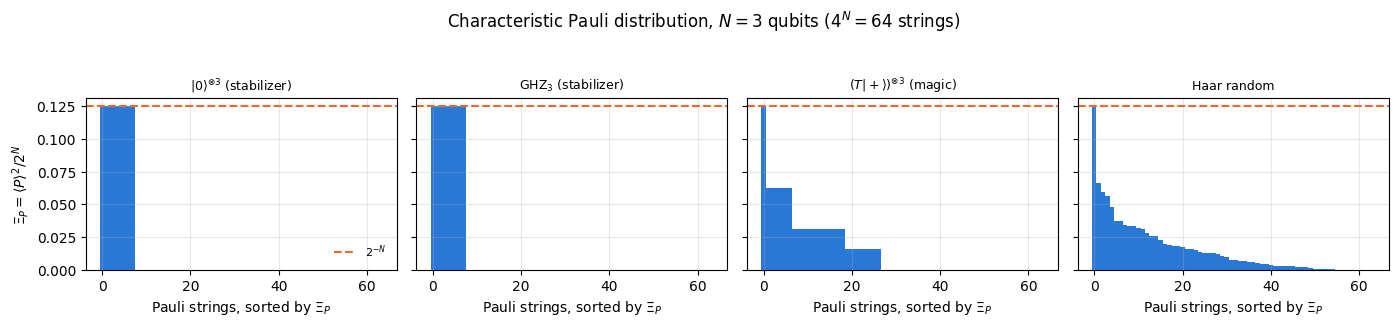

In [7]:
# ==============================================================================
# FIGURE 1: the characteristic distribution of a stabilizer, a magic and a random state
# ==============================================================================
fig, axes = plt.subplots(1, 4, figsize=(14, 3.1), sharey=True)
for ax, (name, Xi) in zip(axes, spectra.items()):
    v = np.sort(Xi.reshape(-1))[::-1]
    ax.bar(np.arange(len(v)), v, width=1.0, color=PALETTE[0])
    ax.axhline(2.0 ** -N_s, color=PALETTE[1], lw=1.5, ls="--", label=r"$2^{-N}$")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel(r"Pauli strings, sorted by $\Xi_P$")
axes[0].set_ylabel(r"$\Xi_P=\langle P\rangle^2/2^N$")
axes[0].legend(fontsize=8)
fig.suptitle(rf"Characteristic Pauli distribution, $N={N_s}$ qubits ($4^N={4 ** N_s}$ strings)", y=1.04)
fig.tight_layout()
plt.show()

The numbers confirm Eq. (7). For $\vert0\rangle^{\otimes3}$ and GHZ$_3$ exactly $8=2^N$ of the $64$ strings carry weight,
each equal to $2^{-N}=0.125$, and the rest are zero: the bars form a perfect plateau. For $(T\vert+\rangle)^{\otimes3}$
the support has grown to $27=3^N$ strings (each qubit contributes $\mathbb 1$, $X$ or $Y$) with unequal weights, and for
the Haar-random state all $64$ strings carry weight. Every column sums to $1$, which is Eq. (6) measured rather than
assumed.

The last two columns need a comment, because they are easy to misread. The tallest bar is $2^{-N}$ in **every** panel,
including the random one — it is the identity string, whose $\Xi_{\mathbb 1}=1/2^N$ is the same for all states. What
distinguishes the four states is how many strings *besides* the identity reach that height: eight for the two
stabilizer states, one (the identity alone) for the magic and the random state, whose next-largest weights are
$0.0625$ and $0.0664$.

> **Physics insight.** The two extremes are "a few strings carry everything" (stabilizer: a flat plateau of height
> $2^{-N}$ on $2^N$ strings) and "everything is spread thin" (random: $4^N$ strings of weight $\sim4^{-N}$). Magic
> measures which of the two a state looks like — and Section 6 turns that comparison into a number.

## 6. Stabilizer Renyi entropies

### 6.1 Definition

For a pure state $\vert\psi\rangle$ of $N$ qubits and $\alpha>0$, $\alpha\ne1$, the **stabilizer Renyi entropy** is the
Renyi entropy of the characteristic distribution, shifted by the stabilizer value:

$$ M_\alpha(\vert\psi\rangle) \;=\; \frac{1}{1-\alpha}\,\log_2\!\Big(\sum_P \Xi_P^{\,\alpha}\Big)\;-\;N ,\qquad \Xi_P=\frac{\langle P\rangle^2}{2^N}. \tag{8} $$

The subtraction of $N$ (i.e. of $\log_2 2^N$) is the whole point of the offset: by Eq. (7) a stabilizer state has
$\sum_P\Xi_P^\alpha=2^N(2^{-N})^\alpha=2^{N(1-\alpha)}$, whose Renyi entropy is exactly $N$ bits, so the offset sets
$M_\alpha=0$ there.

Substituting $\Xi_P=\langle P\rangle^2/2^N$ and simplifying gives the form that the code uses,

$$ M_\alpha=\frac{1}{1-\alpha}\log_2\!\Big(\frac{1}{2^N}\sum_P\vert\langle P\rangle\vert^{2\alpha}\Big), \tag{9} $$

because $\sum_P\Xi_P^\alpha=2^{-\alpha N}\sum_P\vert\langle P\rangle\vert^{2\alpha}$, so that
$\frac{1}{1-\alpha}\big[\log_2\sum_P\vert\langle P\rangle\vert^{2\alpha}-\alpha N\big]-N
=\frac{1}{1-\alpha}\big[\log_2\sum_P\vert\langle P\rangle\vert^{2\alpha}-\alpha N-(1-\alpha)N\big]
=\frac{1}{1-\alpha}\big[\log_2\sum_P\vert\langle P\rangle\vert^{2\alpha}-N\big]$.
Equation (9) has no explicit offset left: the $2^{-N}$ inside
the logarithm carries it. Two special cases are worth naming:

* $\alpha=2$, the case used almost everywhere, $\;M_2=-\log_2\!\big(\sum_P\langle P\rangle^4\big)+N$;
* the **linear** stabilizer entropy $M_{\rm lin}=1-2^N\sum_P\Xi_P^2$, which is not a logarithm at all but is the quantity
  with the cleanest analytic properties (Section 7.3) and is a strong monotone (Leone and Bittel 2024).

**Write the absolute value.** Equation (9) contains $\vert\langle P\rangle\vert^{2\alpha}$, with the modulus.
The two agree when $2\alpha$ is an even integer, i.e. for $\alpha=1,2,3,\dots$, and differ otherwise — at $\alpha=3/2$ the
exponent $2\alpha=3$ is odd and a negative $\langle P\rangle$ would contribute with the wrong sign. Section 9.6
demonstrates the damage on a concrete state.

### 6.2 $M_\alpha\ge0$, with equality exactly on stabilizer states

Two facts do the work: $\sum_P\Xi_P=1$ (Eq. 6) and $\Xi_P\le2^{-N}$ for every $P$, the latter because
$\langle P\rangle^2\le1$. Write the sum in Eq. (8) as $\sum_P\Xi_P^\alpha=\sum_P\Xi_P\,\Xi_P^{\alpha-1}$ and bound the
second factor by replacing $\Xi_P$ with its maximum $2^{-N}$:

$$ \alpha>1:\quad \sum_P\Xi_P^{\alpha}\le\big(2^{-N}\big)^{\alpha-1}\sum_P\Xi_P=2^{-N(\alpha-1)},\qquad \alpha<1:\quad \sum_P\Xi_P^{\alpha}\ge2^{-N(\alpha-1)} , $$

the inequality flipping because $x\mapsto x^{\alpha-1}$ is decreasing for $\alpha<1$. Taking $\log_2$ and dividing by
$1-\alpha$ — which is negative in the first case and positive in the second, flipping the inequality back — gives in
**both** cases $\frac{1}{1-\alpha}\log_2\sum_P\Xi_P^\alpha\ge N$, i.e.

$$ M_\alpha\ \ge\ 0 \qquad\text{for every } \alpha>0,\ \alpha\ne1 . $$

Equality forces the bound $\Xi_P^{\alpha-1}\lessgtr(2^{-N})^{\alpha-1}$ to be tight wherever $\Xi_P>0$, i.e.
$\Xi_P\in\{0,2^{-N}\}$ for every $P$, i.e. $\langle P\rangle\in\{0,\pm1\}$; normalisation then fixes the number of
strings with $\langle P\rangle=\pm1$ at exactly $2^N$. Now $\langle P\rangle=\pm1$ with $P^2=\mathbb 1$ means
$P\vert\psi\rangle=\pm\vert\psi\rangle$, so the set
$\mathcal S=\{Q\in\mathcal P_N: Q\vert\psi\rangle=\vert\psi\rangle\}$ has $2^N$ elements and does not contain
$-\mathbb 1$. It is abelian: for $Q,R\in\mathcal S$ we have $QR\vert\psi\rangle=\vert\psi\rangle=RQ\vert\psi\rangle$
while $QR=\pm RQ$ by Eq. (3), so the sign must be $+$. That is exactly the definition of Section 4.1, so
$\vert\psi\rangle$ is a stabilizer state. Together with Eq. (7) for the converse,

$$ M_\alpha(\vert\psi\rangle)=0 \quad\Longleftrightarrow\quad \vert\psi\rangle \text{ is a stabilizer state}. $$

$\blacksquare$ (Leone, Oliviero and Hamma 2022.) Both halves are checked numerically throughout the notebook.

### 6.3 Invariance under Clifford unitaries — proved

Let $C$ be Clifford and $\vert\phi\rangle=C\vert\psi\rangle$. For any Pauli string $P$,

$$ \langle\phi\vert P\vert\phi\rangle=\langle\psi\vert C^\dagger PC\vert\psi\rangle=\epsilon_P\,\langle\psi\vert P'\vert\psi\rangle, $$

where $C^\dagger PC=\epsilon_P P'$ with $\epsilon_P=\pm1$ and $P'$ another Pauli string: the sign is real because both
$P$ and $P'$ are Hermitian. The map $P\mapsto P'$ is injective (conjugation by a unitary is), hence a **permutation** of
the $4^N$ strings. Therefore

$$ \Xi^\phi_P=\frac{\epsilon_P^2\langle P'\rangle_\psi^2}{2^N}=\Xi^\psi_{P'} , $$

so the characteristic distribution of $\vert\phi\rangle$ is a *relabelling* of that of $\vert\psi\rangle$. Any function of
the multiset of values $\{\Xi_P\}$ — in particular $\sum_P\Xi_P^\alpha$ — is unchanged, and $M_\alpha(C\vert\psi\rangle)=M_\alpha(\vert\psi\rangle)$
for every $\alpha$. $\blacksquare$

This is the property that makes $M_\alpha$ a measure of *non-Clifford* resources rather than of anything else: no amount
of Clifford circuitry, however deep and however entangling, changes it by a single bit.

### 6.4 Additivity on product states — proved

Let $\vert\Psi\rangle=\vert\psi\rangle_A\otimes\vert\phi\rangle_B$ with $N_A+N_B=N$ qubits. Every Pauli string on $N$
qubits factorises as $P=P_A\otimes P_B$, and $\langle P\rangle=\langle P_A\rangle\langle P_B\rangle$. Hence the sum in
Eq. (9) factorises:

$$ \sum_P\vert\langle P\rangle\vert^{2\alpha}=\Big(\sum_{P_A}\vert\langle P_A\rangle\vert^{2\alpha}\Big)\Big(\sum_{P_B}\vert\langle P_B\rangle\vert^{2\alpha}\Big), $$

and, taking $\log_2$ and dividing by $1-\alpha$, with $2^{-N}=2^{-N_A}2^{-N_B}$ splitting as well,

$$ M_\alpha(\vert\psi\rangle\otimes\vert\phi\rangle)=M_\alpha(\vert\psi\rangle)+M_\alpha(\vert\phi\rangle). \tag{10} $$

$\blacksquare$ Magic is extensive: $N$ independent magic states carry $N$ times the magic of one.

### 6.5 An upper bound — proved

Fix $\alpha=2$. Split off the identity string, whose weight $\Xi_{\mathbb 1}=2^{-N}$ is the same for every state, and
apply the Cauchy-Schwarz inequality $\sum_{k=1}^{K}x_k^2\ge\big(\sum_kx_k\big)^2/K$ to the remaining $4^N-1$ strings,
which carry a total weight $1-2^{-N}$. With $d=2^N$,

$$ \sum_P\Xi_P^2 \;\ge\; \frac{1}{d^2}+\frac{(1-1/d)^2}{d^2-1} \;=\;\frac{1}{d^2}+\frac{(d-1)^2}{d^2(d-1)(d+1)} \;=\;\frac{(d+1)+(d-1)}{d^2(d+1)}\;=\;\frac{2}{d(d+1)} . $$

Since $M_2=-\log_2\big(\sum_P\Xi_P^2\big)-N$ is a decreasing function of that sum,

$$ M_2 \;\le\; \log_2\frac{d(d+1)}{2}-N \;=\; \log_2\frac{2^N+1}{2}. \tag{11} $$

$\blacksquare$ For one qubit the bound reads $\log_2(3/2)=0.585$ bit, and Section 7.1 exhibits a state that saturates it.
For large $N$ the bound behaves as $N-1$ bits, one bit below the naive maximum $N$ (which is what one would get if
$\Xi$ could be uniform over all $4^N$ strings — it cannot, because $\Xi_{\mathbb 1}=2^{-N}$ is fixed).

Whether the bound is *attained* at a given $N$ is a separate question, and Eq. (11) does not answer it. Cauchy-Schwarz
is tight only if all $4^N-1$ non-identity weights are equal, i.e. only if
$\vert\langle P\rangle\vert^2=1/(2^N+1)$ for **every** non-identity string $P$ simultaneously. That is a system of
$4^N-1$ equations on the $2^{N+1}-2$ real parameters of a normalised state vector modulo phase — satisfiable at $N=1$
($3$ equations, $2$ parameters, solved by the $T$-type states of Section 7.1), and increasingly overdetermined
afterwards, so a solution need not exist. Eq. (11) is an upper bound that need not be attained, and the numbers plotted
against it below should be read that way.

### 6.6 The values of $\alpha$ that give a magic monotone

A resource theory needs its measure to be non-increasing under the free operations — here *stabilizer protocols*: Clifford
unitaries, computational-basis measurements, discarding qubits and adding fresh stabilizer states. Section 6.3 disposes of
the Clifford part for all $\alpha$; measurements are the hard case, and the literature settled it only recently.

* Haug and Piroli (Quantum 2023) construct explicit counterexamples showing that for Renyi index $0\le\alpha<2$ the
  stabilizer entropies are **not** monotones under stabilizer protocols that include computational-basis
  measurements — not even restricted to pure states — and that for **every** $\alpha$ they fail a *strong*
  monotonicity condition (monotonicity of the average over measurement outcomes).
* Leone and Bittel (2024) close the remaining case: for $\alpha\ge2$ the stabilizer entropies **are** monotones of the
  magic-state resource theory restricted to pure states; the linear stabilizer entropy is in addition a strong monotone;
  and a convex-roof construction extends them to mixed states as monotones.

The two bullets look contradictory and are not, because "monotone" and "strong monotone" are different conditions and
the second is not preserved by reparametrisation. A monotone must not increase under a free operation. A *strong*
monotone must not increase *on average over the measurement outcomes*, $\sum_ip_iM(\vert\phi_i\rangle)\le M(\vert\psi\rangle)$.
Averaging does not commute with a nonlinear relabelling, and from Eq. (9) the two quantities are related by

$$ M_{\rm lin}=1-2^{-M_2}, $$

a concave increasing function of $M_2$. So $M_{\rm lin}$ can satisfy the averaged inequality where $M_2$ fails it,
exactly as Haug and Piroli (for all $\alpha$) and Leone and Bittel (again for $\alpha\ge2$, with an explicit
counterexample) both find. The summary: $M_\alpha$ with $\alpha\ge2$ is a monotone but not a strong monotone;
$M_{\rm lin}$ is both.

This is why $\alpha=2$, and not the more familiar $\alpha\to1$ Shannon limit, is the standard choice. A related monotone
that is easier to interpret is the **stabilizer nullity** $\nu=N-\log_2\vert\mathcal S_\psi\vert$,
where $\mathcal S_\psi$ is the group of Pauli operators that stabilise $\vert\psi\rangle$ (Beverland, Campbell, Howard and
Kliuchnikov 2020). It is an integer; it vanishes exactly on stabilizer states, since $\nu=0$ forces
$\vert\mathcal S_\psi\vert=2^N$; and because it is a monotone that equals $1$ on $T\vert+\rangle$ it lower-bounds the
number of $T$ gates needed to build the state. Leone, Oliviero and Hamma prove $M_\alpha\le\nu$, which is the cleanest
available statement of "magic costs $T$ gates": a state produced by $k$ $T$ gates has $M_\alpha\le k$ bits.
Other magic measures in use are the **relative entropy of magic** and the **mana** (Veitch, Mousavian, Gottesman and
Emerson 2014) and the **robustness of magic** (Howard and Campbell 2017). The relative entropy and the robustness
require an optimisation over the stabilizer states and are therefore restricted to very small $N$; the mana is cheap
but is defined through a discrete Wigner function that exists only in odd prime dimensions (Section 11). Avoiding both
limitations is precisely the practical advantage of $M_\alpha$.

## 7. Analytic examples

Before writing an algorithm we work out every case that can be done with pen and paper, so that the algorithm has
something to be wrong against. All checks in this section use the brute-force spectrum of Step 3, which is fast enough
for $N\le4$.

### 7.1 One qubit: $M_2$ on the Bloch sphere

A pure single-qubit state has $\rho=\tfrac12(\mathbb 1+\mathbf r\cdot\boldsymbol\sigma)$ with $\vert\mathbf r\vert=1$, so
$\langle\mathbb 1\rangle=1$ and $\langle X\rangle=r_x$, $\langle Y\rangle=r_y$, $\langle Z\rangle=r_z$. With $N=1$,
Eq. (9) at $\alpha=2$ gives

$$ M_2 \;=\; 1-\log_2\!\big(1+r_x^4+r_y^4+r_z^4\big). \tag{12} $$

Maximising $M_2$ means **minimising** $f(\mathbf r)=r_x^4+r_y^4+r_z^4$ on the unit sphere. A Lagrange multiplier gives
$4r_i^3=2\lambda r_i$ for each $i$, so every component is either $0$ or has the same square $r_i^2=\lambda/2$. There are
only three families of critical points:

| critical point | $f$ | $M_2$ | name |
|---|---|---|---|
| one non-zero component, e.g. $(0,0,1)$ | $1$ | $0$ | the six stabilizer states |
| two non-zero, e.g. $(1,1,0)/\sqrt2$ | $1/2$ | $\log_2\frac43=0.41504$ | $H$-type (face-diagonal) |
| three non-zero, $(\pm1,\pm1,\pm1)/\sqrt3$ | $1/3$ | $\log_2\frac32=0.58496$ | $T$-type (body-diagonal) |

The minimum of $f$, and hence the maximum of $M_2$, is at the eight **$T$-type** directions $(\pm1,\pm1,\pm1)/\sqrt3$,
the body diagonals of the cube whose face centres are the six stabilizer states. The value $\log_2(3/2)$ saturates the
bound of Eq. (11) at $N=1$: on one qubit the bound is tight.

The state $T\vert+\rangle$, which the fault-tolerance literature calls *the* magic state, has Bloch vector
$(\cos\frac\pi4,\sin\frac\pi4,0)=(1,1,0)/\sqrt2$ and therefore sits on the *second* row: it is an $H$-type state with
$M_2=\log_2(4/3)$, below the single-qubit maximum. The eight $T$-type directions are the $\pm1$ eigenvectors of the four
operators $(\pm X\pm Y+Z)/\sqrt3$ — each of them an axis of an order-three Clifford rotation that cyclically permutes
the three Pauli axes up to signs; the twelve $H$-type directions, one of which carries $T\vert+\rangle$, are the
$\pm1$ eigenvectors of the six face-diagonal operators such as $(X+Z)/\sqrt2$, the Hadamard. Both families are the
standard resources of magic-state distillation, and the names are Bravyi and Kitaev's (2005), who define
$\vert T\rangle\langle T\vert=\tfrac12\big[\mathbb 1+\tfrac1{\sqrt3}(X+Y+Z)\big]$ and
$\vert H\rangle\langle H\vert=\tfrac12\big[\mathbb 1+\tfrac1{\sqrt2}(X+Z)\big]$ and call the Clifford orbits of those
two states the $T$-type and $H$-type magic states. The value of $M_2$ is not the only figure of merit there, but it
does rank the two families, and the more magical one is not the one the $T$ gate produces.

> **Common pitfall.** The letter $T$ has two unrelated meanings in this subject. The **$T$ gate** is
> $\mathrm{diag}(1,e^{i\pi/4})$, a non-Clifford gate. A **$T$-type magic state** is named after a different operator:
> Bravyi and Kitaev's order-three *Clifford* rotation about a body diagonal, which cyclically permutes the three Pauli
> axes. $T\vert+\rangle$ is an $H$-type state, and the collision of the two names is an accident of notation.

In [8]:
# ==============================================================================
# STEP 4: M_2 of a single qubit -- formula (12) against the brute-force sum
# ==============================================================================
def sre_from_spectrum(ev, alpha=2.0):
    """M_alpha from the array of Pauli expectation values (Eq. 9).

    MATH   M_alpha = log2( 2^-N sum_P |<P>|^(2 alpha) ) / (1 - alpha).
    NOTE   the ABSOLUTE VALUE matters whenever 2*alpha is odd (Section 9.6).
    """
    N = int(round(np.log2(ev.size) / 2))
    return float(np.log2(np.sum(np.abs(ev) ** (2 * alpha)) / 2 ** N) / (1 - alpha))


def m2_bloch(r):
    """Eq. (12):  M_2 = 1 - log2(1 + r_x^4 + r_y^4 + r_z^4)  for a PURE single-qubit state."""
    r = np.asarray(r, dtype=float)
    return 1.0 - np.log2(1.0 + (r ** 4).sum())


print(f"{'direction':30s} {'formula (12)':>13s} {'brute force':>13s} {'|diff|':>10s} {'|r - <sigma>|':>14s}")
for name, r in [("|0>              (0,0,1)", (0, 0, 1)),
                ("|+>              (1,0,0)", (1, 0, 0)),
                ("T|+>   (1,1,0)/sqrt2", (1 / np.sqrt(2), 1 / np.sqrt(2), 0)),
                ("H-type (1,0,1)/sqrt2", (1 / np.sqrt(2), 0, 1 / np.sqrt(2))),
                ("T-type (1,1,1)/sqrt3", (1 / np.sqrt(3), 1 / np.sqrt(3), 1 / np.sqrt(3)))]:
    psi = state_from_bloch(r)
    a, b = m2_bloch(r), sre_from_spectrum(pauli_spectrum_bruteforce(psi))
    # independent check of `state_from_bloch` itself: Eq. (12) only sees r_i^4, so it cannot detect a
    # sign error or a missing conjugation in r_y.  Measure <X>, <Y>, <Z> and compare with r component-wise.
    ev = pauli_spectrum_bruteforce(psi)
    r_meas = np.array([ev[1, 0], ev[1, 1], ev[0, 1]])          # (a,b) = (1,0), (1,1), (0,1) -> X, Y, Z
    err_r = np.abs(r_meas - np.asarray(r, dtype=float)).max()
    print(f"{name:30s} {a:13.9f} {b:13.9f} {abs(a - b):10.2e} {err_r:14.2e}")
    assert abs(a - b) < 1e3 * TOL and err_r < 1e3 * TOL
print(f"\nupper bound of Eq. (11) at N=1: log2(3/2) = {np.log2(1.5):.9f}  -- saturated by the T-type states")

direction                       formula (12)   brute force     |diff|  |r - <sigma>|
|0>              (0,0,1)         0.000000000  -0.000000000   0.00e+00       0.00e+00
|+>              (1,0,0)         0.000000000  -0.000000000   0.00e+00       2.00e-16
T|+>   (1,1,0)/sqrt2             0.415037499   0.415037499   2.22e-16       2.22e-16
H-type (1,0,1)/sqrt2             0.415037499   0.415037499   2.22e-16       1.11e-16
T-type (1,1,1)/sqrt3             0.584962501   0.584962501   6.66e-16       2.22e-16

upper bound of Eq. (11) at N=1: log2(3/2) = 0.584962501  -- saturated by the T-type states


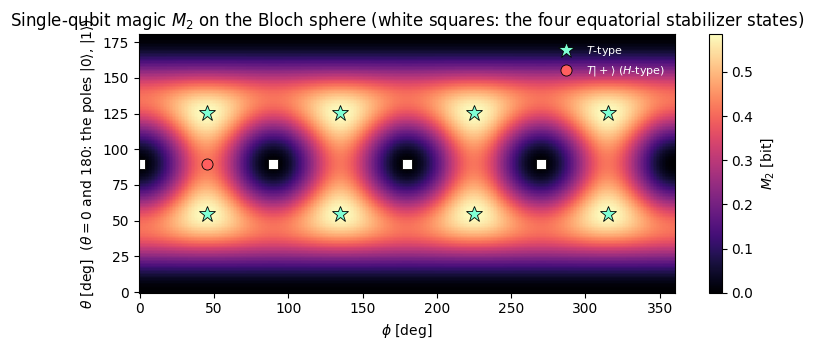

maximum of the map = 0.584932 bit, attained at theta = 55.0 deg; log2(3/2) = 0.584963


In [9]:
# ==============================================================================
# FIGURE 2: M_2 over the whole Bloch sphere (Eq. 12) in the (theta, phi) plane
# ==============================================================================
th = np.linspace(0, np.pi, 181)
ph = np.linspace(0, 2 * np.pi, 361)
TH, PH = np.meshgrid(th, ph, indexing="ij")
RX, RY, RZ = np.sin(TH) * np.cos(PH), np.sin(TH) * np.sin(PH), np.cos(TH)
M2map = 1.0 - np.log2(1.0 + RX ** 4 + RY ** 4 + RZ ** 4)

fig, ax = plt.subplots(figsize=(7.6, 3.6))
im = ax.pcolormesh(np.degrees(PH), np.degrees(TH), M2map, shading="auto", cmap="magma", vmin=0, vmax=LOG2_3_2)
cb = fig.colorbar(im, ax=ax)
cb.set_label(r"$M_2$ [bit]")
T_TYPE = [(sx, sy, sz) for sx in (1, -1) for sy in (1, -1) for sz in (1, -1)]       # all eight body diagonals
for s, rr in enumerate(T_TYPE):
    rr = np.asarray(rr, float) / np.sqrt(3.0)
    ax.plot(np.degrees(np.arctan2(rr[1], rr[0])) % 360, np.degrees(np.arccos(rr[2])),
            "*", ms=12, color="#7fffd4", mec="k", mew=0.6, label=r"$T$-type" if s == 0 else None)
rr = np.array([1, 1, 0]) / np.sqrt(2.0)
ax.plot(np.degrees(np.arctan2(rr[1], rr[0])), np.degrees(np.arccos(rr[2])), "o", ms=8,
        color="#ff5f5f", mec="k", mew=0.6, label=r"$T\vert+\rangle$ ($H$-type)")
for rr in [(1, 0, 0), (-1, 0, 0), (0, 1, 0), (0, -1, 0)]:
    rr = np.asarray(rr, float)
    ax.plot(np.degrees(np.arctan2(rr[1], rr[0])) % 360, np.degrees(np.arccos(rr[2])),
            "s", ms=7, color="w", mec="k", mew=0.6)
ax.set_xlabel(r"$\phi$ [deg]")
ax.set_ylabel(r"$\theta$ [deg]  ($\theta=0$ and $180$: the poles $\vert0\rangle$, $\vert1\rangle$)")
ax.set_title(r"Single-qubit magic $M_2$ on the Bloch sphere (white squares: the four equatorial stabilizer states)")
ax.legend(loc="upper right", fontsize=8, facecolor="k", labelcolor="w")
ax.grid(False)
fig.tight_layout()
plt.show()
print(f"maximum of the map = {M2map.max():.6f} bit, attained at theta = "
      f"{np.degrees(th[np.unravel_index(M2map.argmax(), M2map.shape)[0]]):.1f} deg; "
      f"log2(3/2) = {LOG2_3_2:.6f}")

The map is zero along the top and bottom edges ($\theta=0,180$: the poles $\vert0\rangle,\vert1\rangle$) and at the four
white squares on the equator at $\phi=0,90,180,270$ degrees ($\vert\pm\rangle$ and the two $Y$ eigenstates) — the six
single-qubit stabilizer states, and no others. Between them the magic rises, with ridges of value $0.415$ bit along the
$H$-type directions (one of which carries $T\vert+\rangle$, the red circle) and eight isolated maxima at the $T$-type
directions $\theta=54.7^\circ$ or $125.3^\circ$, $\phi=45^\circ,135^\circ,225^\circ,315^\circ$. The largest value on the
$181\times361$ grid is $0.584932$ bit against the analytic $\log_2(3/2)=0.584963$; the $3\times10^{-5}$ shortfall is the
grid resolution, since the nearest grid point sits $0.3^\circ$ away from the exact maximum.

### 7.2 $T\vert+\rangle$ and products of magic states

For $T\vert+\rangle=(\vert0\rangle+e^{i\pi/4}\vert1\rangle)/\sqrt2$ the Pauli expectations are
$\langle X\rangle=\cos\frac\pi4=\tfrac1{\sqrt2}$, $\langle Y\rangle=\sin\frac\pi4=\tfrac1{\sqrt2}$, $\langle Z\rangle=0$,
so $\sum_P\langle P\rangle^4=1+\tfrac14+\tfrac14=\tfrac32$ and

$$ M_2\big(T\vert+\rangle\big)=1-\log_2\tfrac32=\log_2\tfrac43=0.415037\ \text{bit}. \tag{13} $$

By additivity, Eq. (10), the product $(T\vert+\rangle)^{\otimes N}$ has exactly $N\log_2\frac43$. That gives a family of
states of arbitrary size whose magic is known in closed form — the ideal validation target for Sections 8 and 9.

In [10]:
# ==============================================================================
# STEP 5: additivity (Eq. 10) and the closed form (Eq. 13), by brute force
# ==============================================================================
print(f"{'N':>2s} {'M_2 brute force':>16s} {'N log2(4/3)':>14s} {'|diff|':>10s}")
for N in range(1, 5):
    got = sre_from_spectrum(pauli_spectrum_bruteforce(t_plus_state(N)))
    print(f"{N:2d} {got:16.10f} {N * LOG2_4_3:14.10f} {abs(got - N * LOG2_4_3):10.2e}")
    assert abs(got - N * LOG2_4_3) < 1e3 * TOL

# additivity for two UNRELATED random states
psi_a = haar_state(jax.random.PRNGKey(11), 2)
psi_b = haar_state(jax.random.PRNGKey(12), 2)
m_a = sre_from_spectrum(pauli_spectrum_bruteforce(psi_a))
m_b = sre_from_spectrum(pauli_spectrum_bruteforce(psi_b))
m_ab = sre_from_spectrum(pauli_spectrum_bruteforce(jnp.tensordot(psi_a, psi_b, axes=0)))
print(f"\nrandom 2+2 qubits:  M_2(A) = {m_a:.10f},  M_2(B) = {m_b:.10f}")
print(f"                    sum    = {m_a + m_b:.10f},  M_2(A x B) = {m_ab:.10f},  diff = {abs(m_a + m_b - m_ab):.2e}")
assert abs(m_a + m_b - m_ab) < 1e3 * TOL

 N  M_2 brute force    N log2(4/3)     |diff|
 1     0.4150374993   0.4150374993   1.11e-15
 2     0.8300749986   0.8300749986   2.44e-15
 3     1.2451124978   1.2451124978   2.89e-15


 4     1.6601499971   1.6601499971   4.44e-15



random 2+2 qubits:  M_2(A) = 0.1792221773,  M_2(B) = 0.7351866177
                    sum    = 0.9144087950,  M_2(A x B) = 0.9144087950,  diff = 1.11e-15


### 7.3 The average magic of Haar-random states

How magical is a *typical* state? Take $\vert\psi\rangle=g/\lVert g\rVert$ with $g$ a vector of $d=2^N$ independent
complex Gaussians — exactly what `haar_state` builds, and a Haar-random state because the Gaussian measure is unitarily
invariant. We need $\mathbb E\big[\langle P\rangle^4\big]$ for a fixed non-identity string $P$.

**Step 1 — reduce to two Gamma variables.** $P$ is Hermitian with $P^2=\mathbb 1$ and $\mathrm{Tr}P=0$, so it has
eigenvalues $+1$ and $-1$, each with multiplicity $d/2$. By unitary invariance we may take the eigenbasis of $P$ as the
coordinate basis. Writing $A=\sum_{i\in+}\vert g_i\vert^2$ and $B=\sum_{i\in-}\vert g_i\vert^2$,

$$ \langle P\rangle=\frac{A-B}{A+B}\;\equiv\;v ,\qquad S\equiv A+B=\lVert g\rVert^2 . $$

Each $\vert g_i\vert^2$ is an exponential variable, so $A$ and $B$ are independent Gamma variables of shape $m=d/2$ and
$S$ is Gamma of shape $d$ (same scale $\theta$, which will cancel).

**Step 2 — separate $v$ from $S$.** For independent Gammas of equal scale, $A/S$ has a Beta distribution and is
*independent* of $S$; hence $v=2A/S-1$ is independent of $S$ too, and

$$ \mathbb E\big[(A-B)^k\big]=\mathbb E\big[v^k\big]\,\mathbb E\big[S^k\big] \qquad\Longrightarrow\qquad \mathbb E\big[v^k\big]=\frac{\mathbb E[(A-B)^k]}{\mathbb E[S^k]} . $$

**Step 3 — the moments.** For a Gamma variable of shape $k$ and scale $\theta$ the raw moments are
$\mathbb E[S^n]=\theta^n\,\Gamma(k+n)/\Gamma(k)$, so $\mathbb E[S^2]=d(d+1)\theta^2$ and
$\mathbb E[S^4]=d(d+1)(d+2)(d+3)\theta^4$. For the centred variables $a=A-m\theta$ and $b=B-m\theta$ the Gamma central
moments give $\mathbb E[a^2]=m\theta^2$ and $\mathbb E[a^4]=(3m^2+6m)\theta^4$. Since $A-B=a-b$ with $a,b$ independent
and zero-mean,

$$ \begin{aligned} \mathbb E\big[(A-B)^2\big] &= 2m\theta^2 = d\,\theta^2,\\ \mathbb E\big[(A-B)^4\big] &= \mathbb E[a^4]+6\,\mathbb E[a^2]\mathbb E[b^2]+\mathbb E[b^4] = \big(2(3m^2+6m)+6m^2\big)\theta^4 = \big(12m^2+12m\big)\theta^4 = 3d(d+2)\,\theta^4 . \end{aligned} $$

Dividing,

$$ \mathbb E\big[\langle P\rangle^2\big]=\frac{d}{d(d+1)}=\frac{1}{d+1},\qquad \mathbb E\big[\langle P\rangle^4\big]=\frac{3d(d+2)}{d(d+1)(d+2)(d+3)}=\frac{3}{(d+1)(d+3)} . \tag{14} $$

**Consistency check.** Summing the first of Eq. (14) over the $4^N-1=d^2-1$ non-identity strings and adding
$\langle\mathbb 1\rangle^2=1$ gives $1+(d^2-1)/(d+1)=1+(d-1)=d$, which is Eq. (6) — the derivation reproduces the exact
sum rule, for free.

**Step 4 — the answer.** Let $\zeta=\sum_P\langle P\rangle^4$, so that $M_2=N-\log_2\zeta$ and
$M_{\rm lin}=1-\zeta/d$. Summing the second of Eq. (14),

$$ \mathbb E[\zeta]=1+\frac{3(d^2-1)}{(d+1)(d+3)}=1+\frac{3(d-1)}{d+3}=\frac{4d}{d+3} \qquad\Longrightarrow\qquad \boxed{\ \mathbb E\big[M_{\rm lin}\big]=1-\frac{4}{2^N+3}\ } \tag{15} $$

— an exact identity, and exactly the result quoted by Leone, Oliviero and Hamma (2022). For $M_2$ itself the average of a
logarithm is not the logarithm of the average; since $-\log_2$ is convex, Jensen's inequality gives only a bound,

$$ \mathbb E\big[M_2\big] \;\ge\; -\log_2\frac{\mathbb E[\zeta]}{d} \;=\; \log_2\frac{2^N+3}{4}. \tag{16} $$

Comparing Eq. (16) with the maximum of Eq. (11), $\log_2\frac{2^N+1}{2}$, the two differ by one bit as $N\to\infty$: a
typical state carries almost, but not quite, the largest possible magic. Section 9.8 measures both the exact identity
(15) and the bound (16); here we only check them where brute force reaches.

In [11]:
# ==============================================================================
# STEP 6: Haar averages at N = 1, 2, 3 against Eqs. (15) and (16), brute force
# ==============================================================================
n_haar = 200
print(f"{'N':>2s} {'<M_lin> measured':>18s} {'1 - 4/(d+3)':>13s} {'<M_2> measured':>16s} "
      f"{'log2((d+3)/4)':>15s} {'bound (11)':>11s}")
for N in (1, 2, 3):
    keys = jax.random.split(jax.random.PRNGKey(1234 + N), n_haar)
    zeta = np.array([np.sum(pauli_spectrum_bruteforce(haar_state(k, N)) ** 4) for k in keys])
    d = 2 ** N
    mlin, m2 = 1.0 - zeta / d, N - np.log2(zeta)
    print(f"{N:2d} {mlin.mean():10.6f}+-{mlin.std() / np.sqrt(n_haar):.6f} {1 - 4 / (d + 3):13.6f} "
          f"{m2.mean():8.6f}+-{m2.std() / np.sqrt(n_haar):.6f} {np.log2((d + 3) / 4):15.6f} "
          f"{np.log2((d + 1) / 2):11.6f}")
    assert abs(mlin.mean() - (1 - 4 / (d + 3))) < 5 * mlin.std() / np.sqrt(n_haar)

 N   <M_lin> measured   1 - 4/(d+3)   <M_2> measured   log2((d+3)/4)  bound (11)


 1   0.198578+-0.006198      0.200000 0.327685+-0.010859        0.321928    0.584963


 2   0.428082+-0.005465      0.428571 0.818461+-0.013147        0.807355    1.321928


 3   0.637058+-0.002971      0.636364 1.471063+-0.011093        1.459432    2.169925


The measured $\langle M_{\rm lin}\rangle$ agrees with the exact prediction $1-4/(2^N+3)$ within the statistical error of
$200$ samples, at all three sizes, which confirms Eq. (15) numerically. The measured $\langle M_2\rangle$ lies *above*
$\log_2\frac{2^N+3}{4}$ at all three sizes, by about one hundredth of a bit. That is the direction Jensen's inequality
(16) demands — the average of a logarithm exceeds the logarithm of the average, by an amount set by the fluctuations
of $\zeta$ — but each excess is only one or two standard errors, so $200$ samples do not resolve the gap on their own.
Section 9.8 repeats the test up to $N=10$ with more samples and shows the gap closing.

> **Numerical practice.** Deriving a closed form and then measuring it gives two independent tests: the consistency
> check under Eq. (14) tests the normalisation of the Gamma moments before any code is written, and the numerical test
> above detects an error in the combinatorial factor $6$ of $\mathbb E[(a-b)^4]$ (replacing it by $2$ changes
> $\mathbb E[\langle P\rangle^4]$ by a third at large $d$).

## 8. Algorithm 1: the definition, literally

The first implementation transcribes Eq. (9) with no cleverness: loop over all $4^N$ Pauli strings, evaluate
$\langle P\rangle$, accumulate $\vert\langle P\rangle\vert^{2\alpha}$.

**Cost of this implementation.** One expectation value $\langle\psi\vert P\vert\psi\rangle$ is computed matrix-free, as
in [notebook 05](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): apply up to $N$ single-qubit matrices to the
state tensor, each costing $O(2^N)$, then one inner product. That is $O(N2^N)$ per string, and with $4^N$ strings

$$ \text{brute force:}\qquad O\big(N\,8^N\big)\ \text{time},\qquad O(2^N)\ \text{memory}. $$

Every additional qubit costs a factor of eight in arithmetic. Section 9.7 measures where that stops being affordable:
$N=6$ already takes a few seconds in this implementation, so $N=7$ is the last size a notebook cell can afford.

In [12]:
# ==============================================================================
# STEP 7: brute-force M_alpha -- the definition transcribed
# ==============================================================================
def sre_bruteforce(psi, alpha=2.0):
    """M_alpha by summing over all 4^N Pauli strings (Eq. 9).

    MATH   M_alpha = (1-alpha)^-1 log2( 2^-N sum_{a,b} |<P_{a,b}>|^(2 alpha) )
    IMPLEMENTATION  <P> from `expect_pauli_string`: apply the string qubit by qubit, then one inner product.
    COST   4^N strings x O(N 2^N) per expectation value = O(N 8^N) time, O(2^N) memory.
    """
    N = psi.ndim
    total = 0.0
    for a in range(2 ** N):
        for b in range(2 ** N):
            e = float(expect_pauli_string(psi, pauli_letters(a, b, N)))
            total += abs(e) ** (2 * alpha)
    return float(np.log2(total / 2 ** N) / (1 - alpha))


for N in (2, 3):
    got, want = sre_bruteforce(t_plus_state(N)), N * LOG2_4_3
    print(f"N={N}: sre_bruteforce((T|+>)^N) = {got:.10f}, exact {want:.10f}, diff {abs(got - want):.2e}")
    assert abs(got - want) < 1e3 * TOL

N=2: sre_bruteforce((T|+>)^N) = 0.8300749986, exact 0.8300749986, diff 2.11e-15
N=3: sre_bruteforce((T|+>)^N) = 1.2451124978, exact 1.2451124978, diff 2.00e-15


## 9. Algorithm 2: all $4^N$ Pauli expectation values by Walsh-Hadamard transform

### 9.1 The derivation

The waste in Algorithm 1 is that each of the $4^N$ expectation values is computed from scratch. The $(a,b)$ encoding of
Eq. (1) exposes the structure that makes almost all of that work redundant.

Act with $X^aZ^b$ on a computational basis state $\vert s\rangle$, $s\in\{0,1\}^N$. The $Z$ part is diagonal and the $X$
part is a permutation:

$$ Z^b\vert s\rangle=(-1)^{\,b\cdot s}\vert s\rangle ,\qquad X^a\vert s\rangle=\vert s\oplus a\rangle \qquad\Longrightarrow\qquad X^aZ^b\vert s\rangle=(-1)^{\,b\cdot s}\,\vert s\oplus a\rangle , $$

where $\oplus$ is the bitwise XOR. Expanding $\vert\psi\rangle=\sum_s\psi[s]\vert s\rangle$ and using
$\langle\psi\vert s\oplus a\rangle=\psi^*[s\oplus a]$,

$$ \langle P_{a,b}\rangle \;=\; i^{\,a\cdot b}\sum_{s}(-1)^{\,b\cdot s}\;\psi^*[s\oplus a]\,\psi[s] \;=\; i^{\,a\cdot b}\,F_a[b], \qquad F_a[b]\equiv\sum_s(-1)^{\,b\cdot s}f_a[s], \tag{17} $$

with the **XOR-shifted product**

$$ f_a[s] \;=\; \psi^*[s\oplus a]\,\psi[s]. \tag{18} $$

Read Eq. (17) again: for a **fixed** $X$-pattern $a$, the whole family of $2^N$ expectation values
$\{\langle P_{a,b}\rangle\}_b$ is one linear transform of the single array $f_a$. That transform,
$F[b]=\sum_s(-1)^{b\cdot s}f[s]$, is the (unnormalised) **Walsh-Hadamard transform**.

Two remarks close the argument.

* The prefactor has modulus one, $\vert i^{a\cdot b}\vert=1$, so $\vert\langle P_{a,b}\rangle\vert=\vert F_a[b]\vert$.
  Because Eq. (9) needs only $\vert\langle P\rangle\vert^{2\alpha}$, the phase never has to be computed — for **any**
  $\alpha$, including non-even powers. (The phase matters elsewhere: it is what makes $\langle P\rangle$ real. See
  Section 9.6 for what happens if one confuses $\vert\langle P\rangle\vert^{2\alpha}$ with $\langle P\rangle^{2\alpha}$.)
* $f_a$ costs $O(2^N)$ to build (one gather by the XOR-shifted index and one element-wise product) and the transform
  costs $O(N2^N)$, as shown next. With $2^N$ values of $a$,

$$ \text{Walsh-Hadamard route:}\qquad O\big(N\,4^N\big)\ \text{time},\qquad O(2^N\times\text{batch})\ \text{memory}. $$

The speed-up over Algorithm 1 is a factor $2^N$: three orders of magnitude at $N=10$, five at $N=17$.

### 9.2 The Walsh-Hadamard transform is a Hadamard on every axis

Split the exponent: $(-1)^{b\cdot s}=\prod_{q=0}^{N-1}(-1)^{b_qs_q}$, and observe that the $2\times2$ matrix

$$ \tilde H=\begin{pmatrix}1&1\\1&-1\end{pmatrix},\qquad \tilde H_{b_q s_q}=(-1)^{b_qs_q} $$

has exactly those entries. Therefore, viewing $f$ as a rank-$N$ tensor of shape $(2,)^N$,

$$ F[b_0\ldots b_{N-1}]=\sum_{s_0\ldots s_{N-1}}\tilde H_{b_0s_0}\cdots \tilde H_{b_{N-1}s_{N-1}}\,f[s_0\ldots s_{N-1}], $$

which is $\tilde H$ applied to every axis, one at a time — precisely `apply_gate(f, H_tilde, [q])` for $q=0,\dots,N-1$.
For $N=3$ the three einsum strings are

```
q=0:  "Aa,abc->Abc"      q=1:  "Bb,abc->aBc"      q=2:  "Cc,abc->abC"
```

Each contraction touches all $2^N$ entries and costs $2\cdot2^N$ multiply-adds, so the whole transform costs $O(N2^N)$ —
the fast Walsh-Hadamard transform, obtained here for free from the tensor formulation rather than from a butterfly
diagram. $\tilde H=\sqrt2\,H$ is the Hadamard gate without its normalisation, and $\tilde H^2=2\cdot\mathbb 1$, so
applying the routine twice multiplies the array by $2^N$ — a cheap self-test.

In [13]:
# ==============================================================================
# STEP 8: the Walsh-Hadamard transform as N applications of [[1,1],[1,-1]]
# ==============================================================================
def wht_all_axes(f):
    """Unnormalised Walsh-Hadamard transform over all N binary axes of the tensor f.

    MATH   F[b] = sum_s (-1)^(b.s) f[s],  b, s in {0,1}^N
    IMPLEMENTATION  (-1)^(b.s) factorises over qubits, and [[1,1],[1,-1]]_{b,s} = (-1)^(b s),
           so the transform is that 2x2 matrix applied to EVERY axis: N calls of `apply_gate`.
    COST   N einsums of O(2^N) each = O(N 2^N) time, O(2^N) memory, no temporary of size 4^N.
    JAX    pure and shape-static -> jit/vmap-able; works on a batched leading axis under vmap.
    """
    Hun = jnp.array([[1, 1], [1, -1]], dtype=f.dtype)
    for q in range(f.ndim):
        f = apply_gate(f, Hun, [q])
    return f


# self-test 1: the definition, by explicit summation over 2^N x 2^N sign factors
N_w = 3
rng = np.random.default_rng(0)
f_test = jnp.asarray(rng.normal(size=(2,) * N_w) + 1j * rng.normal(size=(2,) * N_w), dtype=CDTYPE)
s_idx = np.arange(2 ** N_w)
signs = np.array([[(-1.0) ** bin(b & s).count("1") for s in s_idx] for b in s_idx])   # (-1)^(b.s)
F_direct = signs @ np.asarray(f_test).reshape(-1)
F_fast = np.asarray(wht_all_axes(f_test)).reshape(-1)
print(f"WHT: max |fast - direct summation| = {np.abs(F_fast - F_direct).max():.2e}")
# self-test 2: applying it twice multiplies by 2^N
print(f"WHT twice / 2^N: max deviation     = "
      f"{np.abs(np.asarray(wht_all_axes(wht_all_axes(f_test))) / 2 ** N_w - np.asarray(f_test)).max():.2e}")
assert np.abs(F_fast - F_direct).max() < 1e3 * TOL

WHT: max |fast - direct summation| = 1.11e-16
WHT twice / 2^N: max deviation     = 3.51e-16


### 9.3 Two qubits by hand

Before writing the general routine, run Eqs. (17)-(18) on $N=2$ with the four $X$-patterns written out. Flat indices are
$s=2s_0+s_1$, so $a=0$ means "no $X$", $a=1$ means "$X$ on qubit 1", $a=2$ means "$X$ on qubit 0", $a=3$ means "$X$ on
both". The four shifted products are

$$ f_0[s]=\vert\psi[s]\vert^2,\quad f_1[s]=\psi^*[s\oplus1]\psi[s],\quad f_2[s]=\psi^*[s\oplus2]\psi[s],\quad f_3[s]=\psi^*[s\oplus3]\psi[s], $$

and the Walsh-Hadamard transform of each yields one row of the $4\times4$ table $\vert\langle P_{a,b}\rangle\vert$. Row
$a=0$ contains $\vert\langle\mathbb 1\mathbb 1\rangle\vert,\vert\langle\mathbb 1Z\rangle\vert,\vert\langle Z\mathbb 1\rangle\vert,\vert\langle ZZ\rangle\vert$;
row $a=1$ contains $\vert\langle\mathbb 1X\rangle\vert,\vert\langle\mathbb 1Y\rangle\vert,\vert\langle ZX\rangle\vert,\vert\langle ZY\rangle\vert$; and so on.

The test state is $\mathrm{CNOT}\,\big(T\vert+\rangle\otimes T\vert+\rangle\big)$ — entangled *and* magic, and with an
answer we already know: CNOT is Clifford, so Section 6.3 together with Eq. (10) fixes its magic at $2\log_2\frac43$.

In [14]:
# ==============================================================================
# STEP 9: N = 2 by hand -- one XOR-shifted product and one WHT per X-pattern a
# ==============================================================================
psi2 = apply_gate(t_plus_state(2), CNOT, [0, 1])       # CNOT on two magic states: entangled AND magic
flat2 = np.asarray(psi2).reshape(-1)
idx2 = np.arange(4)

print("psi =", flat2.round(5))
print(f"\n{'a':>2s} {'f_a[s] = conj(psi[s XOR a]) psi[s]':>44s}   -> WHT -> |<P_(a,b)>| for b = 0,1,2,3")
table_wht = np.zeros((4, 4))
for a in range(4):
    f_a = np.conj(flat2[idx2 ^ a]) * flat2
    F_a = np.asarray(wht_all_axes(jnp.asarray(f_a.reshape(2, 2), dtype=CDTYPE))).reshape(-1)
    table_wht[a] = np.abs(F_a)
    print(f"{a:2d} {np.array2string(f_a.round(4), separator=', '):>44s}   {np.abs(F_a).round(5)}")

table_bf = np.abs(pauli_spectrum_bruteforce(psi2))
print("\nsame table from the brute-force expectation values:")
for a in range(4):
    print(f"  a={a}: {table_bf[a].round(5)}   strings: {[pauli_letters(a, b, 2) for b in range(4)]}")
print(f"\nmax |WHT table - brute-force table| = {np.abs(table_wht - table_bf).max():.2e}")
assert np.abs(table_wht - table_bf).max() < 1e3 * TOL
m2_tab = float(np.log2(np.sum(table_wht ** 4) / 4) / (1 - 2))
print(f"M_2 from this table = {m2_tab:.10f};  expected 2 log2(4/3) = {2 * LOG2_4_3:.10f}  "
      f"(CNOT is Clifford, so Eq. 10 and Section 6.3 fix the answer)")
assert abs(m2_tab - 2 * LOG2_4_3) < 1e3 * TOL

psi = [0.5    +0.j      0.35355+0.35355j 0.     +0.5j     0.35355+0.35355j]

 a           f_a[s] = conj(psi[s XOR a]) psi[s]   -> WHT -> |<P_(a,b)>| for b = 0,1,2,3
 0     [0.25+0.j, 0.25-0.j, 0.25+0.j, 0.25-0.j]   [1. 0. 0. 0.]
 1 [0.1768-0.1768j, 0.1768+0.1768j, 0.1768+0.1768j, 0.1768-0.1768j]   [0.70711 0.      0.      0.70711]
 2 [0.  -0.25j, 0.25-0.j  , 0.  +0.25j, 0.25-0.j  ]   [0.5 0.5 0.5 0.5]
 3 [0.1768-0.1768j, 0.1768-0.1768j, 0.1768+0.1768j, 0.1768+0.1768j]   [0.70711 0.      0.70711 0.     ]

same table from the brute-force expectation values:
  a=0: [1. 0. 0. 0.]   strings: ['II', 'IZ', 'ZI', 'ZZ']
  a=1: [0.70711 0.      0.      0.70711]   strings: ['IX', 'IY', 'ZX', 'ZY']
  a=2: [0.5 0.5 0.5 0.5]   strings: ['XI', 'XZ', 'YI', 'YZ']
  a=3: [0.70711 0.      0.70711 0.     ]   strings: ['XX', 'XY', 'YX', 'YY']

max |WHT table - brute-force table| = 1.11e-16
M_2 from this table = 0.8300749986;  expected 2 log2(4/3) = 0.8300749986  (CNOT is Clifford, so Eq. 10 and Section 6.3

The two tables agree entry by entry. Each row came from a single Walsh-Hadamard transform of a single length-$4$ array,
so four transforms replaced sixteen separately computed expectation values; at $N=10$, $1024$ transforms replace
$1048576$ expectation values.

### 9.4 The general routine

Three implementation decisions turn Eq. (17) into production code.

1. **Vectorise over $a$ with `vmap`.** The map $a\mapsto\sum_b\vert F_a[b]\vert^{2\alpha}$ is a pure function of one
   integer; `jax.vmap` runs it for a whole batch of $X$-patterns in one fused kernel. Inside, `flat[idx ^ a]` is a
   gather with a traced index, which JAX handles without any Python branching.
2. **Loop over batches in Python to cap the memory.** The vmapped kernel holds `batch` arrays of $2^N$ complex numbers
   at once, i.e. $16\cdot\texttt{batch}\cdot2^N$ bytes in double precision. A Python loop over batches keeps that
   bounded while the expensive inner work stays compiled.
3. **Make the batch shape static.** `jax.jit` recompiles for every new input *shape*, so every batch must have the same
   length. We get that for free by choosing a batch size that divides $2^N$ — automatic for any power of two, which is
   why the default is $256$. A batch size that does not divide $2^N$ leaves a short final batch and costs one extra
   compilation.

The accumulator is $\sum_P\vert\langle P\rangle\vert^{2\alpha}$ in Eq. (9), which for $\alpha=2$ is the quantity
$\zeta$ of Section 7.3.

In [15]:
# ==============================================================================
# STEP 10: M_alpha via the Walsh-Hadamard route -- O(N 4^N) time, O(batch 2^N) memory
# ==============================================================================
@partial(jax.jit, static_argnames=("N",))
def _pauli_moment_batch(flat, a_batch, two_alpha, N):
    """sum over the batch of X-patterns `a` of  sum_b |<P_{a,b}>|^(2 alpha).

    MATH   <P_{a,b}> = i^(a.b) * WHT_b[ f_a ],   f_a[s] = conj(psi[s XOR a]) psi[s]   (Eqs. 17, 18)
           |i^(a.b)| = 1, so the phase never enters |<P>|^(2 alpha).
    JAX    vmap over `a`; `flat[idx ^ a]` is a gather with a traced index (no Python `if`).
           `N` is static because it fixes the tensor shape (2,)*N and hence the einsum strings.
    COST   len(a_batch) * O(N 2^N) time, len(a_batch) * O(2^N) memory.
    """
    idx = jnp.arange(2 ** N)

    def for_a(a):
        f = (jnp.conj(flat[idx ^ a]) * flat).reshape((2,) * N)
        return jnp.sum(jnp.abs(wht_all_axes(f)) ** two_alpha)

    return jnp.sum(jax.vmap(for_a)(a_batch))


def sre(psi, alpha=2.0, batch=256):
    """Stabilizer Renyi entropy M_alpha of a PURE state (Eq. 9), Walsh-Hadamard algorithm.

    MATH   M_alpha = (1-alpha)^-1 log2( 2^-N sum_P |<P>|^(2 alpha) ),  sum over all 4^N Pauli strings.
    COST   O(N 4^N) time; memory O(batch * 2^N) on top of the state.
    """
    N = psi.ndim
    flat = psi.reshape(-1)
    batch = min(int(batch), 2 ** N)
    two_alpha = jnp.asarray(2.0 * alpha, dtype=RDTYPE)
    all_a = jnp.arange(2 ** N)
    total = jnp.zeros((), dtype=RDTYPE)
    for start in range(0, 2 ** N, batch):
        total = total + _pauli_moment_batch(flat, all_a[start:start + batch], two_alpha, N)
    return float(jnp.log2(total / 2 ** N) / (1.0 - alpha))


def sre_batch_of_states(psis, alpha=2.0, batch=64):
    """M_alpha for a STACK of states, shape (R,) + (2,)*N: vmap over states as well as over X-patterns.

    JAX    the inner vmap is over `a`, the outer over the R states; memory is R * batch * 2^N complex.
    """
    N = psis.ndim - 1
    flats = psis.reshape(psis.shape[0], -1)
    batch = min(int(batch), 2 ** N)
    two_alpha = jnp.asarray(2.0 * alpha, dtype=RDTYPE)
    all_a = jnp.arange(2 ** N)
    per_state = jax.vmap(_pauli_moment_batch, in_axes=(0, None, None, None))
    total = jnp.zeros((psis.shape[0],), dtype=RDTYPE)
    for start in range(0, 2 ** N, batch):
        total = total + per_state(flats, all_a[start:start + batch], two_alpha, N)
    return np.asarray(jnp.log2(total / 2 ** N) / (1.0 - alpha))


print(f"sre((T|+>)^4)      = {sre(t_plus_state(4)):.12f}   exact {4 * LOG2_4_3:.12f}")
print(f"sre(GHZ_6)         = {sre(ghz_state(6)):+.3e}   (stabilizer: exactly 0)")
print(f"sre(cluster_6)     = {sre(cluster_state(6)):+.3e}   (stabilizer: exactly 0)")

sre((T|+>)^4)      = 1.660149997115   exact 1.660149997115


sre(GHZ_6)         = +1.281e-15   (stabilizer: exactly 0)


sre(cluster_6)     = +5.125e-15   (stabilizer: exactly 0)


### 9.5 Validation against the definition

A fast algorithm has to be compared with a literal transcription of the definition, on states
of every kind: stabilizer states (answer exactly zero), product magic states (answer known in closed form), entangled
magic states, and random states with no structure at all.

In [16]:
# ==============================================================================
# CHECKPOINT: Walsh-Hadamard vs brute force, all state families, N = 2 ... 5
# ==============================================================================
def test_states(N, key):
    """A dictionary of representative N-qubit states."""
    k1, k2 = jax.random.split(key)
    cl = single_qubit_cliffords()
    rnd_cliff = zero_state(N)
    ks = jax.random.split(k1, N + 2)
    for q in range(N):
        rnd_cliff = apply_gate(rnd_cliff, cl[int(jax.random.randint(ks[q], (), 0, 24))], [q])
    for q in range(N - 1):
        rnd_cliff = apply_gate(rnd_cliff, CNOT, [q, q + 1])
    doped = apply_gate(rnd_cliff, T, [N - 1])
    return {"|0>^N": zero_state(N), "GHZ": ghz_state(N), "cluster": cluster_state(N),
            "random Clifford": rnd_cliff, "Clifford + 1 T": doped,
            "(T|+>)^N": t_plus_state(N), "W": w_state(N), "Haar": haar_state(k2, N)}


print(f"{'N':>2s} {'state':16s} {'M_2 (WHT)':>14s} {'M_2 (brute)':>14s} {'|diff|':>10s}")
worst = 0.0
for N in (2, 3, 4, 5):
    for name, psi in test_states(N, jax.random.PRNGKey(20 + N)).items():
        fast, slow = sre(psi), sre_bruteforce(psi)
        worst = max(worst, abs(fast - slow))
        if N in (2, 5):                                     # print two sizes, check all four
            print(f"{N:2d} {name:16s} {fast:14.10f} {slow:14.10f} {abs(fast - slow):10.2e}")
        assert abs(fast - slow) < 1e4 * TOL
print(f"\nworst discrepancy over all 32 tests (N = 2..5): {worst:.2e}")

# also: several Renyi indices on one state
psi_v = test_states(4, jax.random.PRNGKey(24))["Clifford + 1 T"]
print(f"\n{'alpha':>6s} {'M_alpha (WHT)':>15s} {'M_alpha (brute)':>16s}")
for al in (0.5, 1.5, 2.0, 3.0, 4.0):
    print(f"{al:6.1f} {sre(psi_v, al):15.10f} {sre_bruteforce(psi_v, al):16.10f}")
    assert abs(sre(psi_v, al) - sre_bruteforce(psi_v, al)) < 1e4 * TOL

 N state                 M_2 (WHT)    M_2 (brute)     |diff|


 2 |0>^N             -0.0000000000  -0.0000000000   0.00e+00
 2 GHZ                0.0000000000   0.0000000000   0.00e+00
 2 cluster            0.0000000000   0.0000000000   0.00e+00
 2 random Clifford    0.0000000000   0.0000000000   0.00e+00
 2 Clifford + 1 T     0.4150374993   0.4150374993   1.67e-16
 2 (T|+>)^N           0.8300749986   0.8300749986   3.33e-16
 2 W                  0.0000000000   0.0000000000   0.00e+00
 2 Haar               0.9505095709   0.9505095709   3.33e-16


 5 |0>^N             -0.0000000000  -0.0000000000   0.00e+00


 5 GHZ                0.0000000000   0.0000000000   9.61e-16


 5 cluster            0.0000000000   0.0000000000   4.64e-15


...

 5 Haar               3.2425116671   3.2425116671   1.78e-15

worst discrepancy over all 32 tests (N = 2..5): 4.88e-15

 alpha   M_alpha (WHT)  M_alpha (brute)
   0.5    0.5431066063     0.5431066063


   1.5    0.4568933937     0.4568933937


   2.0    0.4150374993     0.4150374993


   3.0    0.3390359526     0.3390359526


   4.0    0.2766916662     0.2766916662


Agreement to $10^{-14}$ or better across all thirty-two combinations, and across Renyi indices from $1/2$ to $4$. Two
entries are structural: "random Clifford" returns exactly $0$ (to rounding), and adding a **single** $T$ gate to it
produces exactly $\log_2\frac43$ — a $T$ gate acting on a stabilizer state creates precisely the magic of one
$T\vert+\rangle$, which by Clifford invariance is all that a Clifford circuit can ever be made to carry with one $T$.

One caveat belongs with that statement. If the qubit the $T$ acts on happens to carry $\pm Z_q$ in the stabilizer group,
then $T_q$ only multiplies the state by a phase and the magic stays at $0$ — $T\vert0\rangle=\vert0\rangle$ is the
smallest example. So a single $T$ on a stabilizer state gives $\log_2\frac43$ *or* $0$, never anything in between; the
test above happens to hit the generic case.

### 9.6 The absolute value in Eq. (9)

Equation (9) contains $\vert\langle P\rangle\vert^{2\alpha}$. Replacing it by $\langle P\rangle^{2\alpha}$ is harmless
when $2\alpha$ is an even integer and catastrophic otherwise, because a negative expectation value then enters the sum
with a negative sign. The failure is invisible on the states one naturally tests with — $(T\vert+\rangle)^{\otimes N}$
has *only non-negative* Pauli expectations — so the next cell deliberately uses a state with negative ones.

In [17]:
# ==============================================================================
# STEP 11: what the missing absolute value costs, on a state with <P> < 0
# ==============================================================================
psi_neg = apply_gate(product_state("-+"), T, [1])          # <X I> = -1: a negative Pauli expectation
ev_neg = pauli_spectrum_bruteforce(psi_neg)
print("non-zero Pauli expectations of |-> (x) T|+> :")
print("   " + ", ".join(f"{pauli_letters(a, b, 2)}={ev_neg[a, b]:+.5f}"
                        for a in range(4) for b in range(4) if abs(ev_neg[a, b]) > 1e-12))

print(f"\n{'alpha':>6s} {'sum |<P>|^(2a)':>16s} {'sum <P>^(2a)':>15s} {'M (correct)':>13s} {'M (no abs)':>14s}")
for al in (0.5, 1.5, 2.0, 3.0):
    s_abs = float(np.sum(np.abs(ev_neg) ** (2 * al)))
    s_raw = float(np.sum(ev_neg ** (2 * al)))
    m_abs = np.log2(s_abs / 4) / (1 - al)
    m_raw = np.log2(s_raw / 4) / (1 - al) if s_raw > 0 else np.nan
    print(f"{al:6.1f} {s_abs:16.10f} {s_raw:15.10f} {m_abs:13.6f} {m_raw:14.6f}")
print("\n(the state is a product |-> (x) T|+>, so the correct answer is M_alpha(T|+>) for every alpha)")
for al in (0.5, 1.5, 2.0, 3.0):
    assert abs(sre(psi_neg, al) - sre(apply_gate(product_state("+"), T, [0]), al)) < 1e3 * TOL
print("the Walsh-Hadamard routine reproduces it for all four indices (asserted above)")

non-zero Pauli expectations of |-> (x) T|+> :
   II=+1.00000, IX=+0.70711, IY=+0.70711, XI=-1.00000, XX=-0.70711, XY=-0.70711

 alpha   sum |<P>|^(2a)    sum <P>^(2a)   M (correct)     M (no abs)
   0.5     4.8284271247    0.0000000000      0.543107    -112.258794
   1.5     3.4142135624    0.0000000000      0.456893     335.201374
   2.0     3.0000000000    3.0000000000      0.415037       0.415037
   3.0     2.5000000000    2.5000000000      0.339036       0.339036

(the state is a product |-> (x) T|+>, so the correct answer is M_alpha(T|+>) for every alpha)


the Walsh-Hadamard routine reproduces it for all four indices (asserted above)


At $\alpha=2$ and $\alpha=3$ the two columns are identical: $2\alpha$ is even and the signs are squared away. At
$\alpha=1/2$ and $\alpha=3/2$ the signed sum collapses to $0.000000$ — the positive and negative contributions cancel
exactly for this state — and the resulting "magic" is a meaningless number of order $10^2$ bits instead of $0.54$ and
$0.46$. The Walsh-Hadamard routine cannot make this mistake: it only ever sees $\vert F_a[b]\vert$.

> **Common pitfall.** $(x^2)^\alpha=\vert x\vert^{2\alpha}\ne x^{2\alpha}$ for odd $2\alpha$. A test suite built from
> $\vert0\rangle$, GHZ and $(T\vert+\rangle)^{\otimes N}$ passes either way, because none of those states has a negative
> Pauli expectation value. Include $\vert-\rangle$ in the test suite.

### 9.7 Batch size, memory and run time

The batch size is the one free parameter. It controls the peak memory — the vmapped kernel materialises `batch` arrays of
$2^N$ complex numbers, i.e. $16\cdot\texttt{batch}\cdot2^N$ bytes in double precision — and it controls how much work
XLA can fuse into one kernel. Small batches waste time on dispatch; huge batches thrash the cache. The next two cells
measure both the batch trade-off and the scaling with $N$.

In [18]:
# ==============================================================================
# STEP 12: time and peak memory against the batch size, at fixed N
# ==============================================================================
N_bs = 11
psi_bs = t_plus_state(N_bs)
batches = [8, 32, 128, 512, 2048]
times_bs = []
for b in batches:
    sre(psi_bs, 2.0, batch=b)                                        # compile
    reps = 3
    t0 = time.time()
    for _ in range(reps):
        sre(psi_bs, 2.0, batch=b)
    times_bs.append((time.time() - t0) / reps)
print(f"N = {N_bs}   (state: (T|+>)^N, exact M_2 = {N_bs * LOG2_4_3:.6f})")
print(f"{'batch':>6s} {'time [s]':>10s} {'peak f-array [MiB]':>20s}")
for b, t in zip(batches, times_bs):
    print(f"{b:6d} {t:10.4f} {b * 2 ** N_bs * 16 / 2 ** 20:20.1f}")

N = 11   (state: (T|+>)^N, exact M_2 = 4.565412)
 batch   time [s]   peak f-array [MiB]
     8     0.3717                  0.2
    32     0.1806                  1.0
   128     0.1861                  4.0
   512     0.2607                 16.0
  2048     0.2704                 64.0


In [19]:
# ==============================================================================
# STEP 13: wall-clock scaling of both algorithms
# ==============================================================================
N_fast = list(range(2, 13))
t_fast = []
for N in N_fast:
    psi = t_plus_state(N)
    sre(psi)                                                          # compile for this N
    t0 = time.time()
    val = sre(psi)
    t_fast.append(time.time() - t0)
    assert abs(val - N * LOG2_4_3) < 1e4 * TOL

N_slow = list(range(2, 7))
t_slow = []
for N in N_slow:
    t0 = time.time()
    sre_bruteforce(t_plus_state(N))
    t_slow.append(time.time() - t0)

print(f"{'N':>2s} {'t(WHT) [s]':>12s} {'t(brute) [s]':>13s} {'speed-up':>10s} {'2^N/N':>9s}")
for i, N in enumerate(N_fast):
    if N in N_slow:
        j = N_slow.index(N)
        print(f"{N:2d} {t_fast[i]:12.5f} {t_slow[j]:13.4f} {t_slow[j] / t_fast[i]:10.1f} {2 ** N / N:9.1f}")
    else:
        print(f"{N:2d} {t_fast[i]:12.5f} {'-':>13s} {'-':>10s} {2 ** N / N:9.1f}")

# one more point, beyond the plotted range
t0 = time.time()
m13 = sre(t_plus_state(13))
t13 = time.time() - t0
print(f"\nlargest size run here: N = 13 (4^13 = {4 ** 13:,} Pauli strings) in {t13:.1f} s "
      f"including compilation; M_2 = {m13:.6f}, exact {13 * LOG2_4_3:.6f}")

 N   t(WHT) [s]  t(brute) [s]   speed-up     2^N/N
 2      0.00128        0.0089        6.9       2.0
 3      0.00167        0.0366       22.0       2.7
 4      0.00126        0.1974      156.5       4.0
 5      0.00079        1.0027     1262.2       6.4
 6      0.00078        4.7745     6157.9      10.7
 7      0.00195             -          -      18.3
 8      0.00348             -          -      32.0
 9      0.01133             -          -      56.9
10      0.04058             -          -     102.4
11      0.23706             -          -     186.2
12      1.11733             -          -     341.3



largest size run here: N = 13 (4^13 = 67,108,864 Pauli strings) in 5.9 s including compilation; M_2 = 5.395487, exact 5.395487


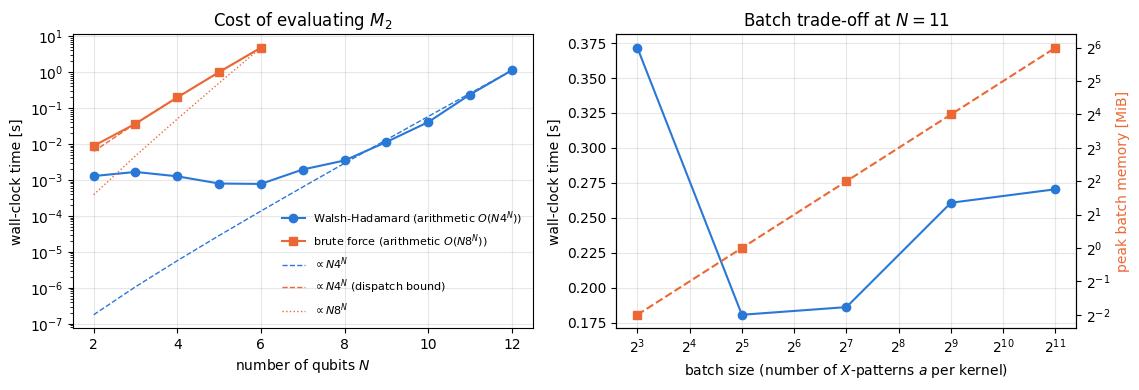

In [20]:
# ==============================================================================
# FIGURE 3: cost of the two algorithms, and the batch-size trade-off
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.0))

ax1.semilogy(N_fast, t_fast, MARKERS[0] + "-", color=PALETTE[0], label=r"Walsh-Hadamard (arithmetic $O(N4^N)$)")
ax1.semilogy(N_slow, t_slow, MARKERS[1] + "-", color=PALETTE[1], label=r"brute force (arithmetic $O(N8^N)$)")
ref_f = np.array([N * 4.0 ** N for N in N_fast])
ref_s4 = np.array([N * 4.0 ** N for N in N_slow])
ref_s8 = np.array([N * 8.0 ** N for N in N_slow])
ax1.semilogy(N_fast, ref_f * t_fast[-1] / ref_f[-1], "--", color=PALETTE[0], lw=1, label=r"$\propto N4^N$")
ax1.semilogy(N_slow, ref_s4 * t_slow[-1] / ref_s4[-1], "--", color=PALETTE[1], lw=1,
             label=r"$\propto N4^N$ (dispatch bound)")
ax1.semilogy(N_slow, ref_s8 * t_slow[-1] / ref_s8[-1], ":", color=PALETTE[1], lw=1, label=r"$\propto N8^N$")
ax1.set_xlabel(r"number of qubits $N$")
ax1.set_ylabel("wall-clock time [s]")
ax1.set_title(r"Cost of evaluating $M_2$")
ax1.legend(fontsize=8)

ax2.plot(batches, times_bs, MARKERS[0] + "-", color=PALETTE[0], label="time")
ax2.set_xscale("log", base=2)
ax2.set_xlabel("batch size (number of $X$-patterns $a$ per kernel)")
ax2.set_ylabel("wall-clock time [s]")
ax2b = ax2.twinx()
ax2b.plot(batches, [b * 2 ** N_bs * 16 / 2 ** 20 for b in batches], MARKERS[1] + "--", color=PALETTE[1])
ax2b.set_yscale("log", base=2)
ax2b.set_ylabel("peak batch memory [MiB]", color=PALETTE[1])
ax2b.grid(False)
ax2.set_title(rf"Batch trade-off at $N={N_bs}$")
fig.tight_layout()
plt.show()

**Reading the timings.** The Walsh-Hadamard curve follows the $N4^N$ reference over the last few sizes, where
the per-call overhead of dispatching a handful of XLA kernels has become negligible; at small $N$ the measured time is
flat at a fraction of a millisecond because it is dominated by that overhead rather than by arithmetic. (Absolute timings on a
shared machine move by a factor of two or three between runs; the slopes do not.)

The brute-force curve does **not** follow its $N8^N$ arithmetic bound — it is much flatter, and it tracks the $N4^N$
dashed line instead. The reason is visible in the code: `sre_bruteforce` makes one Python-level call of
`expect_pauli_string` per string, and each of those dispatches up to $N$ tiny XLA kernels. That is $\sim N4^N$ *kernel
launches*, each costing a fixed fraction of a millisecond, which at $N\le6$ is far more than the $N8^N$ floating-point
operations they perform ($1.6\times10^6$ flops at $N=6$ — microseconds of arithmetic, against seconds of measured wall
time). The $N8^N$ scaling is the asymptotic truth and the dotted line shows what it would look like, but reaching the
regime where it dominates would need sizes the brute force cannot survive in the first place. The practical consequence
is what matters here: the measured speed-up of the Walsh-Hadamard version grows from a factor of order ten at $N=2$ to
three or four orders at $N=6$, and the single extra point at $N=13$ covers $4^{13}\approx6.7\times10^{7}$ Pauli strings.
Extrapolating the brute-force kernel-launch count from the measured time at $N=6$ by the factor
$(13\cdot4^{13})/(6\cdot4^{6})\approx3.5\times10^{4}$ puts the same computation somewhere above a day.

> **Numerical practice.** A cost model predicts the *arithmetic*; a benchmark measures the *implementation*. When the
> two disagree, as they do in the left panel, the interesting quantity is usually the one the cost model ignored —
> here, the number of times Python hands control to the accelerator.

The batch panel shows a broad minimum at batch sizes between a few tens and about a hundred patterns per kernel (the
exact position moves between runs). With fewer patterns the Python loop over batches and the per-kernel dispatch
dominate; with more, the time rises again, most likely because the working set of `batch` arrays of $2^N$ complex
numbers no longer fits in cache (we have not measured the cache behaviour directly). The whole variation across a
factor $256$ in batch size stays within a factor of two to three in time, so this is a parameter worth setting sensibly once and
then leaving alone. The memory line, in contrast, is exactly linear in the batch size by construction, and it is the reason
the loop exists at all: at $N=13$ a single un-batched call would allocate $16\cdot2^{13}\cdot2^{13}$ bytes $=1$ GiB,
while `batch=256` keeps it at $32$ MiB. Timings on a shared machine fluctuate by tens of per cent, so the result is the
shape of these curves; the individual numbers change from run to run.

> **JAX practice.** `_pauli_moment_batch` is jitted with `N` as a *static* argument and everything else traced. That
> means one compilation per system size, reused by every subsequent call — which is why the timing loop above calls the
> function once before starting the clock. Had `N` been traced, the shape `(2,)*N` could not be formed at all.

### 9.8 The Haar average at larger $N$

With the fast algorithm the prediction of Section 7.3 can be tested where it matters.

In [21]:
# ==============================================================================
# STEP 14: Haar averages up to N = 10 against Eqs. (15), (16) and the bound (11)
# ==============================================================================
N_haar = list(range(1, 11))
n_samples = {N: (512 if N <= 5 else 128 if N <= 8 else 64) for N in N_haar}   # cheap sizes get more statistics
mean_mlin, err_mlin, mean_m2, err_m2 = [], [], [], []
for N in N_haar:
    keys = jax.random.split(jax.random.PRNGKey(4000 + N), n_samples[N])
    psis = jnp.stack([haar_state(k, N) for k in keys])
    m2 = sre_batch_of_states(psis, 2.0, batch=min(64, 2 ** N))
    zeta = 2.0 ** (N - m2)
    mlin = 1.0 - zeta / 2 ** N
    mean_m2.append(m2.mean())
    err_m2.append(m2.std() / np.sqrt(n_samples[N]))
    mean_mlin.append(mlin.mean())
    err_mlin.append(mlin.std() / np.sqrt(n_samples[N]))

d = np.array([2.0 ** N for N in N_haar])
pred_mlin = 1.0 - 4.0 / (d + 3)
pred_m2 = np.log2((d + 3) / 4)
bound = np.log2((d + 1) / 2)
print(f"{'N':>2s} {'samples':>8s} {'<M_lin>':>10s} {'+-':>8s} {'1-4/(d+3)':>11s} {'<M_2>':>10s} {'+-':>8s} "
      f"{'log2((d+3)/4)':>14s} {'bound (11)':>11s}")
for i, N in enumerate(N_haar):
    print(f"{N:2d} {n_samples[N]:8d} {mean_mlin[i]:10.6f} {err_mlin[i]:8.6f} {pred_mlin[i]:11.6f} "
          f"{mean_m2[i]:10.5f} {err_m2[i]:8.5f} {pred_m2[i]:14.5f} {bound[i]:11.5f}")
    assert abs(mean_mlin[i] - pred_mlin[i]) < 5 * err_mlin[i] + 1e-12      # Eq. (15) is an exact identity
    assert mean_m2[i] > pred_m2[i] - 5 * err_m2[i]                         # Eq. (16) is a lower bound

 N  samples    <M_lin>       +-   1-4/(d+3)      <M_2>       +-  log2((d+3)/4)  bound (11)
 1      512   0.201501 0.003789    0.200000    0.33271  0.00670        0.32193     0.58496
 2      512   0.428138 0.003596    0.428571    0.81965  0.00851        0.80735     1.32193
 3      512   0.639301 0.001865    0.636364    1.48032  0.00708        1.45943     2.16993
 4      512   0.790028 0.000791    0.789474    2.25675  0.00527        2.24793     3.08746
 5      512   0.885550 0.000283    0.885714    3.12941  0.00351        3.12928     4.04439
 6      128   0.940389 0.000178    0.940299    4.06909  0.00429        4.06609     5.02237
 7      128   0.969528 0.000043    0.969466    5.03656  0.00201        5.03342     6.01123
 8      128   0.984558 0.000011    0.984556    6.01702  0.00102        6.01681     7.00562
 9       64   0.992229 0.000004    0.992233    7.00772  0.00083        7.00843     8.00282
10       64   0.996105 0.000001    0.996105    8.00433  0.00046        8.00422     9.00141

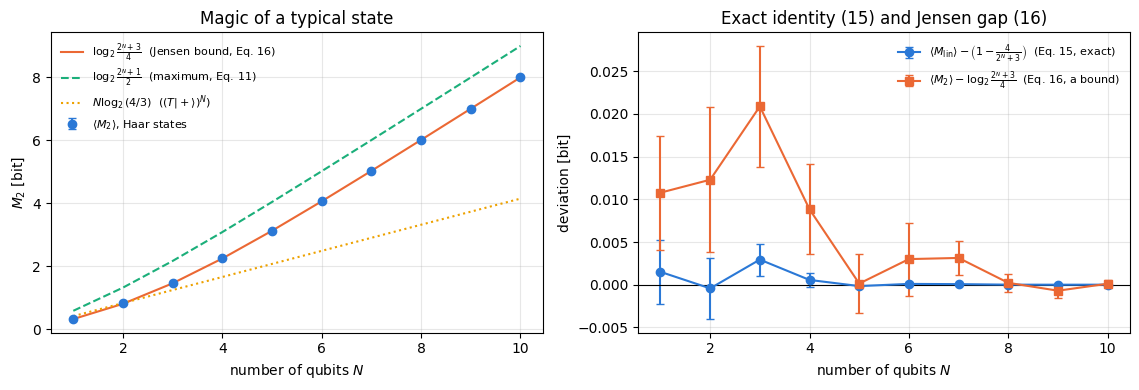

In [22]:
# ==============================================================================
# FIGURE 4: how much magic a typical state has
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax1.errorbar(N_haar, mean_m2, yerr=err_m2, fmt=MARKERS[0], color=PALETTE[0], capsize=3,
             label=r"$\langle M_2\rangle$, Haar states")
ax1.plot(N_haar, pred_m2, "-", color=PALETTE[1], label=r"$\log_2\frac{2^N+3}{4}$  (Jensen bound, Eq. 16)")
ax1.plot(N_haar, bound, "--", color=PALETTE[2], label=r"$\log_2\frac{2^N+1}{2}$  (maximum, Eq. 11)")
ax1.plot(N_haar, [N * LOG2_4_3 for N in N_haar], ":", color=PALETTE[3], label=r"$N\log_2(4/3)$  ($(T\vert+\rangle)^N$)")
ax1.set_xlabel(r"number of qubits $N$")
ax1.set_ylabel(r"$M_2$ [bit]")
ax1.set_title("Magic of a typical state")
ax1.legend(fontsize=8)

ax2.errorbar(N_haar, np.array(mean_mlin) - pred_mlin, yerr=err_mlin, fmt=MARKERS[0] + "-", color=PALETTE[0],
             capsize=3, label=r"$\langle M_{\rm lin}\rangle-\left(1-\frac{4}{2^N+3}\right)$  (Eq. 15, exact)")
ax2.errorbar(N_haar, np.array(mean_m2) - pred_m2, yerr=err_m2, fmt=MARKERS[1] + "-", color=PALETTE[1],
             capsize=3, label=r"$\langle M_2\rangle-\log_2\frac{2^N+3}{4}$  (Eq. 16, a bound)")
ax2.axhline(0.0, color="k", lw=0.8)
ax2.set_xlabel(r"number of qubits $N$")
ax2.set_ylabel("deviation [bit]")
ax2.set_title("Exact identity (15) and Jensen gap (16)")
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The left panel is the summary of Section 7.3: the typical magic grows essentially like $N-2$ bits, it stays about one
bit below the maximum allowed by Eq. (11), and it overtakes the product magic state $(T\vert+\rangle)^{\otimes N}$ —
whose magic grows only as $0.415N$ — already at $N=2$. A random state is far more magical than a stack of $N$ textbook
magic states.

The right panel is the quantitative test, with error bars. The deviation of $\langle M_{\rm lin}\rangle$ from the exact
identity (15) scatters around zero and is compatible with zero at every size — the asserts in the cell check that it
stays inside five standard errors, which is the strongest statement a finite sample supports. The deviation of
$\langle M_2\rangle$ from the Jensen bound (16) is *positive* at nine of the ten sizes, of order $10^{-2}$ bit for
$N\le4$ and at most $3.2\times10^{-3}$ bit from $N=5$ on, where it is within one or two standard errors of zero. That is
the behaviour expected of a Jensen bound, which becomes tight as the distribution of $\zeta$ concentrates. Turning it around: the fact that the two curves
behave so differently is itself the evidence that Eq. (15) is an identity and Eq. (16) is not.

### 9.9 The engine version

The functions derived above are in the engine in exactly this form, and every later notebook that needs magic calls
them. `stabilizer_renyi_entropy` is the Walsh-Hadamard routine of Step 10 with the same batching strategy;
`stabilizer_renyi_entropy_bruteforce` is the reference of Step 7, and it takes the absolute value before raising to the
power $2\alpha$, so both engine routines agree with Eq. (9) at every $\alpha$, integer or not. One implementation
difference is worth knowing about: the engine builds its jitted kernel *inside* the call
(`fa = jax.jit(jax.vmap(for_a))`), so a fresh closure is compiled on every invocation, whereas Step 10 jits
`_pauli_moment_batch` once at the top level and reuses the compiled kernel. The checkpoint below shows that the two
agree to machine precision, and the cell after it measures what the recompilation costs.

In [23]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 14. Stabilizer Renyi entropy ("magic") via the fast Walsh-Hadamard transform
# ----------------------------------------------------------------------------
def _wht_all_axes(f):
    """Unnormalised Walsh-Hadamard transform over all N binary axes:
        F[b] = sum_s (-1)^{b.s} f[s]
    In tensor language it is simply [[1,1],[1,-1]] applied to EVERY axis: N einsums, O(N 2^N)."""
    Hun = jnp.array([[1, 1], [1, -1]], dtype=f.dtype)
    for q in range(f.ndim):
        f = apply_gate(f, Hun, [q])
    return f

def stabilizer_renyi_entropy(psi, alpha=2, batch=256):
    """Stabilizer Renyi entropy  M_alpha = (1-alpha)^{-1} log2( sum_P <P>^{2 alpha} / 2^N )  (sum over 4^N Paulis).
    M = 0 iff stabilizer state; M > 0 quantifies non-Clifford resources ("magic").

    ALGORITHM   write P = i^{a.b} X^a Z^b (bit strings a,b).  Then
                    <P_{a,b}> = phase * sum_s (-1)^{b.s} psi^*[s XOR a] psi[s]  =  phase * WHT_b[ f_a ],
                f_a[s] = psi^*[s XOR a] psi[s].   One WHT yields all 2^N Z-patterns for a given X-pattern a
                => O(N 4^N) instead of O(8^N); |phase| = 1 drops out of <P>^{2 alpha}.
    JAX         vmap over a batch of X-patterns a (index XOR is a gather), python loop over batches to cap memory."""
    N = psi.ndim
    flat = psi.reshape(-1)
    idx = jnp.arange(2 ** N)

    def for_a(a):
        f = (jnp.conj(flat[idx ^ a]) * flat).reshape((2,) * N)
        return jnp.sum(jnp.abs(_wht_all_axes(f)) ** (2 * alpha))

    total = 0.0
    fa = jax.jit(jax.vmap(for_a))
    for start in range(0, 2 ** N, batch):
        total = total + jnp.sum(fa(idx[start:start + batch]))
    return jnp.log2(total / 2 ** N) / (1 - alpha)

def stabilizer_renyi_entropy_bruteforce(psi, alpha=2):
    """The definition, literally: loop over all 4^N Pauli strings (tiny N only).  Used to validate the WHT version."""
    import itertools
    N = psi.ndim
    tot = 0.0
    for s in itertools.product("IXYZ", repeat=N):
        tot += abs(float(expect_pauli_string(psi, "".join(s)))) ** (2 * alpha)   # (<P>^2)^alpha = |<P>|^(2 alpha): abs matters for non-integer alpha
    return float(np.log2(tot / 2 ** N) / (1 - alpha))


In [24]:
# ==============================================================================
# CHECKPOINT: the notebook implementation against the engine implementation
# ==============================================================================
for N in (3, 5):
    for name, psi in test_states(N, jax.random.PRNGKey(70 + N)).items():
        a, b = sre(psi), float(stabilizer_renyi_entropy(psi, 2))
        assert abs(a - b) < 1e4 * TOL, (N, name, a, b)
print("notebook `sre` == engine `stabilizer_renyi_entropy` on all 16 test states (N = 3 and N = 5), to 1e-10")
print(f"example: N=5 Haar state, notebook {sre(test_states(5, jax.random.PRNGKey(75))['Haar']):.12f}, "
      f"engine {float(stabilizer_renyi_entropy(test_states(5, jax.random.PRNGKey(75))['Haar'], 2)):.12f}")

notebook `sre` == engine `stabilizer_renyi_entropy` on all 16 test states (N = 3 and N = 5), to 1e-10
example: N=5 Haar state, notebook 2.917351874112, engine 2.917351874112


In [25]:
# ==============================================================================
# STEP 14b: what the engine's per-call compilation costs -- compile time vs run time
# ==============================================================================
# `sre` was compiled for these sizes in Step 13 (batch 256), so its calls below are pure run time; every call of the
# engine function builds and compiles a new closure, so each of its calls is compile time + run time.
print(f"{'N':>3s} {'engine, per call [s]':>21s} {'sre, per call [s]':>18s} {'difference = compile [s]':>25s} {'ratio':>7s}")
eng_ratio = {}
for N in (6, 9, 11):
    psi = haar_state(jax.random.PRNGKey(90 + N), N)
    sre(psi)                                                    # make sure the kernel for this N is cached
    t0 = time.perf_counter()
    for _ in range(3):
        v_eng = float(stabilizer_renyi_entropy(psi, 2))
    t_eng = (time.perf_counter() - t0) / 3
    t0 = time.perf_counter()
    for _ in range(3):
        v_nb = sre(psi)
    t_nb = (time.perf_counter() - t0) / 3
    assert abs(v_eng - v_nb) < 1e4 * TOL
    eng_ratio[N] = t_eng / t_nb
    print(f"{N:3d} {t_eng:21.4f} {t_nb:18.4f} {t_eng - t_nb:25.4f} {eng_ratio[N]:7.1f}")
assert eng_ratio[6] > 3.0                                       # at small N the engine call is dominated by compilation

  N  engine, per call [s]  sre, per call [s]  difference = compile [s]   ratio


  6                0.1146             0.0016                    0.1130    72.7


  9                0.1435             0.0116                    0.1318    12.3


 11                0.3290             0.2331                    0.0959     1.4


The compile overhead of the engine function is roughly constant, of order $0.1$ s on this machine, while the run time
grows as $N4^N$. Each engine call therefore costs about two orders of magnitude more than a cached call at $N=6$, about
one order at $N=9$, and less than a factor of two at $N=11$, where the arithmetic dominates (the exact ratios move
between runs; the printed table is this run's). Use the engine function when you want one number, and a top-level jitted
kernel such as `sre`, or `sre_batch_of_states`, inside a loop over many states.

## 10. Magic in circuits and in many-body states

### 10.1 $T$-doped Clifford circuits

The cleanest experiment in the subject: take a Clifford circuit, replace $k$ of its gates by $T$ gates, and watch the
magic as a function of $k$. The circuit is a brick wall of depth $D=2N$; each layer applies one uniformly random
single-qubit Clifford (from the $24$-element group) to every qubit, then a staircase of CZ gates on alternating bonds.
The $k$ $T$ gates are placed on $k$ slots drawn uniformly without replacement out of the $DN$ available slots, so the
circuit length does not change with $k$ and only the gate content does.

Everything is compiled once: the layer structure is fixed, the Clifford indices and the $T$ mask are traced arrays, and
a `jnp.where(mask, T, I2)` selects the gate without any Python branching. `jax.vmap` then runs $R$ independent
realisations at once.

In [26]:
# ==============================================================================
# STEP 15: T-doped random Clifford circuits
# ==============================================================================
CLIFF24 = single_qubit_cliffords()                       # (24, 2, 2) -- the single-qubit Clifford group


@partial(jax.jit, static_argnames=("N", "depth"))
def doped_clifford_state(key, tmask, N, depth):
    """|psi> = brick-wall Clifford circuit of `depth` layers with T gates at the slots marked by `tmask`.

    LAYER  one uniformly random single-qubit Clifford on every qubit, then an optional T on the marked
           qubits, then CZ on the even (odd) bonds in even (odd) layers.
    JAX    `CLIFF24[idx[q]]` is a gather with a traced index; `jnp.where(tmask[d,q], T, I2)` selects the
           optional T without a Python `if`.  N and depth are static: they fix the einsum strings.
    """
    psi = zero_state(N)
    kc = jax.random.split(key, depth)
    for d in range(depth):
        idx = jax.random.randint(kc[d], (N,), 0, 24)
        for q in range(N):
            psi = apply_gate(psi, CLIFF24[idx[q]], [q])
            psi = apply_gate(psi, jnp.where(tmask[d, q], T, I2), [q])
        for q in range(d % 2, N - 1, 2):
            psi = apply_gate(psi, CZ, [q, q + 1])
    return psi


def t_masks(key, n_real, depth, N, k):
    """Boolean masks of shape (n_real, depth, N) with exactly k True entries each, uniformly placed."""
    n_slots = depth * N

    def one(kk):
        return (jnp.argsort(jax.random.permutation(kk, n_slots)) < k).reshape(depth, N)

    return jax.vmap(one)(jax.random.split(key, n_real))


# ------------------------------- PARAMETERS ----------------------------------
N_dop, DEPTH_dop, R_dop = 8, 16, 32          # qubits, Clifford layers, realisations per k
K_LIST = [0, 1, 2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32, 40, 48]
# -----------------------------------------------------------------------------
t0 = time.time()
mean_dop, err_dop, ent_dop, k4_values = [], [], [], None
for k in K_LIST:
    keys = jax.random.split(jax.random.PRNGKey(6000 + k), R_dop)
    masks = t_masks(jax.random.PRNGKey(31 + k), R_dop, DEPTH_dop, N_dop, k)
    psis = jax.vmap(lambda a, m: doped_clifford_state(a, m, N_dop, DEPTH_dop))(keys, masks)
    vals = sre_batch_of_states(psis, 2.0, batch=64)
    mean_dop.append(vals.mean())
    err_dop.append(vals.std() / np.sqrt(R_dop))
    ent_dop.append(np.mean([float(entanglement_entropy(p, list(range(N_dop // 2)))) for p in psis]))
    if k == 4:
        k4_values = np.sort(np.unique(np.round(vals, 6)))

haar_dop = float(np.log2((2 ** N_dop + 3) / 4))
print(f"N = {N_dop}, depth = {DEPTH_dop} Clifford layers, {R_dop} realisations per point "
      f"({time.time() - t0:.1f} s)\n")
print(f"{'k':>3s} {'<M_2> [bit]':>13s} {'+-':>8s} {'M_2/k':>8s} {'<S_half>':>9s}")
for i, k in enumerate(K_LIST):
    print(f"{k:3d} {mean_dop[i]:13.4f} {err_dop[i]:8.4f} "
          f"{(mean_dop[i] / k if k else float('nan')):8.4f} {ent_dop[i]:9.4f}")
print(f"\nHaar reference log2((2^N+3)/4) = {haar_dop:.4f} bit;  maximum (Eq. 11) = "
      f"{np.log2((2 ** N_dop + 1) / 2):.4f} bit;  log2(4/3) = {LOG2_4_3:.4f} bit per T gate")
print(f"distinct M_2 values at k = 4 (rounded to 1e-6): {k4_values} "
      f"= {np.round(k4_values / LOG2_4_3, 4)} x log2(4/3)")

N = 8, depth = 16 Clifford layers, 32 realisations per point (6.6 s)

  k   <M_2> [bit]       +-    M_2/k  <S_half>
  0        0.0000   0.0000      nan    2.8750
  1        0.3502   0.0266   0.3502    2.9878
  2        0.7133   0.0458   0.3567    2.8241
  3        1.1154   0.0340   0.3718    2.9060
  4        1.3999   0.0645   0.3500    2.8934
  6        2.1242   0.0746   0.3540    2.8653
  8        2.7279   0.1046   0.3410    3.0674
 10        3.0795   0.1072   0.3080    2.7633
 12        3.7028   0.1004   0.3086    2.7508
 16        4.2022   0.1019   0.2626    2.9453
 20        4.8506   0.1064   0.2425    2.8993
 24        5.2143   0.0808   0.2173    3.0929
 32        5.5946   0.0545   0.1748    3.0070
 40        5.8134   0.0307   0.1453    3.0769
 48        5.7623   0.0604   0.1200    2.9787

Haar reference log2((2^N+3)/4) = 6.0168 bit;  maximum (Eq. 11) = 7.0056 bit;  log2(4/3) = 0.4150 bit per T gate
distinct M_2 values at k = 4 (rounded to 1e-6): [0.415037 0.830075 1.057485 1.231

**What is measured.** At $k=0$ the magic is exactly zero to machine precision, for every one of the $32$ realisations:
the circuit is Clifford, the state is a stabilizer state, and Section 6.3 guarantees the answer. The first few $T$ gates
each add close to $\log_2\frac43$ bit — the measured ratio $\langle M_2\rangle/k$ stays between $0.350$ and $0.372$ for
$k\le6$, against $\log_2\frac43=0.415$.

The printed list of the distinct values at $k=4$ says where the shortfall comes from. Four of the seven values are exact
integer multiples of $\log_2\frac43$ ($1,2,3$ and $4$ times it), the other three are not ($2.55$, $2.97$ and $3.87$
times it), and **none exceeds $4\log_2\frac43$**. A multiple $j\log_2\frac43$ with $j\le k$ is what one gets when
the final state is Clifford-equivalent to $(T\vert+\rangle)^{\otimes j}\otimes\vert0\rangle^{\otimes(N-j)}$: Clifford
invariance and additivity, Eq. (10), then give exactly $j\log_2\frac43$. This happens when $j$ of the $T$ gates act
non-trivially and on independent degrees of freedom, as the single $T$ of Section 9.5 does, while a $T$ that meets
$\pm Z_q$ in the stabilizer group contributes nothing. When two $T$ gates interfere, the second acting on degrees of
freedom the first has already made non-stabilizer, that bookkeeping fails, and the measured values fall *between* the
multiples rather than above them. The average therefore already sits below
$k\log_2\frac43$ at $k=4$, and the gap widens with $k$.

Beyond $k\approx N$ the growth bends over and the curve approaches the Haar value from below. The measured milestones,
with the Haar reference at $6.017$ bit: $\langle M_2\rangle=2.73$ bit ($45\%$) at $k=N=8$, $4.20$ bit ($70\%$) at
$k=2N$, $5.21$ bit ($87\%$) at $k=3N$ and $5.81$ bit ($97\%$) at $k=5N$. The last two points, $k=40$ and $k=48$, agree
within their error bars, so the curve has flattened there.

**The published growth law.** Leone, Oliviero and Hamma (2022) compute the average linear stabilizer entropy of a
*$k$-doped random Clifford circuit* $C_kKC_{k-1}K\cdots KC_0$, in which every $C_j$ is an independent, uniformly random
element of the full $N$-qubit Clifford group and every $K$ is the single-qubit phase gate $\mathrm{diag}(1,e^{i\theta})$
acting on one qubit. For the output state $C_kK\cdots KC_0\vert0\cdots0\rangle$, averaged over the Cliffords, their
result reads, with $d=2^N$,

$$ \mathbb E\big[M_{\rm lin}\big]=1-\frac{4+(d-1)\,f^{\,k}}{d+3},\qquad f=\frac{7d^2-3d+d(d+3)\cos4\theta-8}{8(d^2-1)} . \tag{19} $$

Two checks: the phase gate $S$ ($\theta=\pi/2$) is Clifford, and indeed $\cos2\pi=1$ gives $f=1$ and
$\mathbb E[M_{\rm lin}]=0$ for every $k$; for $k\to\infty$ and $f<1$, Eq. (19) tends to the Haar value $1-4/(d+3)$ of
Eq. (15). For the $T$ gate, $\theta=\pi/4$, $\cos\pi=-1$ and $f=\frac{6d^2-6d-8}{8(d^2-1)}\to\frac34$, so the distance
from the Haar value shrinks by a factor of about $\frac34$ per $T$ gate. Converted to $M_2$ by the annealed estimate
$-\log_2\big(1-\mathbb E[M_{\rm lin}]\big)$ — a lower bound on $\mathbb E[M_2]$ by Jensen's inequality, exactly as in
Eq. (16) — the law has two regimes. While $(d-1)f^k\gg4$ it gives $-\log_2\frac{(d-1)f^k}{d+3}\approx k\log_2\frac43$,
one $T\vert+\rangle$ per gate; once $(d-1)f^k\ll4$ it gives the Haar value. The crossover $(d-1)(3/4)^k\approx4$ sits at

$$ k_\times\ \approx\ \frac{N-2}{\log_2\frac43}\ =\ 2.41\,(N-2), \tag{20} $$

which is $14.5$ at $N=8$. The rigorous counting bound of Section 6.6 is weaker: a circuit with $k$ $T$ gates has
stabilizer nullity $\nu\le k$ and therefore $M_2\le k$, so reaching $\log_2\frac{2^N+3}{4}\approx N-2$ needs at least
$k\ge N-2$ gates, i.e. $k\ge6$ at $N=8$.

**A control ensemble.** Our brick-wall circuit is not the ensemble of Eq. (19). Its $k$ $T$ gates are crowded into a
fixed depth of $2N$ layers of nearest-neighbour gates, so many of them act before the Clifford layers have spread the
state over the chain, and several act in the same or adjacent layers. At $k=48$ there are more $T$ gates than Clifford
layers. The next cell builds the closest local analogue of Eq. (19): the circuit opens with a block of $3N=24$
brick-wall Clifford layers, and each $T$ gate, on a uniformly random qubit, is followed by its own block of $24$ layers.
The two ensembles then separate the two candidate explanations. If the slow saturation in the table above is a
property of $M_2$, the control shows it as well; if it is a property of the crowded circuit, the control follows
Eq. (19). The layers are applied with `jax.lax.scan`, so one compilation per value of $k$ serves circuits of up to
$984$ layers.

In [27]:
# ==============================================================================
# STEP 15b: control ensemble -- every T gate followed by its own block of Clifford layers
# ==============================================================================
GAP_dop = 3 * N_dop                                       # Clifford layers before the first T and after every T
K_CTRL = [0, 1, 2, 4, 8, 12, 16, 24, 32, 40]


@partial(jax.jit, static_argnames=("N",))
def spaced_doped_state(layer_keys, t_qubit, N):
    """Brick-wall Clifford circuit with at most one T gate per layer, applied to |0...0> with lax.scan.

    LAYER  a uniformly random single-qubit Clifford on every qubit, then T on qubit t_qubit[layer] (no T if it is -1),
           then CZ on the even (odd) bonds in even (odd) layers -- the same layer as in `doped_clifford_state`.
    JAX    `lax.scan` over the layers: the body is traced once, so the compile time does not grow with the depth.
           The number of layers is the length of `layer_keys`; N is static (it fixes the einsum strings).
    """
    def layer(psi, x):
        key, tq, parity = x
        idx = jax.random.randint(key, (N,), 0, 24)
        for q in range(N):
            psi = apply_gate(psi, CLIFF24[idx[q]], [q])
            psi = apply_gate(psi, jnp.where(tq == q, T, I2), [q])
        even, odd = psi, psi
        for q in range(0, N - 1, 2):
            even = apply_gate(even, CZ, [q, q + 1])
        for q in range(1, N - 1, 2):
            odd = apply_gate(odd, CZ, [q, q + 1])
        return jnp.where(parity == 0, even, odd), None

    parity = jnp.arange(layer_keys.shape[0]) % 2
    psi, _ = jax.lax.scan(layer, zero_state(N), (layer_keys, t_qubit, parity))
    return psi


def spaced_t_schedule(key, k, gap, N):
    """Qubit carrying a T in each of the gap*(k+1) layers: a random qubit in the last layer of blocks 0..k-1, else -1."""
    tq = np.full(gap * (k + 1), -1, dtype=np.int32)
    tq[gap * np.arange(1, k + 1) - 1] = np.asarray(jax.random.randint(key, (k,), 0, N))
    return jnp.asarray(tq)


d_dop = 2 ** N_dop
f_T = (6 * d_dop ** 2 - 6 * d_dop - 8) / (8 * (d_dop ** 2 - 1))      # f of Eq. (19) at theta = pi/4
t0 = time.time()
ctrl_mlin, ctrl_mlin_err, ctrl_m2, ctrl_m2_err = [], [], [], []
for k in K_CTRL:
    kk = jax.random.split(jax.random.PRNGKey(8000 + k), 2 * R_dop)
    layer_keys = jnp.stack([jax.random.split(kk[r], GAP_dop * (k + 1)) for r in range(R_dop)])
    t_sched = jnp.stack([spaced_t_schedule(kk[R_dop + r], k, GAP_dop, N_dop) for r in range(R_dop)])
    psis = jax.vmap(lambda a, b: spaced_doped_state(a, b, N_dop))(layer_keys, t_sched)
    m2 = sre_batch_of_states(psis, 2.0, batch=64)
    mlin = 1.0 - 2.0 ** (-m2)                                          # M_lin = 1 - 2^(-M_2), Section 6.6
    ctrl_m2.append(m2.mean())
    ctrl_m2_err.append(m2.std() / np.sqrt(R_dop))
    ctrl_mlin.append(mlin.mean())
    ctrl_mlin_err.append(mlin.std() / np.sqrt(R_dop))
eq19_mlin = np.array([1.0 - (4 + (d_dop - 1) * f_T ** k) / (d_dop + 3) for k in K_CTRL])
eq19_m2 = -np.log2(1.0 - eq19_mlin)                                    # annealed estimate, a lower bound on E[M_2]
crowded = {k: (mean_dop[K_LIST.index(k)], err_dop[K_LIST.index(k)]) for k in K_CTRL if k in K_LIST}

print(f"f(pi/4) = {f_T:.6f} at N = {N_dop};  control: {GAP_dop} Clifford layers per block, {R_dop} realisations "
      f"per k ({time.time() - t0:.1f} s)\n")
print(f"{'k':>3s} {'<M_lin> ctrl':>13s} {'+-':>8s} {'Eq. (19)':>9s}   {'<M_2> ctrl':>11s} {'+-':>7s} "
      f"{'annealed':>9s}   {'<M_2> brick wall':>17s}")
for i, k in enumerate(K_CTRL):
    bw = f"{crowded[k][0]:9.4f} +- {crowded[k][1]:.4f}" if k in crowded else "-"
    print(f"{k:3d} {ctrl_mlin[i]:13.5f} {ctrl_mlin_err[i]:8.5f} {eq19_mlin[i]:9.5f}   {ctrl_m2[i]:11.4f} "
          f"{ctrl_m2_err[i]:7.4f} {eq19_m2[i]:9.4f}   {bw:>17s}")
for i, k in enumerate(K_CTRL):
    assert abs(ctrl_mlin[i] - eq19_mlin[i]) < 5 * ctrl_mlin_err[i] + 1e-2          # control follows Eq. (19)
    assert ctrl_m2[i] > eq19_m2[i] - 5 * ctrl_m2_err[i] - 1e-2                    # and respects the Jensen bound
for k in (16, 24):                                       # wrong control: the crowded circuit violates that bound
    assert crowded[k][0] < eq19_m2[K_CTRL.index(k)] - 5 * crowded[k][1]

f(pi/4) = 0.747066 at N = 8;  control: 24 Clifford layers per block, 32 realisations per k (14.5 s)

  k  <M_lin> ctrl       +-  Eq. (19)    <M_2> ctrl      +-  annealed    <M_2> brick wall
  0       0.00000  0.00000   0.00000        0.0000  0.0000   -0.0000      0.0000 +- 0.0000
  1       0.25000  0.00000   0.24903        0.4150  0.0000    0.4132      0.3502 +- 0.0266
  2       0.43750  0.00000   0.43507        0.8301  0.0000    0.8238      0.7133 +- 0.0458
  4       0.68359  0.00000   0.67788        1.6601  0.0000    1.6343      1.3999 +- 0.0645
  8       0.88576  0.00397   0.88903        3.1516  0.0417    3.1718      2.7279 +- 0.1046
 12       0.95745  0.00074   0.95480        4.5617  0.0250    4.4676      3.7028 +- 0.1004
 16       0.97502  0.00070   0.97529        5.3394  0.0378    5.3386      4.2022 +- 0.1019
 24       0.98358  0.00008   0.98366        5.9287  0.0066    5.9352      5.2143 +- 0.0808
 32       0.98444  0.00002   0.98447        6.0062  0.0020    6.0087      5.5946 +

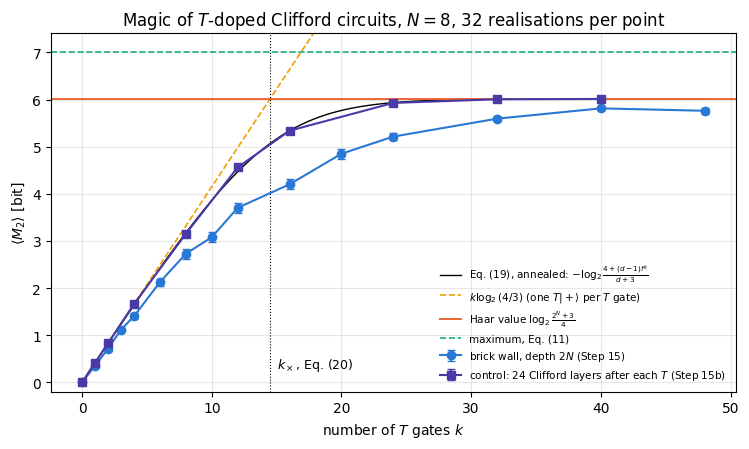

In [28]:
# ==============================================================================
# FIGURE 5: magic against the number of T gates, crowded brick wall vs control vs Eq. (19)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.errorbar(K_LIST, mean_dop, yerr=err_dop, fmt=MARKERS[0] + "-", color=PALETTE[0], capsize=3,
            label=rf"brick wall, depth $2N$ (Step 15)")
ax.errorbar(K_CTRL, ctrl_m2, yerr=ctrl_m2_err, fmt=MARKERS[1] + "-", color=PALETTE[5], capsize=3,
            label=rf"control: ${GAP_dop}$ Clifford layers after each $T$ (Step 15b)")
k_fine = np.linspace(0, max(K_LIST), 200)
ax.plot(k_fine, -np.log2((4 + (d_dop - 1) * f_T ** k_fine) / (d_dop + 3)), "-", color="k", lw=1.0,
        label=r"Eq. (19), annealed: $-\log_2\frac{4+(d-1)f^k}{d+3}$")
ax.plot(k_fine, k_fine * LOG2_4_3, "--", color=PALETTE[3], lw=1.2, label=r"$k\log_2(4/3)$ (one $T\vert+\rangle$ per $T$ gate)")
ax.axhline(haar_dop, color=PALETTE[1], ls="-", lw=1.4, label=r"Haar value $\log_2\frac{2^N+3}{4}$")
ax.axhline(np.log2((2 ** N_dop + 1) / 2), color=PALETTE[2], ls="--", lw=1.2, label=r"maximum, Eq. (11)")
k_cross = (N_dop - 2) / LOG2_4_3
ax.axvline(k_cross, color="k", lw=0.8, ls=":")
ax.text(k_cross + 0.6, 0.3, r"$k_\times$, Eq. (20)", fontsize=9)
ax.set_xlabel(r"number of $T$ gates $k$")
ax.set_ylabel(r"$\langle M_2\rangle$ [bit]")
ax.set_ylim(-0.2, np.log2((2 ** N_dop + 1) / 2) + 0.4)
ax.set_title(rf"Magic of $T$-doped Clifford circuits, $N={N_dop}$, {R_dop} realisations per point")
ax.legend(fontsize=7.5, loc="lower right")
fig.tight_layout()
plt.show()

**The control follows Eq. (19); the brick wall does not.** At every $k$ the control ensemble agrees with Eq. (19) for
$\langle M_{\rm lin}\rangle$ to within $6\times10^{-3}$, i.e. within $O(1/d)$ (the largest differences are at $k=4$
and $k=12$), and its $\langle M_2\rangle$ sits on or
just above the annealed curve, as Jensen's inequality requires. For $k\le4$ all $32$ control realisations return
exactly $k\log_2\frac43$, the magic of $(T\vert+\rangle)^{\otimes k}$. Eq. (19) lies slightly lower there, by $O(1/d)$,
because it includes the rare events in which a $T$ gate meets $\pm Z_q$ in the stabilizer group and does nothing; for
one gate their probability is $(2^N-1)/(4^N-1)=1/(2^N+1)\approx0.004$, too small to appear in $32$ samples. The
control saturates where Eq. (20) puts the crossover: it reaches about $89\%$ of the Haar value at $k=2N=16$ and
$98.5\%$ at $k=3N=24$.

The crowded brick wall lags behind the control at every $k\ge1$. At $k=16$ and $k=24$ its $\langle M_2\rangle$ lies
more than five standard errors *below* the annealed curve, which is a lower bound for the ensemble of Eq. (19) (the
last assert of Step 15b). Even a single $T$ is affected: at $k=1$ the brick wall gives $0.350\pm0.027$ instead of
$0.415$. Since one $T$ on a stabilizer state yields either $\log_2\frac43$ or $0$ (Section 9.5), the $T$ gate did
nothing in a fraction $1-0.350/0.415\approx0.16\pm0.06$ of the brick-wall realisations, against $1/(2^N+1)\approx0.004$
after a global random Clifford. A state produced by a few layers of local gates is far more likely to have some $\pm Z_q$
in its stabilizer group than a uniformly random stabilizer state.

The slow saturation in the brick-wall data is therefore a property of the circuit, a $T$ count crowded into a fixed,
shallow depth, and $M_2$ itself is not slow. For the ensemble of Eq. (19), $M_{\rm lin}$ reaches its Haar value
at $k=\Theta(N)$ (Leone, Oliviero and Hamma 2022), the same scaling that Leone, Oliviero, Zhou and Hamma (2021) found
for the eight-point out-of-time-order correlator and the fluctuations of the subsystem purity; Eq. (20) supplies the
constant, $2.41$ $T$ gates per qubit, for $M_2$.

The mean half-chain entanglement entropy in the last printed column is essentially independent of $k$: it fluctuates
between $2.75$ and $3.09$ bit with no trend, while the magic goes from $0$ to $5.8$ bit. The Clifford part of the
circuit has already produced most of the entanglement it ever will at $k=0$. That observation is the subject of the
next section.

### 10.2 Magic and entanglement are different resources

The claim of Section 1, that entanglement alone does not make a state hard, is tested directly here. We collect four
families of $N=8$ states and plot each one as a point in the (entanglement entropy, magic) plane:

* **random stabilizer states**: the $k=0$ circuits above;
* **random product states**: an independent Haar-random single-qubit state on every qubit, hence zero entanglement;
* **$T$-doped circuits** at $k=4$ and $k=16$;
* **Haar-random states**.

In [29]:
# ==============================================================================
# STEP 16: (entanglement, magic) for four families of states
# ==============================================================================
N_sc, R_sc = 8, 24
cut = list(range(N_sc // 2))


def random_product_state(key):
    """Product of N independent Haar-random single-qubit states (zero entanglement, generic magic).

    IMPLEMENTATION  a Haar-random 2-component vector u defines the unitary [[u0, -u1*], [u1, u0*]]
                    whose first column is u; applying it to |0> on qubit q installs u there.
    """
    out = zero_state(N_sc)
    ks = jax.random.split(key, N_sc)
    for q in range(N_sc):
        u = haar_state(ks[q], 1)
        out = apply_gate(out, jnp.array([[u[0], -jnp.conj(u[1])], [u[1], jnp.conj(u[0])]], dtype=CDTYPE), [q])
    return out


families = {}
for k, lab in [(0, "random stabilizer ($k=0$)"), (4, r"$T$-doped, $k=4$"), (16, r"$T$-doped, $k=16$")]:
    keys = jax.random.split(jax.random.PRNGKey(900 + k), R_sc)
    masks = t_masks(jax.random.PRNGKey(17 + k), R_sc, DEPTH_dop, N_sc, k)
    families[lab] = jax.vmap(lambda a, m: doped_clifford_state(a, m, N_sc, DEPTH_dop))(keys, masks)
families["random product"] = jnp.stack([random_product_state(k)
                                        for k in jax.random.split(jax.random.PRNGKey(555), R_sc)])
families["Haar random"] = jnp.stack([haar_state(k, N_sc)
                                     for k in jax.random.split(jax.random.PRNGKey(556), R_sc)])

scatter = {}
print(f"{'family':28s} {'S_half range [bit]':>22s} {'M_2 range [bit]':>22s}")
for lab, psis in families.items():
    m = sre_batch_of_states(psis, 2.0, batch=64)
    s = np.array([float(entanglement_entropy(p, cut)) for p in psis])
    scatter[lab] = (s, m)
    print(f"{lab:28s} {f'[{s.min():.3f}, {s.max():.3f}]':>22s} {f'[{m.min():.3f}, {m.max():.3f}]':>22s}")
print(f"\nmaximal half-chain entropy at N={N_sc}: {N_sc // 2} bit;  Haar magic reference: {haar_dop:.3f} bit")

# also the named states
def bell_pairs_across_cut(N):
    """Stabilizer state with the MAXIMAL half-chain entropy: N/2 Bell pairs, each straddling the cut.

    MATH   |psi> = (x)_{q<N/2} (|0_q 0_{q+N/2}> + |1_q 1_{q+N/2}>)/sqrt(2);  S(N/2) = N/2 bits exactly,
           and every stabiliser generator is a Pauli string, so M_alpha = 0.
    """
    psi = zero_state(N)
    for q in range(N // 2):
        psi = apply_gate(apply_gate(psi, H, [q]), CNOT, [q, q + N // 2])
    return psi


named = {"GHZ": ghz_state(N_sc), "cluster": cluster_state(N_sc), "W": w_state(N_sc),
         r"$(T\vert+\rangle)^N$": t_plus_state(N_sc),
         r"$4$ Bell pairs": bell_pairs_across_cut(N_sc)}
NAMED_OFFSET = {"GHZ": (6, 4), "cluster": (6, -12), "W": (6, 4),
                r"$(T\vert+\rangle)^N$": (8, -4), r"$4$ Bell pairs": (-78, 4)}
for lab, psi in named.items():
    print(f"  {lab:22s} S_half = {float(entanglement_entropy(psi, cut)):.4f} bit, "
          f"M_2 = {sre(psi):.4f} bit")

family                           S_half range [bit]        M_2 range [bit]


random stabilizer ($k=0$)            [1.000, 3.000]         [0.000, 0.000]
$T$-doped, $k=4$                     [1.601, 3.811]         [0.830, 1.660]
$T$-doped, $k=16$                    [2.550, 3.492]         [2.955, 5.180]


random product                       [0.000, 0.000]         [1.762, 3.349]
Haar random                          [3.199, 3.371]         [5.970, 6.038]

maximal half-chain entropy at N=8: 4 bit;  Haar magic reference: 6.017 bit


  GHZ                    S_half = 1.0000 bit, M_2 = 0.0000 bit
  cluster                S_half = 1.0000 bit, M_2 = 0.0000 bit
  W                      S_half = 1.0000 bit, M_2 = 3.3561 bit
  $(T\vert+\rangle)^N$   S_half = 0.0000 bit, M_2 = 3.3203 bit
  $4$ Bell pairs         S_half = 4.0000 bit, M_2 = 0.0000 bit


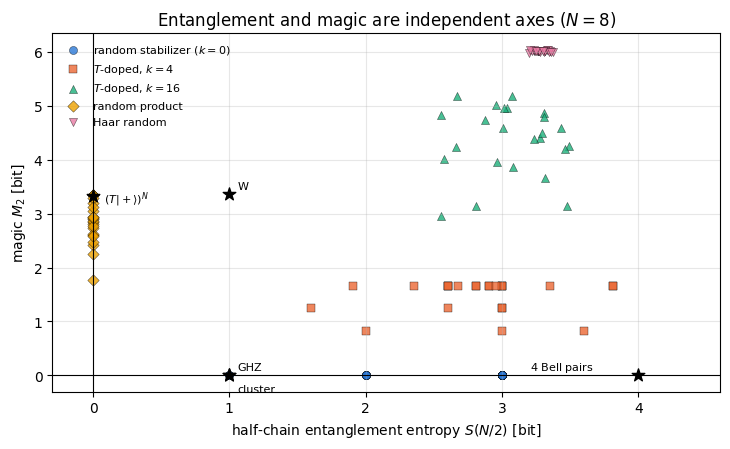

In [30]:
# ==============================================================================
# FIGURE 6: the (entanglement, magic) plane
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for i, (lab, (s, m)) in enumerate(scatter.items()):
    ax.scatter(s, m, s=34, marker=MARKERS[i % len(MARKERS)], color=PALETTE[i % len(PALETTE)],
               alpha=0.8, edgecolors="k", linewidths=0.3, label=lab)
for lab, psi in named.items():
    ax.scatter([float(entanglement_entropy(psi, cut))], [sre(psi)], s=90, marker="*",
               color="k", zorder=5)
    ax.annotate(lab, (float(entanglement_entropy(psi, cut)), sre(psi)),
                textcoords="offset points", xytext=NAMED_OFFSET[lab], fontsize=8)
ax.axhline(0.0, color="k", lw=0.8)
ax.axvline(0.0, color="k", lw=0.8)
ax.set_xlabel(r"half-chain entanglement entropy $S(N/2)$ [bit]")
ax.set_ylabel(r"magic $M_2$ [bit]")
ax.set_xlim(-0.3, N_sc // 2 + 0.6)
ax.set_title(rf"Entanglement and magic are independent axes ($N={N_sc}$)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The figure fills three of the four corners of the $(S,M_2)$ rectangle. Random stabilizer states lie on the **zero-magic axis** and nowhere else,
at entanglement entropies spread over $1$ to $3$ bits in this ensemble; their entropies are always *integers*, which is
a property of stabilizer states (a cut through a stabilizer state has Schmidt coefficients that are all equal, so
$S$ counts stabilizer generators). The star labelled "$4$ Bell pairs" is the explicit stabilizer state that reaches the
**maximal** $4$ bits of half-chain entropy at $N=8$ — still with exactly zero magic, which is the whole point of the
figure. Random product states lie on the **zero-entanglement axis** with $1.8$ to $3.3$ bits of magic. Haar states sit
alone in the **upper right**, tightly clustered at $S\approx3.3$ and $M_2\approx6.0$. GHZ, cluster and
$(T\vert+\rangle)^{\otimes8}$ fall on the two axes, and the $W$ state carries both at once: $1$ bit of half-chain
entropy and $3.36$ bit of magic. The fourth corner, the origin, is not populated in the figure; it holds the product stabilizer states such as $\vert0\rangle^{\otimes8}$.

The two quantities can be varied independently. A Clifford circuit moves a state horizontally at fixed magic; a layer of single-qubit rotations on a product state moves it vertically at fixed
abscissa zero. Any theory of "what makes a quantum state hard" needs both axes.

> **Physics insight.** A stabilizer state with maximal entanglement is still a classical object in the sense of
> Gottesman-Knill: its $2^N$ amplitudes are determined by $N$ Pauli generators, i.e. by $N(2N+1)$ bits. Its large
> entanglement entropy reflects strong *bipartite correlations* and coexists with this short description. Magic
> measures the distance from the set of states that admit such a description (the stabilizer nullity of Section 6.6,
> which bounds $M_\alpha$ from above, literally counts the missing generators); entropy measures the correlations.

### 10.3 Magic of a many-body ground state: the transverse-field Ising chain

The transverse-field Ising model (TFIM) is the standard laboratory for a quantum phase transition:

$$ H(h) \;=\; -\sum_{\langle ij\rangle} Z_iZ_j \;-\; h\sum_i X_i , \tag{21} $$

with a ferromagnetic phase for $h<1$, a paramagnetic phase for $h>1$ and a critical point at $h=1$ in the thermodynamic
limit. Both limits are stabilizer states: at $h=0$ the ground states are $\vert0\cdots0\rangle$ and
$\vert1\cdots1\rangle$ (and the symmetric cat state built from them, which is GHZ), at $h\to\infty$ it is
$\vert+\rangle^{\otimes N}$. Magic must therefore vanish at both ends and be non-zero in between, and the location of its
maximum is the quantity of interest.

**A numerical subtlety that has to be dealt with first.** For $h<1$ the two symmetry-broken ground states are
exponentially close in energy, so a plain Lanczos run returns an arbitrary superposition $\alpha\vert0\cdots0\rangle+\beta\vert1\cdots1\rangle$
— which for generic $\alpha,\beta$ is *not* a stabilizer state and reports spurious magic. Since $H$ commutes with the
parity $\Pi=\prod_qX_q$, the fix is to work in the even-parity sector: start Lanczos from a vector projected onto
$\Pi=+1$, and the whole Krylov space stays there. At $h=0$ this selects the GHZ cat, whose magic is exactly zero, as it
must be.

We use the Lanczos routine of [notebook 11](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)
with an $h$-parametrised matrix-free $H\vert\psi\rangle$ so that the whole field sweep compiles once.

In [31]:
# ==============================================================================
# STEP 17: TFIM ground states in the even-parity sector, matrix-free
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "periodic"))
def tfim_apply(psi, h, N, periodic):
    """H|psi> for H = -sum_<ij> Z_i Z_j - h sum_i X_i   (Eq. 21), matrix-free.

    JAX  `h` is TRACED, N and `periodic` are static -> one compilation serves the whole field sweep.
    COST O(N 2^N) per call.
    """
    bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    out = jnp.zeros_like(psi)
    for b in bonds:
        out = out - apply_gate(psi, jnp.kron(Z, Z), b)
    for q in range(N):
        out = out - h * apply_gate(psi, X, [q])
    return out


def tfim_ground_state(N, h, periodic=True, m=32, restarts=2, seed=0):
    """Ground state of Eq. (21) inside the EVEN-PARITY sector (Pi = prod_q X_q = +1).

    WHY  for h < 1 the two symmetry-broken ground states are quasi-degenerate; an unconstrained Lanczos
         returns an arbitrary superposition of them, which is not a stabilizer state even at h = 0.
         H commutes with Pi, so a start vector with Pi = +1 keeps the whole Krylov space in that sector.
    """
    v = haar_state(jax.random.PRNGKey(seed), N)
    v = v + apply_pauli_string(v, "X" * N)                 # project onto Pi = +1
    v = v / jnp.linalg.norm(v)
    hh = jnp.asarray(h, dtype=RDTYPE)
    matvec = lambda p: tfim_apply(p, hh, N, periodic)
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(matvec, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# CHECKPOINT: Lanczos in the parity sector against dense diagonalisation of the full Hamiltonian
N_chk2 = 8
terms_chk = heisenberg_terms(N_chk2, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-1.0, periodic=True)
H_dense = np.asarray(dense_hamiltonian(terms_chk, N_chk2))
w_dense, U_dense = np.linalg.eigh(H_dense)
E_lan, psi_lan = tfim_ground_state(N_chk2, 1.0, periodic=True)
psi_dense = jnp.asarray(U_dense[:, 0], dtype=CDTYPE).reshape((2,) * N_chk2)
print(f"N = {N_chk2}, h = 1, ring:")
print(f"  E_0  Lanczos {E_lan:.12f}   dense {w_dense[0]:.12f}   diff {abs(E_lan - w_dense[0]):.2e}")
print(f"  M_2  Lanczos {sre(psi_lan):.12f}   dense {sre(psi_dense):.12f}   "
      f"diff {abs(sre(psi_lan) - sre(psi_dense)):.2e}")
print(f"  parity <prod X> = {float(jnp.real(jnp.vdot(psi_lan, apply_pauli_string(psi_lan, 'X' * N_chk2)))):+.10f}")
assert abs(E_lan - w_dense[0]) < 1e4 * TOL and abs(sre(psi_lan) - sre(psi_dense)) < 1e4 * TOL

N = 8, h = 1, ring:
  E_0  Lanczos -10.251661790966   dense -10.251661790966   diff 3.55e-15
  M_2  Lanczos 3.049067548505   dense 3.049067548505   diff 4.44e-16
  parity <prod X> = +1.0000000000


In [32]:
# ==============================================================================
# STEP 18: magic density of the TFIM ground state across the transition
# ==============================================================================
H_GRID = np.round(np.linspace(0.0, 2.0, 21), 3)
N_TFIM = [6, 8, 10]
t0 = time.time()
mag = {}
for periodic in (True, False):
    for N in N_TFIM:
        mag[(periodic, N)] = np.array([sre(tfim_ground_state(N, float(h), periodic)[1]) for h in H_GRID])
print(f"all {2 * len(N_TFIM) * len(H_GRID)} ground states in {time.time() - t0:.1f} s\n")

for periodic in (True, False):
    tag = "ring (periodic)" if periodic else "open chain"
    print(f"{tag}:")
    print("   h    " + "".join(f"  N={N:<6d}" for N in N_TFIM))
    for i, h in enumerate(H_GRID):
        print(f" {h:4.2f}  " + "".join(f"  {mag[(periodic, N)][i] / N:8.4f}" for N in N_TFIM))
    for N in N_TFIM:
        j = int(np.argmax(mag[(periodic, N)] / N))
        print(f"   -> N={N}: max M_2/N = {mag[(periodic, N)][j] / N:.4f} at h = {H_GRID[j]:.2f}")
    # magic DENSITY from the finite-size fit M_2 = alpha N + beta
    A = np.vstack([np.array(N_TFIM, dtype=float), np.ones(len(N_TFIM))]).T
    alpha_h = np.array([np.linalg.lstsq(A, np.array([mag[(periodic, N)][i] for N in N_TFIM]), rcond=None)[0][0]
                        for i in range(len(H_GRID))])
    mag[(periodic, "alpha")] = alpha_h
    jj = int(np.argmax(alpha_h))
    print(f"   -> slope of M_2 vs N: max alpha = {alpha_h[jj]:.4f} at h = {H_GRID[jj]:.2f}\n")

all 126 ground states in 10.9 s

ring (periodic):
   h      N=6       N=8       N=10    
 0.00     -0.0000   -0.0000   -0.0000
 0.10      0.0036    0.0036    0.0036
 0.20      0.0145    0.0145    0.0145
 0.30      0.0328    0.0327    0.0327
 0.40      0.0594    0.0585    0.0584
 0.50      0.0955    0.0928    0.0922
 0.60      0.1435    0.1372    0.1352
 0.70      0.2047    0.1948    0.1900
 0.80      0.2750    0.2678    0.2612
 0.90      0.3366    0.3448    0.3459
 1.00      0.3610    0.3811    0.3933
 1.10      0.3408    0.3506    0.3531
 1.20      0.2979    0.2945    0.2889
 1.30      0.2531    0.2439    0.2373
 1.40      0.2144    0.2043    0.1990
 1.50      0.1829    0.1739    0.1701
 1.60      0.1575    0.1502    0.1476
 1.70      0.1372    0.1314    0.1296
 1.80      0.1206    0.1160    0.1148
 1.90      0.1069    0.1034    0.1025
 2.00      0.0955    0.0928    0.0922
   -> N=6: max M_2/N = 0.3610 at h = 1.00
   -> N=8: max M_2/N = 0.3811 at h = 1.00
   -> N=10: max M_2/N = 0.393

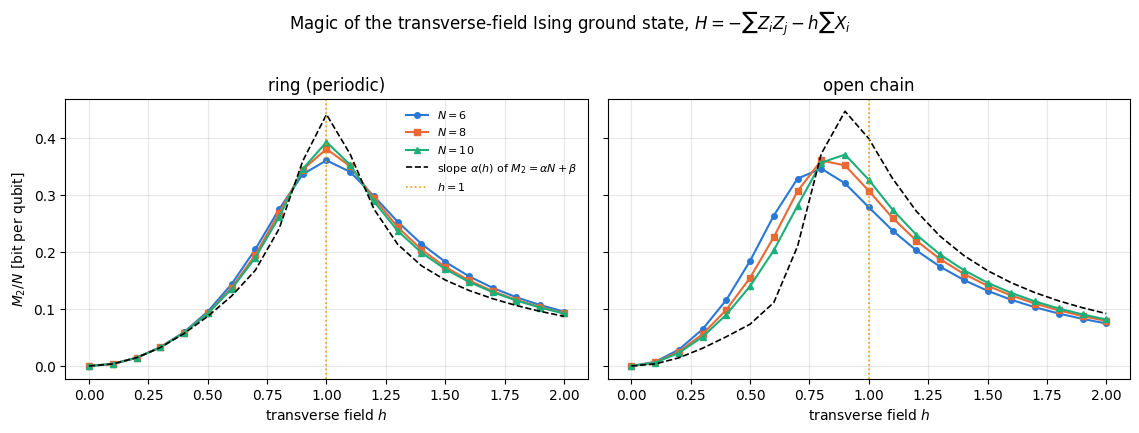

In [33]:
# ==============================================================================
# FIGURE 7: magic across the Ising transition, ring vs open chain
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, periodic, tag in zip(axes, (True, False), ("ring (periodic)", "open chain")):
    for i, N in enumerate(N_TFIM):
        ax.plot(H_GRID, mag[(periodic, N)] / N, MARKERS[i] + "-", color=PALETTE[i], ms=4, label=rf"$N={N}$")
    ax.plot(H_GRID, mag[(periodic, "alpha")], "k--", lw=1.2,
            label=r"slope $\alpha(h)$ of $M_2=\alpha N+\beta$")
    ax.axvline(1.0, color=PALETTE[3], lw=1.2, ls=":", label=r"$h=1$")
    ax.set_xlabel(r"transverse field $h$")
    ax.set_title(tag)
axes[0].set_ylabel(r"$M_2/N$ [bit per qubit]")
axes[0].legend(fontsize=8)
fig.suptitle(r"Magic of the transverse-field Ising ground state, $H=-\sum Z_iZ_j-h\sum X_i$", y=1.02)
fig.tight_layout()
plt.show()

**What is measured.** On the **ring** the magic density $M_2/N$ peaks at $h=1.00$ — the critical point — for every one
of $N=6,8,10$, with the peak value rising slowly with $N$ ($0.361\to0.381\to0.393$ bit per qubit). The finite-size
slope $\alpha(h)$ of $M_2=\alpha N+\beta$, which is the magic *density* in the thermodynamic limit as far as three sizes
can determine it, also peaks at $h=1.00$ with $\alpha(1)=0.4417$.

**Comparison with the literature, with the conventions written out.** Oliviero, Leone and Hamma (2022) study the same
quantity and report $\alpha(1)\approx0.44$. The conventions match where it matters: they use $M_2$, logarithms base
$2$, and the same linear fit $M_2=\alpha(\lambda)N+\beta(\lambda)$ whose slope is what $0.44$ refers to. Their
Hamiltonian is written $H=-\sum_i(X_iX_{i+1}+\lambda Z_i)$ rather than our $-\sum Z_iZ_j-h\sum X_i$, which is a global
Hadamard away — a Clifford, so every value of $M_2$ is identical. Two differences remain and neither is controlled
here: they fit over $N\in[5,12]$ where we use $N=6,8,10$, and their paper does not state its boundary conditions explicitly.
The latter matters, because our own open chain reaches $\alpha=0.4473$ at $h=0.90$ while the ring reaches $0.4417$ at
$h=1.00$ — both round to $0.44$, so the numerical agreement does not by itself confirm that we are comparing the same
geometry.

Two limitations of our own measurement belong with it. The field grid has spacing $\Delta h=0.1$, so "the peak is
at $h=1.00$" means only that it lies within $\pm0.05$ of the critical point; a displacement smaller than that cannot be
seen here. And $\alpha(h)$ is a two-parameter fit to three sizes with no error bar; it is a finite-size slope and
carries no information about corrections beyond linear order in $N$. Exercise 5 pushes the grid and the sizes.

On the **open chain** the peak sits at $h=0.80$ ($N=6,8$) and $h=0.90$ ($N=10$) on our grid, drifting towards $h=1$ as
$N$ grows but clearly displaced at these sizes. The two boundary spins have only one neighbour and behave as if the
ordering field were weaker, which shifts the effective transition to smaller $h$; a $10$-spin open chain has $20\%$ of
its spins on the boundary. The lesson is methodological: **the location of a peak in a finite-size many-body quantity
depends on the boundary conditions**, and the ring, which has no boundary, is the geometry from which a bulk property
can be read off at $N\le10$.

**A caveat the literature insists on.** Haug and Piroli (Phys. Rev. B 2023), using matrix-product states at much larger
$N$, find that the stabilizer Renyi entropy is in general *not* maximal at the critical point and that where it peaks
depends on the choice of local computational basis. Our measurement is consistent with theirs in the sense that we,
too, find a peak whose position moves with a seemingly innocent change of setup (boundary conditions here, basis there). What $M_2$
certainly does at criticality is reach an $O(N)$ value with the largest density in the accessible window; it does
*not* diverge, and at $N\le10$ its behaviour in $h$ is smooth, as the figure shows. Haug and Piroli locate the
signature of the transition elsewhere: writing $M_2=D_NN+c_N$, the subleading term $c_N$ appears to develop a
discontinuity at $h=1$ in every local basis they examine, a feature that sizes this small cannot resolve.

A separate sanity check worth stating: the magic is a *global* quantity, invariant under all Clifford unitaries, but not
under general basis changes. Rewriting Eq. (21) with $X$ and $Z$ exchanged is a global Hadamard, which is Clifford, so
it leaves every number in the figure unchanged.

### 10.4 Magic generated by a quench

The last experiment is dynamical. Prepare $\vert0\cdots0\rangle$ — a stabilizer state with zero magic and zero
entanglement — and evolve it with the critical Ising Hamiltonian $H(1)$ using the second-order TEBD of
[notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb). Both quantities start at zero;
the question is whether they grow on the same time scale.

In [34]:
# ==============================================================================
# STEP 19: TEBD quench of |0...0> under the critical TFIM
# ==============================================================================
# ------------------------------- PARAMETERS ----------------------------------
N_q, h_q, DT, STEPS_PER_SNAP, N_SNAP = 10, 1.0, 0.025, 8, 25
# -----------------------------------------------------------------------------
terms_q = heisenberg_terms(N_q, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-h_q, periodic=False)
gates_q = tebd_gates(terms_q, DT, order=2)
tebd_step = jax.jit(lambda p: apply_gates(p, gates_q))

psi_q = zero_state(N_q)
times_q, mag_q, ent_q, ener_q = [], [], [], []
t0 = time.time()
for snap in range(N_SNAP + 1):
    if snap:
        for _ in range(STEPS_PER_SNAP):
            psi_q = tebd_step(psi_q)
    times_q.append(snap * STEPS_PER_SNAP * DT)
    mag_q.append(sre(psi_q))
    ent_q.append(float(entanglement_entropy(psi_q, list(range(N_q // 2)))))
    ener_q.append(float(energy(terms_q, psi_q)))
print(f"{N_SNAP * STEPS_PER_SNAP} TEBD steps + {N_SNAP + 1} magic evaluations in {time.time() - t0:.1f} s")
print(f"\n{'t':>6s} {'M_2 [bit]':>11s} {'M_2/N':>8s} {'S(N/2) [bit]':>13s} {'E':>11s}")
for i in range(0, N_SNAP + 1, 2):
    print(f"{times_q[i]:6.2f} {mag_q[i]:11.4f} {mag_q[i] / N_q:8.4f} {ent_q[i]:13.4f} {ener_q[i]:11.6f}")
print(f"\nenergy drift over the whole run: {max(ener_q) - min(ener_q):.2e} "
      f"(second-order Trotter, dt = {DT}); Haar magic reference = {np.log2((2 ** N_q + 3) / 4):.4f} bit")

200 TEBD steps + 26 magic evaluations in 2.3 s

     t   M_2 [bit]    M_2/N  S(N/2) [bit]           E
  0.00     -0.0000  -0.0000        0.0000   -9.000000
  0.40      4.9161   0.4916        0.0411   -8.995846
  0.80      6.0450   0.6045        0.4046   -8.996744
  1.20      6.2221   0.6222        0.7657   -8.997279
  1.60      6.3117   0.6312        1.1355   -8.996848
  2.00      6.2374   0.6237        1.4993   -8.997163
  2.40      6.4420   0.6442        1.8823   -8.996927
  2.80      5.6273   0.5627        2.3064   -8.997108
  3.20      6.2278   0.6228        2.7151   -8.996965
  3.60      6.3962   0.6396        2.7675   -8.997078
  4.00      6.5373   0.6537        2.4770   -8.996969
  4.40      6.5669   0.6567        2.2259   -8.996965
  4.80      6.4621   0.6462        1.9594   -8.996775

energy drift over the whole run: 4.72e-03 (second-order Trotter, dt = 0.025); Haar magic reference = 8.0042 bit


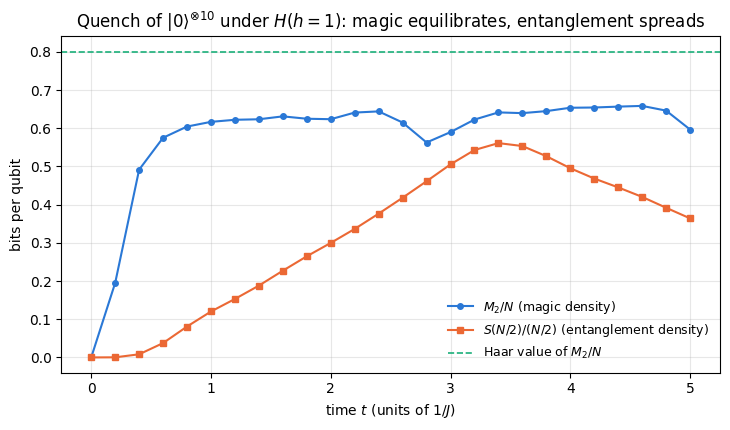

In [35]:
# ==============================================================================
# FIGURE 8: magic and entanglement after a quench
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(times_q, np.array(mag_q) / N_q, MARKERS[0] + "-", color=PALETTE[0], ms=4,
        label=r"$M_2/N$ (magic density)")
ax.plot(times_q, np.array(ent_q) / (N_q // 2), MARKERS[1] + "-", color=PALETTE[1], ms=4,
        label=r"$S(N/2)/(N/2)$ (entanglement density)")
ax.axhline(np.log2((2 ** N_q + 3) / 4) / N_q, color=PALETTE[2], ls="--", lw=1.2,
           label=r"Haar value of $M_2/N$")
ax.set_xlabel(r"time $t$ (units of $1/J$)")
ax.set_ylabel("bits per qubit")
ax.set_title(rf"Quench of $\vert0\rangle^{{\otimes {N_q}}}$ under $H(h=1)$: magic equilibrates, entanglement spreads")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The two curves have completely different shapes. The magic density rises from zero to about $0.6$ bit per qubit within
$t\approx1$ — a time set by the local couplings and independent of the system size — and then fluctuates between
$0.56$ and $0.66$ bit per qubit for the rest of the run. Most of the early rise is single-site physics: the field term
alone would rotate every spin to $\cos t\vert0\rangle+i\sin t\vert1\rangle$, with Bloch vector
$(0,\sin2t,\cos2t)$ up to the sign of the $y$ component, and Eq. (12) then gives
$1-\log_2(1+\sin^42t+\cos^42t)=0.415$ bit per qubit at $t=0.4$, against the measured $0.49$.

The entanglement entropy is still rising at $t=1$ and grows almost linearly up to $t\approx3$. This is the ballistic
spreading of correlations carried by quasiparticles, whose maximal velocity, $2$ in units of the coupling at $h=1$,
respects the Lieb-Robinson bound. Then the entropy *turns over*: its maximum ($2.81$ bit, between the printed
snapshots) falls at $t\approx3.4$, it is still $2.77$ bit at $t=3.6$, and by $t=4.8$ it has dropped to $1.96$. The
turn-over is a finite-size effect: the quasiparticle pairs that carry the entanglement reflect off the ends of the open
chain and return across the cut, so the entropy of the half chain oscillates where an infinite chain would keep
growing. The time of the maximum therefore grows with $N$ while the magic plateau is reached at a fixed time;
Exercise 8 measures exactly that. Magic saturates on the time scale set by the local couplings, whereas entanglement
has to wait for quasiparticles to travel the length of the chain.

The plateau of $M_2/N$ sits well below the Haar line at $0.80$. A Hamiltonian evolution conserves energy: the state keeps
$\langle H\rangle\approx-9$, whereas Haar-random states have $\langle H\rangle$ concentrated near
$\mathrm{Tr}H/2^N=0$, so the evolved state cannot become Haar-typical, unlike the outputs of the doped random circuits of
Section 10.1.

The printed energy drift is the convergence check for the Trotter splitting: the total variation of
$\langle H\rangle$ over the $200$ steps is $4.7\times10^{-3}$ on a total energy of $-9$, i.e. five parts in $10^4$.
Most of it is the one-time $O(\Delta t^2)$ offset acquired in the first few steps — $\langle H\rangle$ leaves
$-9.000000$ and settles near $-8.997$ by $t=0.8$ — and the rest is a bounded $O(\Delta t^2)$ oscillation of order
$10^{-3}$ around that value, with no systematic trend over the run. A second-order Trotter step is the exact
evolution of a nearby Hamiltonian, so this is the expected signature: a small offset plus a bounded oscillation.

## 11. Mixed states: why the same formula must not be used

Every derivation above assumed $\vert\psi\rangle$ pure, and the assumption entered in the very first step. For a mixed
$\rho$, Section 5.1 gives

$$ \sum_P\langle P\rangle^2 \;=\; 2^N\,\mathrm{Tr}(\rho^2)\;<\;2^N , $$

so $\Xi_P=\langle P\rangle^2/2^N$ is **not normalised** and is not a probability distribution at all. The formula can
still be evaluated, but the result does not measure magic. Take the maximally mixed state $\rho=\mathbb 1/2^N$: all Pauli
expectations vanish except $\langle\mathbb 1\rangle=1$, so $\sum_P\langle P\rangle^{2\alpha}=1$ and Eq. (9) returns

$$ M_\alpha\big(\mathbb 1/2^N\big)=\frac{1}{1-\alpha}\log_2\frac{1}{2^N}=\frac{N}{\alpha-1}, \qquad\text{e.g. } M_2=N , $$

which is *larger than Eq. (11) permits for any pure state* and equals the naive ceiling $2N-N=N$ — for a state that is an equal mixture of the $2^N$ computational
basis states, i.e. a state preparable for free inside the stabilizer formalism by flipping $N$ coins. The formula has
confused ignorance with magic, exactly as the subsystem entropy confuses ignorance with entanglement in
[notebook 25](25_entanglement_negativity.ipynb).

In [36]:
# ==============================================================================
# STEP 20: the pure-state formula applied to a mixed state
# ==============================================================================
def sre_formula_on_dm(rho, alpha=2.0):
    """Eq. (9) evaluated with <P> = Tr(rho P) for a density TENSOR -- NOT a magic measure (see text)."""
    N = rho.ndim // 2
    tot = 0.0
    for a in range(2 ** N):
        for b in range(2 ** N):
            e = float(jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, pauli_letters(a, b, N))))))
            tot += abs(e) ** (2 * alpha)
    return float(np.log2(tot / 2 ** N) / (1 - alpha))


N_m = 3
rho_mixed = jnp.eye(2 ** N_m, dtype=CDTYPE).reshape((2,) * (2 * N_m)) / 2 ** N_m
rho_ghz = to_dm(ghz_state(N_m))
rho_half = 0.5 * rho_ghz + 0.5 * to_dm(product_state("0" * N_m))
print(f"{'state':38s} {'purity':>9s} {'sum <P>^2 / 2^N':>17s} {'Eq. (9)':>10s}")
for lab, r in [("maximally mixed  1/2^N", rho_mixed),
               ("pure GHZ (stabilizer)", rho_ghz),
               ("1/2 GHZ + 1/2 |0..0> (both stabilizer)", rho_half)]:
    pur = float(purity(dm_matrix(r)))
    s2 = sum(float(jnp.real(jnp.trace(dm_matrix(apply_pauli_string(r, pauli_letters(a, b, N_m)))))) ** 2
             for a in range(2 ** N_m) for b in range(2 ** N_m)) / 2 ** N_m
    print(f"{lab:38s} {pur:9.5f} {s2:17.5f} {sre_formula_on_dm(r):10.5f}")
print(f"\nN = {N_m}: the maximally mixed state is reported as having M_2 = {N_m} bit -- more than the pure-state "
      f"bound of Eq. (11),\nlog2((2^N+1)/2) = {np.log2((2 ** N_m + 1) / 2):.5f} bit, although it is an equal mixture "
      f"of {2 ** N_m} stabilizer states.")

state                                     purity   sum <P>^2 / 2^N    Eq. (9)
maximally mixed  1/2^N                   0.12500           0.12500    3.00000


pure GHZ (stabilizer)                    1.00000           1.00000    0.00000
1/2 GHZ + 1/2 |0..0> (both stabilizer)   0.75000           0.75000    0.83007

N = 3: the maximally mixed state is reported as having M_2 = 3 bit -- more than the pure-state bound of Eq. (11),
log2((2^N+1)/2) = 2.16993 bit, although it is an equal mixture of 8 stabilizer states.


The middle column is the diagnosis: $\sum_P\Xi_P$ equals the purity, so it is $1$ only for pure states. The mixture of
two stabilizer states in the last row is reported as carrying magic although it lies inside the convex hull of the
stabilizer states, where any magic measure must vanish by definition.

**What to use instead.** The failure is one of *faithfulness*, and it is the reason Haug and Piroli (Quantum 2023)
restrict their analysis of the stabilizer entropies to pure states: if mixed stabilizer states are defined as the convex hull of
pure stabilizer states, the property "$M_\alpha=0$ if and only if the state is a stabilizer state" is lost. Three
routes out, all quoted:

* **Convex roof.** $M_\alpha^{\rm roof}(\rho)=\min\sum_kp_kM_\alpha(\vert\psi_k\rangle)$ over all pure-state
  decompositions. Leone and Bittel (2024) prove that this is a monotone for $\alpha\ge2$. It is also a minimisation over
  an unbounded set and is not computable beyond tiny systems.
* **Robustness of magic** (Howard and Campbell 2017): the minimal $\ell_1$-weight of a quasi-probability decomposition
  over stabilizer states. Faithful and operationally meaningful (it controls the cost of classical simulation), but it is
  a linear program over the stabilizer polytope, whose size grows as $2^{O(N^2)}$.
* **Mana** (Veitch, Mousavian, Gottesman and Emerson 2014): $\mathcal M(\rho)=\log\sum_u\vert W_\rho(u)\vert$, the
  logarithm of the $\ell_1$-norm of the discrete Wigner function (equivalently $\log(2\,\mathrm{sn}(\rho)+1)$ with
  $\mathrm{sn}$ the sum of the negative entries). Computationally cheap and additive, but defined only in odd prime
  dimensions, so it does not apply to qubits at all.

For qubit systems and pure states — which is the setting of essentially all many-body applications — $M_\alpha$ with
$\alpha\ge2$ is the magic monotone of choice: it can be evaluated at $N\sim10$ exactly and, with tensor-network or
sampling methods (Haug and Piroli, Phys. Rev. B 2023; Tarabunga, Tirrito, Chanda and Dalmonte 2023), at $N\sim100$; on a quantum
computer it can be measured efficiently from Bell measurements on copies of the state (Haug, Lee and Kim 2024).

## 12. Cost summary

| task | time | memory | reached here |
|---|---|---|---|
| one Pauli expectation $\langle P\rangle$, matrix-free | $O(N2^N)$ | $O(2^N)$ | any $N$ |
| $M_\alpha$, brute force over $4^N$ strings | $O(N8^N)$; here $N4^N$ kernel launches | $O(2^N)$ | $N=6$ in a few s |
| $M_\alpha$, Walsh-Hadamard | $O(N4^N)$ | $O(\texttt{batch}\cdot2^N)$ | $N=13$ in seconds |
| one Walsh-Hadamard transform | $O(N2^N)$ | $O(2^N)$ | — |
| TFIM ground state, Lanczos, one field value | $O(m\,N2^N)$ | $O(m2^N)$ | $N=10$, $m=32$ |
| one second-order TEBD step | $O(N2^N)$ | $O(2^N)$ | $N=10$ |

The Walsh-Hadamard algorithm is exact — it reorganises the same $4^N$-term sum without approximation — and it
buys a factor $2^N$ in arithmetic, which is $8192$ at $N=13$. Going substantially beyond $N\approx15$ on a single core needs a
different idea: either sampling the Pauli distribution by Monte Carlo on a tensor-network state (Tarabunga, Tirrito,
Chanda and Dalmonte 2023) or representing the state as a matrix product state and contracting the replicated network
(Haug and Piroli, Phys. Rev. B 2023), both of which reach $N\sim100$ at the price of a statistical or a truncation error.

## 13. Key takeaways

* **Entanglement alone does not make quantum computation hard.** Stabilizer states can be maximally entangled and are
  still simulable in polynomial time (Gottesman-Knill). In Figure 6 the random Clifford-circuit states carry $1$ to $3$
  bits of half-chain entropy and the product of four Bell pairs the maximal $4$ bits, all with exactly zero magic.
* **The characteristic distribution.** For a pure state, $\Xi_P=\langle P\rangle^2/2^N$ is a probability distribution
  over the $4^N$ Pauli strings (a consequence of purity alone), and stabilizer states are exactly those for which it is
  uniform on $2^N$ strings and zero elsewhere.
* **$M_\alpha$ is the Renyi entropy of that distribution, offset by $N$ bits.** It vanishes on stabilizer states, is
  invariant under every Clifford unitary (proved from the normaliser property), is additive on product states, and is
  bounded by $\log_2\frac{2^N+1}{2}$ — a bound saturated at $N=1$ by the $T$-type states $(\pm1,\pm1,\pm1)/\sqrt3$ with
  $\log_2\frac32=0.585$ bit. Monotonicity under stabilizer protocols holds for $\alpha\ge2$ (Leone and Bittel 2024) and
  fails for $\alpha<2$ (Haug and Piroli, Quantum 2023).
* **The standard magic state is not the most magical one.** $T\vert+\rangle$ has $\log_2\frac43=0.415$ bit, below the
  single-qubit maximum $\log_2\frac32=0.585$ bit.
* **A typical state is almost maximally magical.** The Haar average of the linear stabilizer entropy is exactly
  $1-4/(2^N+3)$ — derived here from Gamma moments and confirmed to the sampling error — and $\langle M_2\rangle$ sits
  one bit below the maximum, far above the $0.415N$ of a stack of $N$ magic states.
* **The algorithm.** Writing $P=i^{a\cdot b}X^aZ^b$ turns the $2^N$ expectation values at fixed $a$ into one
  Walsh-Hadamard transform of $f_a[s]=\psi^*[s\oplus a]\psi[s]$, and the transform is the matrix
  $\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ applied to every tensor axis. Cost $O(N4^N)$ instead of $O(N8^N)$; measured
  agreement with brute force to $10^{-14}$ on every state family, and $N=13$ inside a notebook cell.
* **Physics.** When the Clifford gates between consecutive $T$ gates scramble the state, the first $T$ gates each add
  $\log_2\frac43$ (or, rarely, nothing), and the average magic follows the closed form Eq. (19) of Leone, Oliviero and
  Hamma, approaching the Haar value by a factor of about $\frac34$ per $T$ gate, with the crossover at
  $k_\times\approx2.41(N-2)$, Eq. (20). Crowding the same $T$ gates into a shallow brick wall slows the approach
  considerably, which is a property of that circuit. In the Ising ring the magic density peaks at $h=1$ (within the grid spacing
  $\Delta h=0.1$) with $\alpha(1)=0.4417$, while
  in the open chain finite-size boundary effects displace the peak to $h\approx0.8$-$0.9$. After a quench, magic
  equilibrates on an $O(1)$ time scale while entanglement spreads ballistically.
* **Mixed states.** The same formula applied to $\rho$ is not a magic measure: $\sum_P\Xi_P$ equals the purity, and the
  maximally mixed state — a free classical mixture of stabilizer states — is reported as more magical than any pure
  state can be.

## 14. Exercises

1. ★ **Real states are less magical.** For the real family $\vert\psi(t)\rangle=\cos t\,\vert0\rangle+\sin t\,\vert1\rangle$
   compute the Bloch vector, insert it into Eq. (12), and maximise over $t$ analytically. Compare the maximum with
   $\log_2\frac32$ and explain the difference geometrically. (Check: the maximum is at $t=\pi/8$ and equals
   $\log_2\frac43$, below $\log_2\frac32$ — real states have $r_y=0$, so they live on a great circle that misses all eight
   $T$-type directions.)
2. ★ **The W state.** Compute $M_2(\vert W_N\rangle)$ for $N=2,\dots,6$ with `sre`. One of the values is exactly zero;
   identify which and say why. (Check: $\vert W_2\rangle=(\vert01\rangle+\vert10\rangle)/\sqrt2$ is the Bell state
   $\vert\Psi^+\rangle$, a stabilizer state; $M_2$ then grows to $2.58$ bit at $N=6$.) Then compute $M_2$ of all the
   Dicke states $\vert D_N^m\rangle$, $m=0,1,\dots,N$, at $N=6$ and at $N=7$, and report where the maximum sits in each
   case. (Check: the values are symmetric under $m\to N-m$, because $X^{\otimes N}$ is Clifford and maps
   $\vert D_N^m\rangle$ to $\vert D_N^{N-m}\rangle$. At $N=6$ the maximum is at $m=1$ (and $m=5$) with $2.585$ bit, at
   $N=7$ it is at $m=2$ (and $m=5$) with $3.239$ bit against $2.996$ for $m=1$ — so the answer changes with $N$, and
   $m=0$ and $m=N$ are stabilizer states with $M_2=0$.)
3. ★★ **The star graph, magic and entanglement (extend the code).** Build the star graph state: $\vert+\rangle^{\otimes N}$
   followed by CZ between qubit $0$ and every other qubit. Compute $M_2$ (a) of the bare star, (b) after a $T$ on
   *every* qubit, (c) after a $T$ on the centre only. You should find exactly $0$, exactly $N\log_2\frac43$, and exactly
   $\log_2\frac43$ independently of $N$. Prove all three: $T$ and CZ are both diagonal, hence commute, so the $T$ gates
   can be pushed through the (Clifford) CZ layer, and Section 6.3 does the rest. Then compute the half-chain
   entanglement entropy of the three states and note that it is $1$ bit in all cases — magic and entanglement moved
   independently again.
4. ★★ **$M_\infty$ is useless.** Define $M_\infty=\lim_{\alpha\to\infty}M_\alpha=-\log_2\max_P\Xi_P-N$. Prove that
   $M_\infty=0$ for *every* pure state (hint: $\Xi_{\mathbb 1}=2^{-N}$ always, and $\Xi_P\le2^{-N}$ always), and confirm
   it numerically on a Haar-random state and on $(T\vert+\rangle)^{\otimes3}$ (the approach is slow: $M_\alpha$ falls
   off like $1/\alpha$, so evaluate at $\alpha$ of order $10^2$). Then plot $M_\alpha$ against $\alpha$ for three
   single-qubit states, $T\vert+\rangle$, the $T$-type state and a Haar-random state, and explain the ordering of the
   three curves at small $\alpha$ and their common approach to zero. (Check: as $\alpha\to0$,
   $M_\alpha\to\log_2(\text{number of strings with }\Xi_P>0)-N$, which is $\log_2 3-1=0.585$ for $T\vert+\rangle$ and
   $1$ for the other two; at $\alpha=2$ the $T$-type state is the largest, with $0.585$.)
5. ★★ **Boundary conditions and the peak (physics).** Extend Step 18 to $N=12$ for the open chain and locate the maximum
   of $M_2/N$ on a grid of spacing $0.05$ in $h$. Determine whether the peak continues to drift towards $h=1$, estimate
   the drift per added spin, and state whether three or four sizes can determine a limit. (Check, on the grid
   $0.60,0.65,\dots,1.20$: the open-chain maximum sits at $h=0.80$, $0.85$, $0.85$, $0.90$ for $N=6,8,10,12$, with
   $M_2/N=0.347$, $0.364$, $0.375$, $0.383$; the peak moves by $0.1$ in $h$ over the six added spins, i.e. by about one grid spacing per three spins, which
   three or four sizes cannot extrapolate reliably.)
6. ★★ **Quenched versus annealed averages.** Section 7.3 gives an *exact* result for $\langle M_{\rm lin}\rangle$ and
   only a lower bound for $\langle M_2\rangle$. Measure the full distribution of $\zeta=\sum_P\langle P\rangle^4$ over
   $500$ Haar states at $N=2,4,6$, plot its histogram, and check that the gap
   $\log_2\mathbb E[\zeta]-\mathbb E[\log_2\zeta]$ equals $\tfrac12\mathrm{Var}(\zeta)/(\ln 2\,\mathbb E[\zeta]^2)$, the
   second-order term of the expansion of $\mathbb E[-\log\zeta]$ around $\mathbb E[\zeta]$. (Estimate *both* sides from
   the same sample — put the sample mean of $\zeta$ inside the logarithm rather than the exact $4d/(d+3)$. The two
   estimators are then strongly correlated and the gap is resolved even though it is below $10^{-3}$ bit at $N=6$,
   far below the $\pm2\times10^{-3}$ error bar of $\langle M_2\rangle$ itself. Check, from two independent sets of
   $500$ states: $0.0113$ and $0.0116$ against $0.0120$ and $0.0125$ at $N=2$; $0.0057$ and $0.0058$ against $0.0062$
   at $N=4$; $0.00076$ and $0.00089$ against $0.00076$ and $0.00092$ at $N=6$. The second-order term reproduces the gap
   to within about $10\%$, it lies above it at every size, which is the sign of the neglected higher orders, and at
   $N=6$ the sample-to-sample scatter of both sides is about $15\%$.)
7. ★★ **Batching over states and over Pauli patterns (extend the code).** `sre_batch_of_states` vmaps over both axes at
   once. Write a variant that vmaps *only* over states and loops over $a$ in Python, and a variant that vmaps only over
   $a$ and loops over states. Measure all three at $N=8$ with $64$ states, report the peak memory each one needs
   (count the live arrays) and explain the ordering.
8. ★★★ **Magic saturation is size independent (physics).** Repeat the quench of Section 10.4 for $N=8,10,12$ and plot
   $M_2/N$ and $S(N/2)/(N/2)$ against $t$ on the same axes. Extract the time at which each quantity first reaches $90\%$
   of its plateau — for the entanglement there is no plateau on these chain lengths, so use $90\%$ of its *maximum*
   instead — and show that one of the two times is independent of $N$ while the other grows linearly with $N$. Explain
   the difference with the Lieb-Robinson light cone. (Check, with $\Delta t=0.025$ and snapshots every $4$ steps: the
   magic reaches $90\%$ of its plateau, defined as the mean of $M_2/N$ over $1\le t\le5$, at $t=0.50$, $0.60$, $0.60$
   for $N=8,10,12$ (plateaus $0.561$, $0.630$, $0.639$ bit per qubit), the same to within the snapshot spacing $0.1$, while the entanglement needs $t=2.50,\,3.00$
   and $3.50$, and its maximum moves from $t=2.9$ to $3.4$ to $4.0$. Budget: $N=12$ needs about a minute for the magic
   alone.)

## 15. References

* C. Gidney and M. Ekerå, *How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits*,
  Quantum **5**, 433 (2021) — the Toffoli count quoted in Section 1.
* D. Gottesman, *Stabilizer codes and quantum error correction*, Ph.D. thesis, California Institute of Technology (1997);
  arXiv:quant-ph/9705052 — the stabilizer formalism, Section 4.1.
* D. Gottesman, *The Heisenberg representation of quantum computers*, in *Group22: Proceedings of the XXII International
  Colloquium on Group Theoretical Methods in Physics*, edited by S. P. Corney, R. Delbourgo and P. D. Jarvis
  (International Press, Cambridge MA, 1999), pp. 32-43; arXiv:quant-ph/9807006 — the Gottesman-Knill theorem,
  Section 4.3.
* S. Aaronson and D. Gottesman, *Improved simulation of stabilizer circuits*, Phys. Rev. A **70**, 052328 (2004) —
  the tableau algorithm quoted in Section 4.3: $O(N)$ per Clifford gate, $O(N^2)$ per computational-basis measurement.
* R. Koenig and J. A. Smolin, *How to efficiently select an arbitrary Clifford group element*,
  J. Math. Phys. **55**, 122202 (2014) — the order $2^{N^2+2N}\prod_k(4^k-1)$ of the Clifford group modulo phases,
  Section 4.2.
* S. Bravyi and A. Kitaev, *Universal quantum computation with ideal Clifford gates and noisy ancillas*,
  Phys. Rev. A **71**, 022316 (2005) — magic-state distillation; Definition 1 of that paper fixes the $T$-type and
  $H$-type states used in Section 7.1.
* V. Veitch, C. Ferrie, D. Gross and J. Emerson, *Negative quasi-probability as a resource for quantum computation*,
  New J. Phys. **14**, 113011 (2012) — Wigner negativity as a resource.
* V. Veitch, S. A. H. Mousavian, D. Gottesman and J. Emerson, *The resource theory of stabilizer quantum computation*,
  New J. Phys. **16**, 013009 (2014) — the resource theory, the relative entropy of magic and the mana, Sections 6.6 and 11.
* M. Howard and E. T. Campbell, *Application of a resource theory for magic states to fault-tolerant quantum computing*,
  Phys. Rev. Lett. **118**, 090501 (2017) — the robustness of magic, Sections 6.6 and 11.
* M. Beverland, E. Campbell, M. Howard and V. Kliuchnikov, *Lower bounds on the non-Clifford resources for quantum
  computations*, Quantum Sci. Technol. **5**, 035009 (2020) — the stabilizer nullity, Section 6.6.
* L. Leone, S. F. E. Oliviero and A. Hamma, *Stabilizer Renyi entropy*, Phys. Rev. Lett. **128**, 050402 (2022) —
  the definition of $M_\alpha$, its properties, the bound $\log_2\frac{2^N+1}{2}$, the nullity bound
  $M_\alpha\le\nu$ of Section 6.6, the Haar average $\mathbb E[M_{\rm lin}]=1-4/(2^N+3)$ of Section 7.3, and the
  average linear stabilizer entropy of $k$-doped random Clifford circuits, Eq. (19) of Section 10.1 (Eq. (13) of the
  paper).
* L. Leone, S. F. E. Oliviero, Y. Zhou and A. Hamma, *Quantum chaos is quantum*, Quantum **5**, 453 (2021) —
  $k=\Theta(N)$ non-Clifford gates are necessary and sufficient for the eight-point out-of-time-order correlator and
  the fluctuations of the subsystem purity of a doped Clifford circuit to reach their Haar values, quoted in
  Section 10.1. That paper studies no magic monotone; the comparison in Section 10.1 is between different diagnostics.
* S. F. E. Oliviero, L. Leone and A. Hamma, *Magic-state resource theory for the ground state of the transverse-field
  Ising model*, Phys. Rev. A **106**, 042426 (2022) — the magic density $\alpha(\lambda)$ of Section 10.3, defined
  as the slope of $M_2=\alpha N+\beta$ fitted over $N\in[5,12]$ and peaking at $\lambda=1$ with
  $\alpha(1)\approx0.44$; their Hamiltonian is $-\sum_i(X_iX_{i+1}+\lambda Z_i)$, a global Hadamard from ours.
* T. Haug and L. Piroli, *Quantifying nonstabilizerness of matrix product states*, Phys. Rev. B **107**, 035148 (2023) —
  matrix-product-state evaluation of $M_\alpha$, and the finding that it is in general not maximal at a critical point
  and depends on the local computational basis (Section 10.3).
* T. Haug and L. Piroli, *Stabilizer entropies and nonstabilizerness monotones*, Quantum **7**, 1092 (2023) —
  counterexamples to monotonicity for $0\le\alpha<2$ and failure of strong monotonicity for every $\alpha$
  (Section 6.6); the paper restricts itself to pure states because $M_\alpha$ is not faithful on the convex hull of
  the stabilizer states (Section 11).
* L. Leone and L. Bittel, *Stabilizer entropies are monotones for magic-state resource theory*,
  Phys. Rev. A **110**, L040403 (2024) — monotonicity for $\alpha\ge2$ on pure states, strong monotonicity of the linear
  stabilizer entropy, and the convex-roof extension to mixed states (Sections 6.6 and 11).
* T. Haug, S. Lee and M. S. Kim, *Efficient quantum algorithms for stabilizer entropies*,
  Phys. Rev. Lett. **132**, 240602 (2024) — measurement of $M_\alpha$ on a quantum computer by Bell measurements,
  Section 11.
* P. S. Tarabunga, E. Tirrito, T. Chanda and M. Dalmonte, *Many-body magic via Pauli-Markov chains - from criticality to
  gauge theories*, PRX Quantum **4**, 040317 (2023) — Monte Carlo sampling of the Pauli distribution, Section 12.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, 10th anniversary edition
  (Cambridge University Press, 2010), Section 10.5 — the stabilizer formalism as a textbook chapter.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/